# 🛢️ ROGII Wellbore Geology Prediction

## EDA + Leakage-Aware Submission Pipeline v3

> **Goal**: predict the missing tail segment of `TVT_input` for each horizontal well.

This notebook keeps the original v2 modeling logic, but refreshes the presentation so the statistical story is easier to scan.  The modeling contract is unchanged:

```text
EDA evidence → leakage policy → residual features → grouped CV diagnostics → submission candidates → final format guard
```

<div style="display:grid; grid-template-columns:repeat(auto-fit,minmax(210px,1fr)); gap:12px; margin:16px 0 8px 0;">
  <div style="border:1px solid #d8d0c2; border-radius:12px; padding:12px 14px; background:#fffaf2; color:#1f2933; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <div style="font-weight:800; font-size:16px; color:#16251b;">⚓ Anchor first</div>
    <div style="font-size:14px; line-height:1.45; color:#263329;">Start from `last_known_TVT`, then learn only the residual movement.</div>
  </div>
  <div style="border:1px solid #d8d0c2; border-radius:12px; padding:12px 14px; background:#f7fbff; color:#1f2933; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <div style="font-weight:800; font-size:16px; color:#16251b;">🔒 Policy split</div>
    <div style="font-size:14px; line-height:1.45; color:#263329;">Keep strict drilling-time features separate from Kaggle offline features.</div>
  </div>
  <div style="border:1px solid #d8d0c2; border-radius:12px; padding:12px 14px; background:#f7fff8; color:#1f2933; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <div style="font-weight:800; font-size:16px; color:#16251b;">🧪 Grouped CV</div>
    <div style="font-size:14px; line-height:1.45; color:#263329;">Validate by well id and aggregate RMSE at row level.</div>
  </div>
  <div style="border:1px solid #d8d0c2; border-radius:12px; padding:12px 14px; background:#fbf7ff; color:#1f2933; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <div style="font-weight:800; font-size:16px; color:#16251b;">📦 Submission guard</div>
    <div style="font-size:14px; line-height:1.45; color:#263329;">The final cell validates exact `id,tvt` format against `sample_submission`.</div>
  </div>
</div>

**Reading guide**: Sections 0-17 explain the statistical evidence. Sections 18-20 are submission construction and safety checks.


## 📌 Statistical Summary

> **Main idea**: `last_known_TVT` is a strong flat anchor. A useful model should correct drifting wells while leaving flat wells nearly unchanged.

### 🎯 Task Snapshot

| Item | Value | Why it matters |
|---|---:|---|
| Train wells | 773 | validation must separate wells |
| Visible test wells | 3 | public diagnostics can be optimistic because ids overlap train wells |
| Submission rows | 14,151 | exactly the missing `TVT_input` rows |
| Train tail rows | 3,783,989 | row-level RMSE gives long tails more weight |
| Missing blocks per train well | 1 | this is tail forecasting, not arbitrary interpolation |

### 🧬 Feature / Signal Map

| Signal family | Examples | Policy | Modeling role |
|---|---|---:|---|
| ⚓ Anchor & prefix TVT | `last_known_TVT`, prefix slopes, prefix range | strict | strong prior and residual reference |
| 🛤️ Trajectory | `MD`, `X/Y/Z`, local steps, tail position | strict / offline | geometry and smoothness context |
| 🌋 GR texture | trailing rolls, centered rolls, lead/lag GR | strict / offline | local stratigraphic events |
| 🧭 Typewell alignment | GR at TVT baselines, candidate paths, beam artifacts | offline-heavy | connect hidden GR to reference typewell depth |
| 🪨 Formation plane | ANCC / formation-top formula probes | offline | spatial geology prior and public diagnostic branch |
| 🧩 Artifact stack | branch-factory OOF/test residuals | optional | combine expensive physics/spatial branches without rerunning them |

### 🧪 Stored Grouped-CV Evidence

These numbers are local validation evidence for the grouped HGB residual pipeline. They do **not** directly score the all-row LightGBM or external artifact-stack branch.

| Policy | Row-weighted RMSE | Role |
|---|---:|---|
| Constant anchor | 15.9099 | strong null model |
| Strict `calibrated_typewell_alignment` | **14.4315** | best stored drilling-time-compatible policy |
| Offline `offline_candidate_path_alignment` | **13.6172** | best stored HGB batch policy without beam |

<details>
<summary>Row-weighted CV aggregation</summary>

$$
\mathrm{RMSE}_{CV}
=
\sqrt{
rac{\sum_f n_f\,\mathrm{RMSE}_f^2}{\sum_f n_f}}.
$$

</details>

### 📦 Submission Branches

| Branch | Main signal | Default role |
|---|---|---|
| Strict HGB diagnostic | prefix + trailing GR + calibrated typewell alignment | conservative validation baseline |
| Offline HGB diagnostic | candidate TVT paths + gap/GR texture | stored best HGB feature policy |
| Built-in all-row LGBM | compact public-style offline features | memory-safe Kaggle candidate |
| Formation plane blend | mild LGBM + ANCC/formation-plane formula | built-in public score probe |
| Artifact stack blend | branch-factory residual artifacts | preferred when valid artifacts are attached |
| Final contract guard | sample-aligned `id,tvt` validation | always last |

### ⚠️ Practical Interpretation

| Rule | Reason |
|---|---|
| Do not trust public LB alone | visible public wells can overlap train wells |
| Keep strict and offline claims separate | future GR/trajectory covariates are Kaggle-valid but not drilling-time strict |
| Prefer OOF for model comparison | it checks unseen-well behavior more honestly |
| Keep multiple candidate files | public-aggressive and private-safe branches answer different questions |


## 🧭 Statistical Roadmap

Instead of treating the notebook as one long script, read it as four connected blocks.

<div style="display:grid; grid-template-columns:repeat(auto-fit,minmax(260px,1fr)); gap:12px; margin:14px 0;">
  <div style="border-left:5px solid #3b82f6; padding:10px 14px; background:#f8fbff; color:#1f2933; border-radius:10px; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <b>🔒 0-3. Information boundary</b><br>
    What is observable, which rows are targets, and where leakage can enter.
  </div>
  <div style="border-left:5px solid #10b981; padding:10px 14px; background:#f8fffb; color:#1f2933; border-radius:10px; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <b>📊 4-10. EDA evidence</b><br>
    Tail difficulty, typewell alignment, smoothness, and the flat-anchor baseline.
  </div>
  <div style="border-left:5px solid #f59e0b; padding:10px 14px; background:#fffaf0; color:#1f2933; border-radius:10px; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <b>🧱 11-17. Feature and model logic</b><br>
    Strict/offline feature families, residual model design, GroupKFold CV, and candidate-path checks.
  </div>
  <div style="border-left:5px solid #8b5cf6; padding:10px 14px; background:#fbf8ff; color:#1f2933; border-radius:10px; box-shadow:0 1px 2px rgba(31,41,51,0.08);">
    <b>🚀 18-20. Submission path</b><br>
    All-row LightGBM candidates, optional artifact stack blend, and final Kaggle format guard.
  </div>
</div>

<details>
<summary>Section-by-section questions</summary>

| Section | Question | Output |
|---|---|---|
| 0-0.1 | What information is observable? | leakage rules + validation policy |
| 1 | Are files matched by well id? | file inventory checks |
| 2-3 | Which rows are targets? | prediction ids and tail masks |
| 4-7 | How difficult are tails? | tail length, missingness, drift, smoothness |
| 8-9 | Does typewell GR align with horizontal GR? | prefix GR correlation diagnostics |
| 10 | How strong is the flat-anchor prior? | constant and linear baselines |
| 11 | Which feature families are statistically admissible? | strict and offline feature tables |
| 12-13 | Do curve shape or spatial proximity contain signal? | knot targets and KNN drift diagnostics |
| 14 | Which well-level failure modes are visible? | representative well plots |
| 15-17 | Which model form follows from the EDA? | residual prediction, CV diagnostics, candidate-path checks |
| 18-20 | Which prediction file should be submitted? | LightGBM/artifact candidates plus final contract guard |

</details>


## 🔒 0. Information Policies and Leakage Rules

### 🧭 Two-track information model

| Policy | Uses | Does **not** use | Best use |
|---|---|---|---|
| **Strict drilling-time** | prefix + current/trailing row evidence | future tail shape, centered windows, tail length | conservative geosteering-style validation |
| **Offline batch** | full provided test CSV covariates | future `TVT`, target-derived summaries | Kaggle submission candidates |

> **Practical rule:** offline features may look at future **GR / trajectory** rows because they are provided in test files, but they must never look at future **TVT**.

### ✅ Allowed vs 🚫 excluded

| Feature family | Strict | Offline | Reason |
|---|---:|---:|---|
| current `MD/X/Y/Z/GR` | ✅ | ✅ | observed covariates |
| prefix `TVT_input` | ✅ | ✅ | known target prefix |
| trailing GR windows | ✅ | ✅ | no future row access |
| centered GR / lead-lag GR | 🚫 | ✅ | future covariates, target-free |
| tail length / tail fraction | 🚫 | ✅ | known only in batch mode |
| candidate-path typewell features | 🚫 | ✅ | path uses full tail position |
| beam alignment | 🚫 | ✅ | sequence feature from hidden GR |
| direct train-only surfaces | 🚫 | 🚫 | hidden-test columns unavailable |
| fold-safe formation imputer outputs | 🚫 | ✅ | reproducible spatial reference model |
| tail `TVT` labels | 🚫 | 🚫 | direct target leakage |

<details>
<summary>Notation and validation boundary</summary>

| Symbol | Meaning |
|---|---|
| $i$ | row index inside one horizontal well |
| $\mathcal{P}_w$ | known prefix where `TVT_input` is present |
| $\mathcal{T}_w$ | prediction tail where `TVT_input` is missing |
| $y_{w,i}$ | true `TVT` |
| $g_w(t)$ | typewell GR curve indexed by typewell TVT |

Strict policy allows values up to row $i$ plus known-prefix target values. Offline policy can additionally use target-free covariates from the full provided test file.

Validation separates wells:

$$
\mathcal{W}_{train}\cap\mathcal{W}_{valid}=\emptyset.
$$

</details>


## 🧯 0.1 Leakage and Statistical Risk Table

| Risk source | Statistical failure mode | Decision |
|---|---|---|
| Visible test mirrors train wells | Same-well diagnostics can be optimistic | Produce an all-train table and a public-clean table |
| Row-level random split | Same-well autocorrelation leakage | Use `GroupKFold` by `well_id` |
| Train-only surfaces | Hidden-test feature mismatch if used directly | Never use as direct row features; use only as fold-safe auxiliary labels for spatial imputers |
| Prefix target values | Valid only before Prediction Start | Use `TVT_input` only in the known prefix |
| Tail length / tail fraction | Future-tail information in strict mode | Offline features only |
| Full-tail GR aggregates | Future GR in strict mode | Offline features only if target-free |
| Full-well endpoint azimuth | Uses future trajectory endpoint | Exclude from strict features |
| Centered rolling windows | Reads future rows | Offline features only |
| Future-looking GR derivatives | Reads future GR events | Use backward differences |
| `TVT_input_bfill` | Backfills from future rows | Exclude |
| Typewell alignment to true tail TVT | Direct target leakage | Use prefix-derived TVT baselines only |
| GR affine calibration on tail | Uses prediction-region data | Fit only on known-prefix pairs |
| Centered smoothing | Future prediction dependence | Strict mode uses causal clipping |
| Nearby wells | Fold leakage if validation targets enter reference table | Require fold-safe reference tables |
| Linear extrapolation | High-variance slope error | Baseline or constrained feature only |

### Anchor hypothesis

$$
H_0: y_{w,i}=y_{w,\mathrm{PS}-1}, \quad i\in\mathcal{T}_w.
$$

📌 Improvements are useful only when residual movement beats this flat anchor without damaging flat wells.



In [1]:
# Configure imports, data locations, and display settings.

from pathlib import Path
from collections import Counter
import json
import gc
import math
import re
import zipfile
import xml.etree.ElementTree as ET
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import PerformanceWarning

try:
    from scipy.spatial import cKDTree
except Exception:
    cKDTree = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore', category=PerformanceWarning)

# Resolve competition data. Kaggle input mounts are preferred; local runs fall back to ./.
KAGGLE_DATA_DIRS = [
    Path('/kaggle/input/rogii-wellbore-geology-prediction'),
    Path('/kaggle/input/competitions/rogii-wellbore-geology-prediction'),
]
LOCAL_DATA_DIR = Path('.')
CANDIDATE_DATA_DIRS = KAGGLE_DATA_DIRS + [LOCAL_DATA_DIR]
DATA_DIR = next(
    (
        p
        for p in CANDIDATE_DATA_DIRS
        if (p / 'train').exists() and (p / 'sample_submission.csv').exists()
    ),
    LOCAL_DATA_DIR,
)
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR = DATA_DIR / 'test'
SAMPLE_SUBMISSION = DATA_DIR / 'sample_submission.csv'
PPTX_PATH = DATA_DIR / 'AI_wellbore_geology_prediction_task_en.pptx'
KAGGLE_WORKING_DIR = Path('/kaggle/working')
KAGGLE_NOTEBOOK_RUN = KAGGLE_WORKING_DIR.exists()
OUTPUT_DIR = KAGGLE_WORKING_DIR if KAGGLE_NOTEBOOK_RUN else DATA_DIR
LIGHTGBM_DEVICE_TYPE = 'gpu' if KAGGLE_NOTEBOOK_RUN else 'cpu'


def lightgbm_accelerator_params(device_type: str | None = None) -> dict:
    device_type = device_type or LIGHTGBM_DEVICE_TYPE
    if device_type == 'gpu':
        memory_safe = bool(globals().get('KAGGLE_MEMORY_SAFE_MODE', False))
        return {
            'device_type': 'gpu',
            'gpu_use_dp': False,
            'max_bin': 127 if memory_safe else 255,
        }
    return {
        'device_type': 'cpu',
        'force_col_wise': True,
    }


DATA_DIR_LABEL = './' if DATA_DIR == LOCAL_DATA_DIR else DATA_DIR.as_posix()
print('DATA_DIR:', DATA_DIR_LABEL)
print('train exists:', TRAIN_DIR.exists())
print('test exists:', TEST_DIR.exists())
print('sample_submission exists:', SAMPLE_SUBMISSION.exists())
print('OUTPUT_DIR:', OUTPUT_DIR.as_posix() if OUTPUT_DIR != DATA_DIR else DATA_DIR_LABEL)
print('LightGBM device type:', LIGHTGBM_DEVICE_TYPE)

DATA_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction
train exists: True
test exists: True
sample_submission exists: True
OUTPUT_DIR: /kaggle/working
LightGBM device type: gpu


## 1. File Inventory

### Statistical role

Check whether the actual file layout matches the competition documentation. All file-level statistics assume that files can be joined correctly by `well_id`.

### Checks

- Do train horizontal, typewell, and PNG id sets match?
- Do test horizontal and typewell id sets match?
- Are visible test ids a subset of train ids?

### Statistical reason

A file-matching error is more damaging than most row-level modeling mistakes. In this well-level task, a mismatched `horizontal_well` and `typewell` pair would invalidate GR correlation analysis.


In [2]:
# Build file lists, extract well ids, and verify horizontal/typewell/image matching.

def well_id_from_path(path: Path) -> str:
    name = path.name
    if '__' in name:
        return name.split('__')[0]
    return path.stem

train_horizontal_files = sorted(TRAIN_DIR.glob('*__horizontal_well.csv'))
train_typewell_files = sorted(TRAIN_DIR.glob('*__typewell.csv'))
train_png_files = sorted(TRAIN_DIR.glob('*.png'))
test_horizontal_files = sorted(TEST_DIR.glob('*__horizontal_well.csv')) if TEST_DIR.exists() else []
test_typewell_files = sorted(TEST_DIR.glob('*__typewell.csv')) if TEST_DIR.exists() else []

file_inventory = pd.DataFrame({
    'group': ['train_horizontal', 'train_typewell', 'train_png', 'test_horizontal', 'test_typewell'],
    'count': [len(train_horizontal_files), len(train_typewell_files), len(train_png_files), len(test_horizontal_files), len(test_typewell_files)],
})
display(file_inventory)

train_h_ids = {well_id_from_path(p) for p in train_horizontal_files}
train_t_ids = {well_id_from_path(p) for p in train_typewell_files}
train_png_ids = {p.stem for p in train_png_files}
test_h_ids = {well_id_from_path(p) for p in test_horizontal_files}
test_t_ids = {well_id_from_path(p) for p in test_typewell_files}

checks = {
    'train horizontal/typewell/png id sets equal': train_h_ids == train_t_ids == train_png_ids,
    'test horizontal/typewell id sets equal': test_h_ids == test_t_ids,
    'visible test ids subset of train ids': test_h_ids.issubset(train_h_ids),
}
print(json.dumps(checks, indent=2))
print('visible test ids:', sorted(test_h_ids)[:10])

,group,count
0,train_horizontal,773
1,train_typewell,773
2,train_png,773
3,test_horizontal,3
4,test_typewell,3


{
  "train horizontal/typewell/png id sets equal": true,
  "test horizontal/typewell id sets equal": true,
  "visible test ids subset of train ids": true
}
visible test ids: ['000d7d20', '00bbac68', '00e12e8b']


### 1.1 Task Description Signals

### Statistical role

Extract the domain hints from the task PPTX before designing features.

### Main modeling implication

The central signal is matching horizontal-well GR against typewell GR on the TVT axis.

<details>
<summary>Local alignment cost</summary>

$$
\mathrm{cost}(i, t)=\left|GR^{horizontal}_{w,i}-GR^{typewell}_{w}(t)\right|
$$

Here $t$ is a candidate TVT. This cost defines the local term for a dynamic-programming or DTW-style alignment model.

</details>


In [3]:
# Extract task-description text used to identify domain signals and constraints.

def extract_pptx_slide_text(pptx_path: Path) -> pd.DataFrame:
    if not pptx_path.exists():
        return pd.DataFrame(columns=['slide', 'text'])
    rows = []
    with zipfile.ZipFile(pptx_path) as zf:
        slide_names = sorted(
            [name for name in zf.namelist() if re.match(r'ppt/slides/slide\d+\.xml$', name)],
            key=lambda name: int(re.search(r'slide(\d+)\.xml$', name).group(1)),
        )
        for slide_name in slide_names:
            root = ET.fromstring(zf.read(slide_name))
            ns_text = '{http://schemas.openxmlformats.org/drawingml/2006/main}t'
            text_parts = [node.text.strip() for node in root.iter(ns_text) if node.text and node.text.strip()]
            rows.append({'slide': slide_name, 'text': ' | '.join(text_parts)})
    return pd.DataFrame(rows)

pptx_text = extract_pptx_slide_text(PPTX_PATH)
print('slide_count:', len(pptx_text))
display(pptx_text.head(14))

slide_count: 14


,slide,text
0,ppt/slides/slide1.xml,Wellbore Geology Prediction
1,ppt/slides/slide2.xml,Data Available | Zoomed in TVT plot | Each wel...
2,ppt/slides/slide3.xml,Horizontal Well Data | TVT (geology of the wel...
3,ppt/slides/slide4.xml,Vertical ( | Typewell | ) Well Data | Well1000...
4,ppt/slides/slide5.xml,Goal: get TVT values from GR data | TVT value ...
5,ppt/slides/slide6.xml,Goal: get TVT values from GR data | Gamma Ray ...
6,ppt/slides/slide7.xml,Goal: get TVT values from GR data | TVT | incr...
7,ppt/slides/slide8.xml,Understanding TVT from Gamma Ray data | VIDEO:...
8,ppt/slides/slide9.xml,Gamma ray in the horizontal well has better re...
9,ppt/slides/slide10.xml,Map view of all training and validation wells


## 2. Schema and Representative Well Inspection

### Statistical role

Read one representative well to inspect the train/test schema difference and the missing-value structure.

### Main check

Train includes target and surface diagnostics that are absent from hidden test horizontal files. Safe model features must be reproducible from the hidden test schema.

<details>
<summary>Schema sets</summary>

Train-only columns:

$$
\{\mathrm{TVT},\mathrm{ANCC},\mathrm{ASTNU},\mathrm{ASTNL},\mathrm{EGFDU},\mathrm{EGFDL},\mathrm{BUDA}\}
$$

Safe test-time columns:

$$
\{\mathrm{MD},X,Y,Z,\mathrm{GR},\mathrm{TVT}_{\mathrm{input}}\}
$$

</details>

### Why this matters

The safe feature set must be fixed before modeling. Otherwise local CV may learn information that cannot be reproduced on the hidden test set.


In [4]:
# Inspect one representative well for schema, dtypes, and missingness.

representative_well_id = sorted(train_h_ids)[0]
print('representative_well_id:', representative_well_id)

representative_train_h = pd.read_csv(TRAIN_DIR / f'{representative_well_id}__horizontal_well.csv')
representative_typewell = pd.read_csv(TRAIN_DIR / f'{representative_well_id}__typewell.csv')
representative_test_h = pd.read_csv(TEST_DIR / f'{representative_well_id}__horizontal_well.csv') if (TEST_DIR / f'{representative_well_id}__horizontal_well.csv').exists() else None

print('train horizontal shape:', representative_train_h.shape)
print('train horizontal columns:', list(representative_train_h.columns))
print('typewell shape:', representative_typewell.shape)
print('typewell columns:', list(representative_typewell.columns))
if representative_test_h is not None:
    print('visible test horizontal shape:', representative_test_h.shape)
    print('visible test horizontal columns:', list(representative_test_h.columns))

print('\nTrain horizontal missing counts:')
display(representative_train_h.isna().sum().to_frame('missing'))
print('\nTypewell missing counts:')
display(representative_typewell.isna().sum().to_frame('missing'))

print('\nTrain horizontal head:')
display(representative_train_h.head())
print('\nTypewell head:')
display(representative_typewell.head())

representative_well_id: 000d7d20
train horizontal shape: (5278, 13)
train horizontal columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
typewell shape: (1296, 3)
typewell columns: ['TVT', 'GR', 'Geology']
visible test horizontal shape: (5278, 6)
visible test horizontal columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']

Train horizontal missing counts:


,missing
MD,0
X,0
Y,0
Z,0
ANCC,0
ASTNU,0
ASTNL,0
EGFDU,0
EGFDL,0
BUDA,0



Typewell missing counts:


,missing
TVT,0
GR,0
Geology,299



Train horizontal head:


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15



Typewell head:


,TVT,GR,Geology
0,11223.95,126.11,NaN
1,11224.45,128.22,NaN
2,11224.95,128.72,NaN
3,11225.45,128.12,NaN
4,11225.95,125.29,NaN


## 3. Prediction Zone and Submission Mapping

### Statistical role

Verify exactly which rows appear in `sample_submission.csv`.

### Main check

The submission rows should match exactly the tail rows where `TVT_input` is missing.

<details>
<summary>ID and tail-row definition</summary>

Each prediction id is built as the string `{well_id}_{row_index}`:

$$
\mathrm{id}_{w,i}=\mathrm{concat}(\mathrm{wellId}_w,\;\mathrm{underscore},\;i)
$$

The prediction row set is:

$$
\mathcal{T}_w=\{i: \mathrm{TVT}_{\mathrm{input},w,i}\;\mathrm{is}\;\mathrm{NaN}\}
$$

</details>

### Statistical reason

If the submitted rows form one tail block per well, the problem is prefix-conditioned forecasting rather than interpolation.


In [5]:
# Define prediction tails and verify sample_submission ids match missing TVT_input rows.

def prediction_zone_info(df: pd.DataFrame) -> dict:
    mask = df['TVT_input'].isna().to_numpy()
    null_indices = np.flatnonzero(mask)
    groups = 0
    in_group = False
    for value in mask:
        if value and not in_group:
            groups += 1
            in_group = True
        elif not value:
            in_group = False
    return {
        'n_rows': len(df),
        'known_rows': int((~mask).sum()),
        'prediction_rows': int(mask.sum()),
        'first_prediction_index': int(null_indices[0]) if len(null_indices) else None,
        'last_prediction_index': int(null_indices[-1]) if len(null_indices) else None,
        'n_missing_groups': groups,
    }

print('Representative prediction zone:')
display(pd.Series(prediction_zone_info(representative_train_h)).to_frame('value'))

if SAMPLE_SUBMISSION.exists() and test_horizontal_files:
    sample = pd.read_csv(SAMPLE_SUBMISSION)
    expected_ids = []
    for path in test_horizontal_files:
        wid = well_id_from_path(path)
        df = pd.read_csv(path)
        pred_idx = np.flatnonzero(df['TVT_input'].isna().to_numpy())
        expected_ids.extend([f'{wid}_{i}' for i in pred_idx])
    print('sample_submission rows:', len(sample))
    print('visible test prediction ids:', len(expected_ids))
    print('exact id set match:', set(sample['id']) == set(expected_ids))
    display(sample.head())

Representative prediction zone:


,value
n_rows,5278
known_rows,1442
prediction_rows,3836
first_prediction_index,1442
last_prediction_index,5277
n_missing_groups,1


sample_submission rows: 14151
visible test prediction ids: 14151
exact id set match: True


,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0


## 📊 4. Horizontal Well Aggregate Summary

### Statistical role

Summarize each train horizontal well into one row of prefix length, tail length, GR availability, geometry, and baseline difficulty.

### Key reading

Tail length, GR missingness, and constant-baseline difficulty define how much each well can influence row-level RMSE.

<details>
<summary>Well-level quantities</summary>

| Quantity | Definition |
|---|---|
| Known prefix length | $n^{\mathrm{known}}_w$ |
| Prediction tail length | $n^{\mathrm{tail}}_w$ |
| GR missing rate | $\#\mathrm{NaN}(GR) / n_w$ |
| Tail TVT range | $\max_{i\in\mathcal{T}_w} y_{w,i}-\min_{i\in\mathcal{T}_w} y_{w,i}$ |
| Constant baseline RMSE | $\sqrt{\frac{1}{n^{\mathrm{tail}}_w}\sum_{i\in\mathcal{T}_w}(y_{w,i}-y_{w,\mathrm{PS}-1})^2}$ |

</details>

> **Leakage boundary:** `tail_tvt_range`, `tail_end_delta_from_last_known`, `constant_tail_rmse`, `tail_rows`, and full-well endpoint-derived `azimuth_deg` are EDA descriptors, not strict drilling-time features.

📌 Tail length affects row-level RMSE weight: long wells can dominate the score.


In [6]:
# Build well-level summaries for prefix length, tail length, GR missingness, geometry, and baseline difficulty.

def summarize_horizontal_file(path: Path) -> dict:
    wid = well_id_from_path(path)
    df = pd.read_csv(path)
    mask = df['TVT_input'].isna().to_numpy()
    pred_idx = np.flatnonzero(mask)
    first_pred = int(pred_idx[0]) if len(pred_idx) else len(df)
    last_known_idx = max(first_pred - 1, 0)
    y = df['TVT'].to_numpy() if 'TVT' in df.columns else np.full(len(df), np.nan)
    tail_y = y[mask] if 'TVT' in df.columns else np.array([])
    tvt_d = pd.Series(y).diff().to_numpy() if 'TVT' in df.columns else np.array([])
    dx = float(df['X'].iloc[-1] - df['X'].iloc[0])
    dy = float(df['Y'].iloc[-1] - df['Y'].iloc[0])
    dz = float(df['Z'].iloc[-1] - df['Z'].iloc[0])
    azimuth = (np.degrees(np.arctan2(dx, dy)) + 360.0) % 360.0
    prefix = df.loc[~mask]
    tail = df.loc[mask]
    return {
        'well_id': wid,
        'n_rows': len(df),
        'md_start': float(df['MD'].iloc[0]),
        'md_end': float(df['MD'].iloc[-1]),
        'md_span': float(df['MD'].iloc[-1] - df['MD'].iloc[0]),
        'known_rows': int((~mask).sum()),
        'tail_rows': int(mask.sum()),
        'ps_index': first_pred,
        'missing_tvt_input_groups': prediction_zone_info(df)['n_missing_groups'],
        'last_known_tvt': float(df['TVT_input'].iloc[last_known_idx]) if len(prefix) else np.nan,
        'ps_x': float(df['X'].iloc[first_pred]) if len(pred_idx) else np.nan,
        'ps_y': float(df['Y'].iloc[first_pred]) if len(pred_idx) else np.nan,
        'ps_z': float(df['Z'].iloc[first_pred]) if len(pred_idx) else np.nan,
        'x_start': float(df['X'].iloc[0]),
        'y_start': float(df['Y'].iloc[0]),
        'z_start': float(df['Z'].iloc[0]),
        'x_end': float(df['X'].iloc[-1]),
        'y_end': float(df['Y'].iloc[-1]),
        'z_end': float(df['Z'].iloc[-1]),
        'xy_span': float(np.hypot(dx, dy)),
        'z_delta': dz,
        'azimuth_deg': float(azimuth),
        'gr_missing_rows': int(df['GR'].isna().sum()),
        'gr_missing_rate': float(df['GR'].isna().mean()),
        'gr_missing_prefix_rate': float(prefix['GR'].isna().mean()) if len(prefix) else np.nan,
        'gr_missing_tail_rate': float(tail['GR'].isna().mean()) if len(tail) else np.nan,
        'tvt_start': float(y[0]) if len(y) else np.nan,
        'tvt_end': float(y[-1]) if len(y) else np.nan,
        'tvt_end_minus_start': float(y[-1] - y[0]) if len(y) else np.nan,
        'tail_tvt_range': float(np.nanmax(tail_y) - np.nanmin(tail_y)) if len(tail_y) else np.nan,
        'tail_end_delta_from_last_known': float(tail_y[-1] - df['TVT_input'].iloc[last_known_idx]) if len(tail_y) else np.nan,
        'tail_median_abs_step': float(np.nanmedian(np.abs(np.diff(tail_y)))) if len(tail_y) > 1 else np.nan,
        'whole_median_abs_step': float(np.nanmedian(np.abs(tvt_d[1:]))) if len(tvt_d) > 1 else np.nan,
        'constant_tail_rmse': float(np.sqrt(np.nanmean((tail_y - df['TVT_input'].iloc[last_known_idx]) ** 2))) if len(tail_y) else np.nan,
    }

h_summary = pd.DataFrame([summarize_horizontal_file(path) for path in train_horizontal_files])
print('h_summary shape:', h_summary.shape)
display(h_summary.head())

h_summary shape: (773, 34)


,well_id,n_rows,md_start,md_end,md_span,known_rows,tail_rows,ps_index,missing_tvt_input_groups,last_known_tvt,ps_x,ps_y,ps_z,x_start,y_start,z_start,x_end,y_end,z_end,xy_span,z_delta,azimuth_deg,gr_missing_rows,gr_missing_rate,gr_missing_prefix_rate,gr_missing_tail_rate,tvt_start,tvt_end,tvt_end_minus_start,tail_tvt_range,tail_end_delta_from_last_known,tail_median_abs_step,whole_median_abs_step,constant_tail_rmse
0,000d7d20,5278,11467.0,16744.0,5277.0,1442,3836,1442,1,11747.37,2983537.06,1070212.72,-9735.07,2983525.16,1069022.09,-9258.57,2983473.10,1074040.56,-9635.05,5018.740020,-376.48,359.405653,2258,0.427814,0.306519,0.473410,11236.02,11737.31,501.29,15.20,-10.06,0.01,0.01,7.454442
1,00bbac68,7559,11578.0,19136.0,7558.0,1545,6014,1545,1,12223.54,3010140.66,1085387.37,-10172.83,3010760.08,1084504.51,-9436.36,3005789.15,1089521.36,-9996.34,7062.501610,-559.98,315.263422,942,0.124620,0.071197,0.138344,11406.63,12216.80,810.17,50.19,-6.74,0.01,0.02,15.263052
2,00e12e8b,6384,10456.0,16839.0,6383.0,2083,4301,2083,1,11604.82,2970241.56,1061624.99,-9324.93,2971071.98,1060431.23,-8356.04,2967726.49,1065106.50,-9180.12,5748.952332,-824.08,324.413570,584,0.091479,0.079693,0.097187,10606.18,11596.37,990.19,29.59,-8.45,0.02,0.03,7.924589
3,015fe0d2,5950,11834.0,17783.0,5949.0,1654,4296,1654,1,12233.78,2999438.38,1076616.93,-10055.02,2998620.50,1077773.53,-9537.66,3002003.09,1073179.45,-10231.85,5705.040417,-694.19,143.636036,1513,0.254286,0.082830,0.320298,11747.26,12257.76,510.50,38.61,23.98,0.02,0.02,23.154890
4,01869cd4,6850,11256.0,18105.0,6849.0,1293,5557,1293,1,11745.94,2972339.85,1067631.16,-9429.64,2971669.40,1068509.12,-8961.39,2975650.09,1063180.31,-9643.35,6651.474189,-681.96,143.239793,3268,0.477080,0.330240,0.511247,11358.27,11749.39,391.12,39.00,3.45,0.02,0.03,10.618593


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
n_rows,773.0,6587.652005,1311.463547,2058.000000,3778.800000,4652.200000,4993.000000,5706.000000,6576.000000,7388.000000,8056.400000,8614.200000,11031.680000,12141.000000
known_rows,773.0,1692.452781,217.343826,851.000000,1180.120000,1346.000000,1422.600000,1546.000000,1703.000000,1839.000000,1945.000000,2053.000000,2213.560000,2392.000000
tail_rows,773.0,4895.199224,1301.178409,407.000000,2157.200000,2947.400000,3263.000000,4044.000000,4840.000000,5694.000000,6348.600000,6918.400000,9251.880000,10052.000000
ps_index,773.0,1692.452781,217.343826,851.000000,1180.120000,1346.000000,1422.600000,1546.000000,1703.000000,1839.000000,1945.000000,2053.000000,2213.560000,2392.000000
gr_missing_rate,773.0,0.293854,0.190857,0.006527,0.018806,0.037823,0.042113,0.121198,0.277038,0.463952,0.554179,0.603280,0.657472,0.800989
gr_missing_prefix_rate,773.0,0.236005,0.161047,0.003636,0.010168,0.032707,0.041783,0.096257,0.203089,0.374840,0.462161,0.514256,0.598425,0.725352
gr_missing_tail_rate,773.0,0.314863,0.205465,0.006709,0.013404,0.036174,0.041840,0.130799,0.302910,0.497708,0.594593,0.640596,0.700020,0.811778
tail_tvt_range,773.0,29.407374,14.792170,3.620000,7.164000,11.926000,15.080000,19.590000,26.370000,35.430000,46.816000,54.424000,85.678400,121.840000
tail_end_delta_from_last_known,773.0,0.984605,20.583950,-103.780000,-55.959200,-31.426000,-21.514000,-9.500000,1.400000,12.000000,22.690000,32.160000,54.838400,89.740000
tail_median_abs_step,773.0,0.012781,0.005054,0.000000,0.010000,0.010000,0.010000,0.010000,0.010000,0.020000,0.020000,0.020000,0.030000,0.030000


Prediction zone missing group counts:
missing_tvt_input_groups
1    773
Name: count, dtype: int64


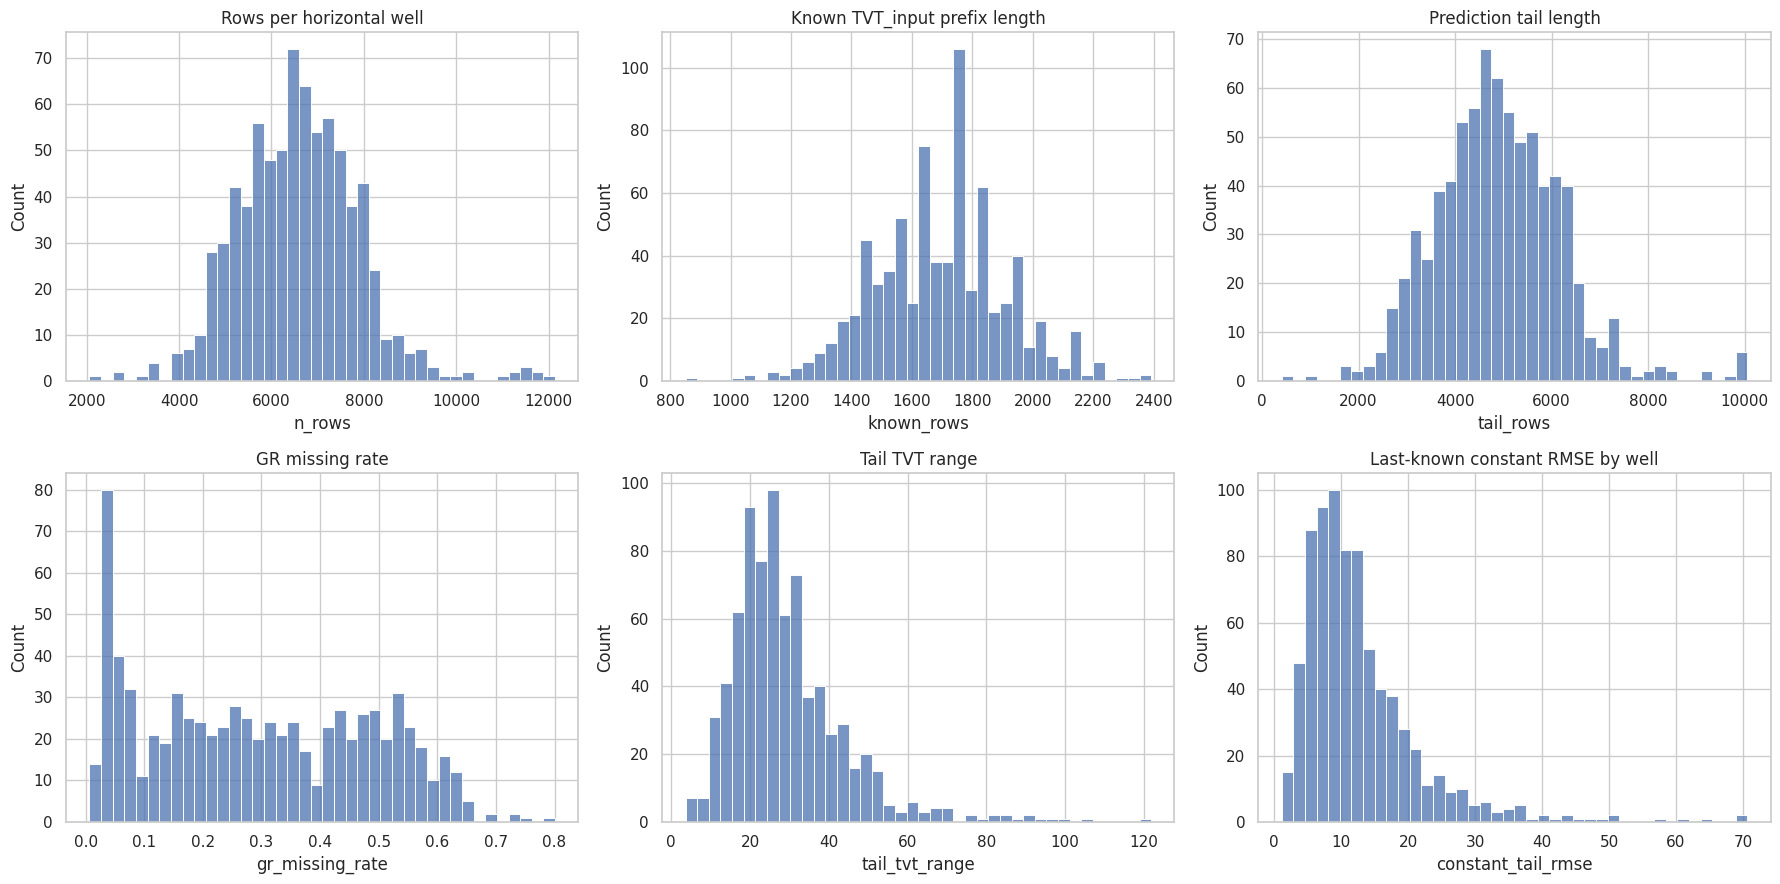

In [7]:
# Summarize well-level distributions that affect validation and model design.

summary_cols = [
    'n_rows', 'known_rows', 'tail_rows', 'ps_index',
    'gr_missing_rate', 'gr_missing_prefix_rate', 'gr_missing_tail_rate',
    'tail_tvt_range', 'tail_end_delta_from_last_known', 'tail_median_abs_step',
    'constant_tail_rmse', 'xy_span', 'z_delta', 'azimuth_deg',
]

display(h_summary[summary_cols].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T)

print('Prediction zone missing group counts:')
print(h_summary['missing_tvt_input_groups'].value_counts().sort_index())

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
plot_specs = [
    ('n_rows', 'Rows per horizontal well'),
    ('known_rows', 'Known TVT_input prefix length'),
    ('tail_rows', 'Prediction tail length'),
    ('gr_missing_rate', 'GR missing rate'),
    ('tail_tvt_range', 'Tail TVT range'),
    ('constant_tail_rmse', 'Last-known constant RMSE by well'),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    sns.histplot(h_summary[col].dropna(), bins=40, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 4.1 Interpretation: Horizontal Summary

| Finding | Modeling implication |
|---|---|
| Missing `TVT_input` forms one tail block | Treat the task as prefix-conditioned forecasting |
| Tail lengths are often thousands of rows | Small slope bias can accumulate |
| GR missingness is substantial | Avoid GR-only models |
| Tail TVT ranges are often tens of feet | `last_known_TVT` is a strong anchor |

Residual target:

$$
\Delta y_{w,i}=y_{w,i}-y_{w,\mathrm{PS}-1}.
$$

🚫 Diagnostic labels such as `tail_rows`, `tail_tvt_range`, `tail_end_delta_from_last_known`, and `constant_tail_rmse` are not strict features.

## 5. Leakage Boundary and Column Roles

### 🗂️ Column role map

| Role | Examples | How the notebook uses it |
|---|---|---|
| **Observable covariates** | `MD`, `X`, `Y`, `Z`, `GR`, typewell logs | direct row features |
| **Known-prefix target** | prefix `TVT_input` | anchor, prefix statistics, GR calibration pairs |
| **Hidden-tail target** | tail `TVT` | labels for train/CV only; never features |
| **Train-only formation surfaces** | `ANCC`, `ASTNU`, `ASTNL`, `EGFDU`, `EGFDL`, `BUDA` | auxiliary labels for fold-safe spatial imputers |

### ✅ Safe pattern

| Step | Action | Leakage status |
|---|---|---:|
| 1 | fit `(X,Y) -> formation top` from training wells | ✅ reference model |
| 2 | project `formation_hat(X,Y)` onto validation/test rows | ✅ reproducible feature |
| 3 | build `TVT ≈ -Z + formation_hat + prefix_bias` | ✅ target-free formula |

### 🚫 Unsafe pattern

| Pattern | Problem |
|---|---|
| use `ANCC` directly as a feature | hidden test horizontal files do not provide it |
| fit the imputer with validation wells inside GroupKFold | fold leakage |
| use tail `TVT` summaries or bfilled target values | direct answer-key leakage |

📌 **Clean distinction:** formation tops are not observed test features, but they can define a fold-safe spatial reference model.


In [8]:
# Classify columns by hidden-test availability and leakage risk.

train_horizontal_columns = set(representative_train_h.columns)
test_horizontal_columns = set(representative_test_h.columns) if representative_test_h is not None else {'MD', 'X', 'Y', 'Z', 'GR', 'TVT_input'}

column_roles = []
for col in representative_train_h.columns:
    if col == 'TVT':
        role = 'target_train_only'
    elif col in {'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA'}:
        role = 'train_only_surface_diagnostic'
    elif col in test_horizontal_columns:
        role = 'safe_hidden_test_feature'
    else:
        role = 'unknown_train_only'
    column_roles.append({'column': col, 'role': role})

display(pd.DataFrame(column_roles))

,column,role
0,MD,safe_hidden_test_feature
1,X,safe_hidden_test_feature
2,Y,safe_hidden_test_feature
3,Z,safe_hidden_test_feature
4,ANCC,train_only_surface_diagnostic
5,ASTNU,train_only_surface_diagnostic
6,ASTNL,train_only_surface_diagnostic
7,EGFDU,train_only_surface_diagnostic
8,EGFDL,train_only_surface_diagnostic
9,BUDA,train_only_surface_diagnostic


## 6. TVT_input Consistency Check

### Statistical role

Verify that `TVT_input` is an exact copy of the target `TVT` in the known prefix.

### Why this matters

If this check passes, prefix trends, last-known TVT, and residual targets can safely be built from `TVT_input`.

<details>
<summary>Consistency condition</summary>

Let $\mathcal{K}_w$ be the row set before Prediction Start. The expected condition is:

$$
\max_{i\in\mathcal{K}_w}\left|\mathrm{TVT}_{w,i}-\mathrm{TVT}_{\mathrm{input},w,i}\right|=0
$$

</details>


In [9]:
# Verify that TVT_input equals TVT throughout the known prefix.

max_abs_prefix_errors = []
for path in train_horizontal_files:
    df = pd.read_csv(path, usecols=['TVT', 'TVT_input'])
    known = df['TVT_input'].notna()
    if known.any():
        max_abs_prefix_errors.append(float((df.loc[known, 'TVT'] - df.loc[known, 'TVT_input']).abs().max()))

print('max over wells of max_abs(TVT - TVT_input) in known prefix:', np.nanmax(max_abs_prefix_errors))
print('wells with non-zero prefix mismatch:', sum(err > 1e-9 for err in max_abs_prefix_errors))

max over wells of max_abs(TVT - TVT_input) in known prefix: 0.0
wells with non-zero prefix mismatch: 0


## 7. Target Behavior, Smoothness, and Jumps

### Statistical role

Measure how smooth the TVT curve is, how much it drifts in the tail, and whether abnormal jumps exist.

### Why this matters

If the target curve is smooth, curve/knot prediction plus smoothing may be more stable than raw row-wise prediction.

<details>
<summary>Target diagnostics</summary>

Row-level step:

$$
\Delta^{step}_{w,i}=y_{w,i}-y_{w,i-1}
$$

Tail end drift:

$$
\Delta^{end}_w=y_{w,\mathrm{end}}-y_{w,\mathrm{PS}-1}
$$

Tail range:

$$
R_w=\max_{i\in\mathcal{T}_w} y_{w,i}-\min_{i\in\mathcal{T}_w} y_{w,i}
$$

</details>


dTVT step percentiles:


,dTVT
count,5.091482e+06
mean,1.089360e-01
std,2.962713e-01
min,-1.513800e+02
1%,-6.000000e-02
5%,-4.000000e-02
25%,-1.000000e-02
50%,0.000000e+00
75%,3.000000e-02
95%,9.100000e-01



Large jump counts:


,count
abs_dTVT_gt_0.1,788895
abs_dTVT_gt_0.5,554067
abs_dTVT_gt_1,100677
abs_dTVT_gt_2,2015
abs_dTVT_gt_5,69
abs_dTVT_gt_10,16
abs_dTVT_gt_25,1
abs_dTVT_gt_50,1
abs_dTVT_gt_100,1


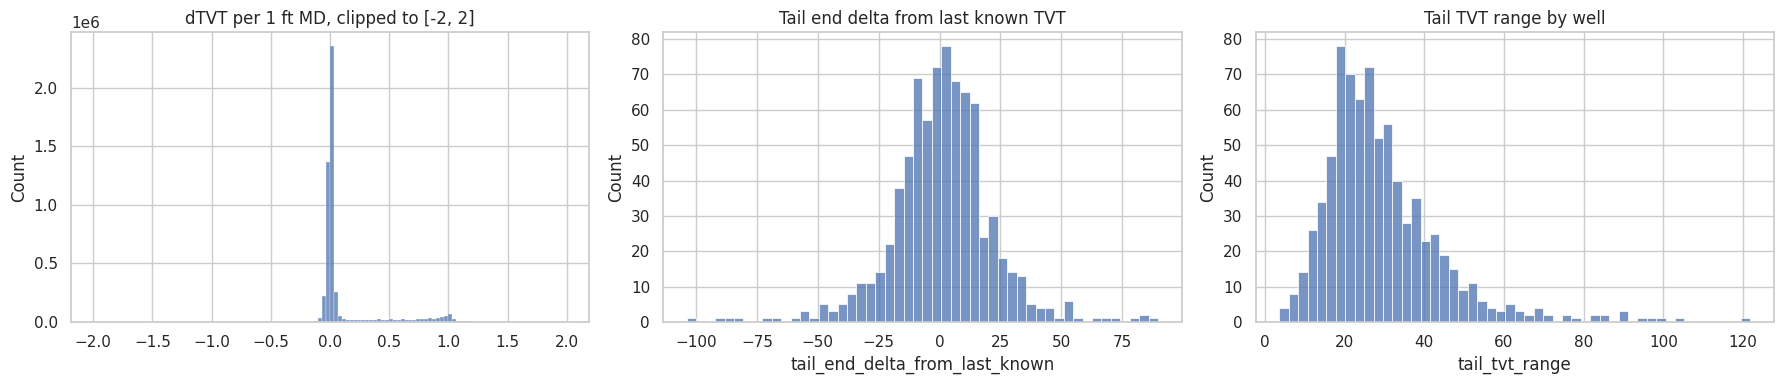

In [10]:
# Measure TVT step smoothness, tail drift, and jump frequency.

# Collect dTVT step distribution and jump counts.
dtvt_values = []
jump_counts = Counter()
for path in train_horizontal_files:
    df = pd.read_csv(path, usecols=['TVT'])
    d = df['TVT'].diff().dropna().to_numpy()
    dtvt_values.append(d)
    for threshold in [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100]:
        jump_counts[f'abs_dTVT_gt_{threshold}'] += int(np.sum(np.abs(d) > threshold))

dtvt_values = np.concatenate(dtvt_values)
print('dTVT step percentiles:')
display(pd.Series(dtvt_values).describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('dTVT'))
print('\nLarge jump counts:')
display(pd.Series(jump_counts).to_frame('count'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(dtvt_values[(dtvt_values > -2) & (dtvt_values < 2)], bins=120, ax=axes[0])
axes[0].set_title('dTVT per 1 ft MD, clipped to [-2, 2]')
sns.histplot(h_summary['tail_end_delta_from_last_known'], bins=50, ax=axes[1])
axes[1].set_title('Tail end delta from last known TVT')
sns.histplot(h_summary['tail_tvt_range'], bins=50, ax=axes[2])
axes[2].set_title('Tail TVT range by well')
plt.tight_layout()
plt.show()

### 7.1 Interpretation: Target Behavior

### What we learned

Most row-level `dTVT` values are small, but wells are not always monotonic. TVT can increase, decrease, or remain nearly constant.

### Modeling implications

1. Blindly extrapolating the prefix slope is risky.
2. Row-wise predictions should use continuity or smoothing postprocessing.
3. A knot-level or curve-level target may be more stable than independent row-level predictions.


## 8. Typewell Data Analysis

### Statistical role

Analyze the typewell vertical reference logs: TVT sampling, GR range, and geology label distribution.

### Key relation

A typewell is a reference GR curve on the TVT axis. The horizontal-well GR sequence can help locate a candidate TVT path along that curve.

<details>
<summary>Reference-curve notation</summary>

$$
GR^{typewell}_w(t), \quad t=TVT
$$

The typewell sampling interval and GR range determine how interpolation and alignment costs should be designed.

</details>


t_summary shape: (773, 10)


,well_id,n_rows,tvt_min,tvt_max,tvt_span,gr_min,gr_median,gr_max,geology_unique_count,mode_tvt_step
0,000d7d20,1296,11223.95,11871.45,647.5,28.66,87.090,158.18,11,0.5
1,00bbac68,1946,11394.45,12366.95,972.5,31.86,98.680,215.44,7,0.5
2,00e12e8b,2556,10593.95,11871.45,1277.5,28.66,102.475,195.42,11,0.5
3,015fe0d2,1265,11734.95,12366.95,632.0,31.86,83.840,215.44,7,0.5
4,01869cd4,1052,11345.95,11871.45,525.5,28.66,78.230,145.21,11,0.5


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
n_rows,773.0,2027.225097,1009.473248,636.00,788.5600,1052.600,1498.00,1874.00,2158.00,3918.000,5916.8400,10043.00
tvt_min,773.0,10828.526300,642.403977,9232.65,9541.3700,9976.170,10341.45,10638.42,11368.45,11907.750,12232.9300,12431.95
tvt_max,773.0,11712.423920,633.834333,10236.85,10327.2820,10956.570,11145.28,11537.41,12202.95,12874.680,12987.4500,12991.53
tvt_span,773.0,883.897620,185.034217,322.00,502.4800,594.996,744.97,907.49,1012.00,1168.082,1291.2516,1399.00
gr_min,773.0,29.041889,5.968945,18.53,18.5300,22.580,24.50,28.29,31.86,38.910,45.4600,48.54
gr_median,773.0,91.345724,15.806548,53.39,63.9636,68.346,80.43,89.98,99.71,125.388,135.0690,147.76
gr_max,773.0,203.453959,39.196750,120.06,120.0600,145.910,168.11,207.01,224.46,273.820,317.9000,433.58
geology_unique_count,773.0,7.693402,1.726184,4.00,6.0000,7.000,7.00,7.00,8.00,11.000,14.0000,22.00
mode_tvt_step,773.0,0.480013,0.124201,0.10,0.2080,0.250,0.50,0.50,0.50,0.500,1.0000,1.00


Top geology labels:


,Geology,row_count
0,<blank>,523474
1,ANCC,294268
2,EGFDL,205397
3,ASTNL,172223
4,BUDA,140640
5,ASTNU,118025
6,EGFDU,70013
7,OLMOS,23345
8,MNSS,5026
9,UPSN,2731


Most common TVT sampling steps:


,TVT_step,count
0,0.50,1147543
1,0.25,322740
2,0.10,68447
3,1.00,17230
4,0.49,7041
5,0.24,2645
6,0.99,623
7,9.00,2
8,2.00,1


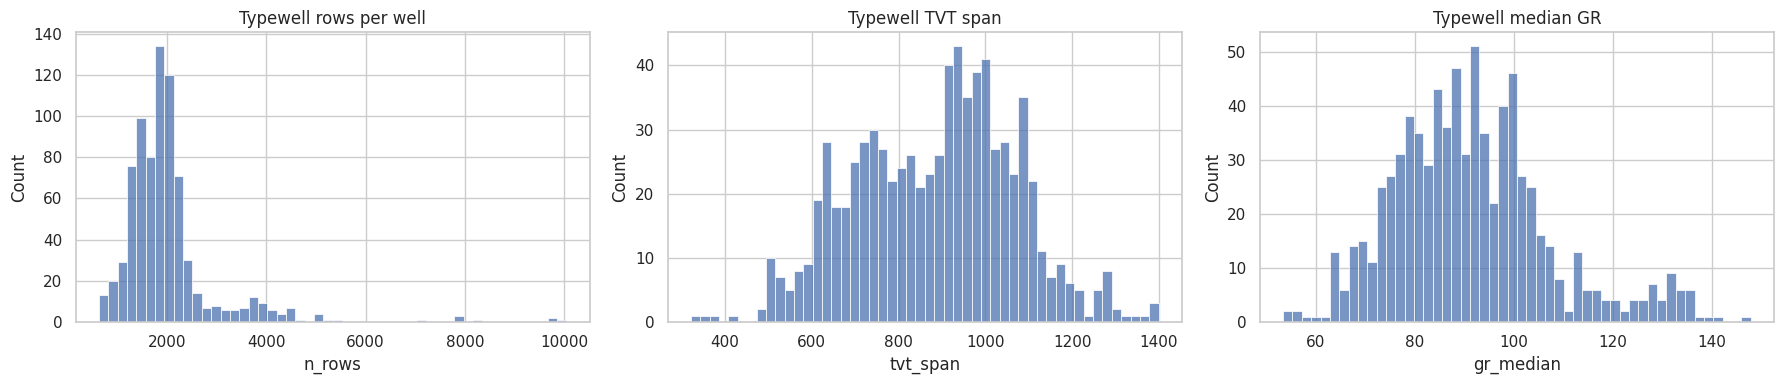

In [11]:
# Summarize typewell TVT sampling, GR ranges, and geology labels.

def summarize_typewell_file(path: Path) -> dict:
    wid = well_id_from_path(path)
    df = pd.read_csv(path)
    steps = df['TVT'].diff().dropna().round(6)
    labels = df['Geology'].fillna('<blank>').astype(str)
    return {
        'well_id': wid,
        'n_rows': len(df),
        'tvt_min': float(df['TVT'].min()),
        'tvt_max': float(df['TVT'].max()),
        'tvt_span': float(df['TVT'].max() - df['TVT'].min()),
        'gr_min': float(df['GR'].min()),
        'gr_median': float(df['GR'].median()),
        'gr_max': float(df['GR'].max()),
        'geology_unique_count': int(labels.nunique()),
        'mode_tvt_step': float(steps.mode().iloc[0]) if len(steps) else np.nan,
    }

t_summary = pd.DataFrame([summarize_typewell_file(path) for path in train_typewell_files])
print('t_summary shape:', t_summary.shape)
display(t_summary.head())
display(t_summary.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

geology_counter = Counter()
tvt_step_counter = Counter()
for path in train_typewell_files:
    df = pd.read_csv(path)
    geology_counter.update(df['Geology'].fillna('<blank>').astype(str).tolist())
    tvt_step_counter.update(df['TVT'].diff().dropna().round(6).tolist())

print('Top geology labels:')
display(pd.DataFrame(geology_counter.most_common(25), columns=['Geology', 'row_count']))
print('Most common TVT sampling steps:')
display(pd.DataFrame(tvt_step_counter.most_common(10), columns=['TVT_step', 'count']))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(t_summary['n_rows'], bins=50, ax=axes[0])
axes[0].set_title('Typewell rows per well')
sns.histplot(t_summary['tvt_span'], bins=50, ax=axes[1])
axes[1].set_title('Typewell TVT span')
sns.histplot(t_summary['gr_median'], bins=50, ax=axes[2])
axes[2].set_title('Typewell median GR')
plt.tight_layout()
plt.show()

## 9. Known-Prefix GR Alignment Signal

### Statistical role

Measure how well horizontal GR matches typewell GR on the same TVT axis in the known prefix.

### Statistical caution

GR has many missing values and a noisy response, so the prefix correlation should be treated as a confidence feature. Low correlation does not prove that the typewell is useless.

<details>
<summary>Prefix alignment diagnostic</summary>

For known-prefix rows $\mathcal{K}_w$, interpolate typewell GR at the `TVT_input` positions:

$$
\tilde{g}^{\mathrm{type}}_{w,i}=GR^{\mathrm{typewell}}_w(\mathrm{TVT}_{\mathrm{input},w,i})
$$

Correlation diagnostic:

$$
\rho_w=\mathrm{corr}\left(GR^{\mathrm{horizontal}}_{w,i},\tilde{g}^{\mathrm{type}}_{w,i}\right), \quad i\in\mathcal{K}_w
$$

</details>


,count,mean,std,min,5%,25%,50%,75%,95%,max
known_valid_gr_points,773.0,1289.461837,333.500721,312.000000,766.000000,1043.000000,1287.000000,1507.000000,1851.600000,2277.000000
prefix_horizontal_vs_typewell_gr_corr,773.0,0.800513,0.094557,0.221863,0.623657,0.754307,0.814059,0.864433,0.928478,0.973147
prefix_horizontal_gr_mean,773.0,88.117946,13.726072,44.076476,71.323877,79.361165,85.250739,92.343645,117.256925,135.138929
prefix_typewell_gr_mean_at_tvt,773.0,89.186153,13.845444,46.509541,71.660642,81.052372,86.199790,93.079642,120.482471,132.250274
constant_tail_rmse,773.0,12.812466,8.899487,1.115949,3.858922,7.100676,10.665141,15.811256,29.010764,70.639375
gr_missing_prefix_rate,773.0,0.236005,0.161047,0.003636,0.032707,0.096257,0.203089,0.374840,0.514256,0.725352


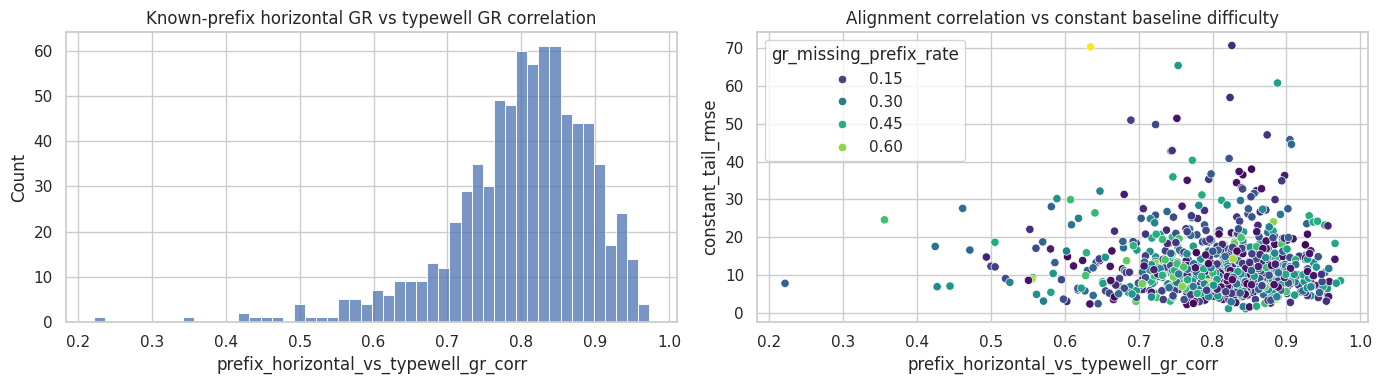

In [12]:
# Interpolate typewell GR onto known-prefix TVT positions and compute horizontal/typewell GR correlation.

def typewell_gr_at_tvt(typewell_df: pd.DataFrame, tvt_values: np.ndarray) -> np.ndarray:
    tw = typewell_df[['TVT', 'GR']].dropna().sort_values('TVT')
    if len(tw) < 2:
        return np.full(len(tvt_values), np.nan)
    x = tw['TVT'].to_numpy()
    y = tw['GR'].to_numpy()
    pred = np.interp(tvt_values, x, y, left=np.nan, right=np.nan)
    return pred

def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    valid = np.isfinite(a) & np.isfinite(b)
    if valid.sum() < 30:
        return np.nan
    aa = a[valid]
    bb = b[valid]
    if np.nanstd(aa) < 1e-9 or np.nanstd(bb) < 1e-9:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])

alignment_rows = []
for path in train_horizontal_files:
    wid = well_id_from_path(path)
    h = pd.read_csv(path, usecols=['GR', 'TVT_input'])
    tw = pd.read_csv(TRAIN_DIR / f'{wid}__typewell.csv')
    known = h['TVT_input'].notna()
    hv = h.loc[known, 'GR'].to_numpy()
    tvt = h.loc[known, 'TVT_input'].to_numpy()
    tw_gr = typewell_gr_at_tvt(tw, tvt)
    valid = np.isfinite(hv) & np.isfinite(tw_gr)
    alignment_rows.append({
        'well_id': wid,
        'known_valid_gr_points': int(valid.sum()),
        'prefix_horizontal_vs_typewell_gr_corr': safe_corr(hv, tw_gr),
        'prefix_horizontal_gr_mean': float(np.nanmean(hv)) if np.isfinite(hv).any() else np.nan,
        'prefix_typewell_gr_mean_at_tvt': float(np.nanmean(tw_gr)) if np.isfinite(tw_gr).any() else np.nan,
    })

alignment = pd.DataFrame(alignment_rows).merge(h_summary[['well_id', 'constant_tail_rmse', 'gr_missing_prefix_rate']], on='well_id', how='left')
display(alignment.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(alignment['prefix_horizontal_vs_typewell_gr_corr'].dropna(), bins=50, ax=axes[0])
axes[0].set_title('Known-prefix horizontal GR vs typewell GR correlation')
sns.scatterplot(
    data=alignment,
    x='prefix_horizontal_vs_typewell_gr_corr',
    y='constant_tail_rmse',
    hue='gr_missing_prefix_rate',
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title('Alignment correlation vs constant baseline difficulty')
plt.tight_layout()
plt.show()

## 10. Baseline Evaluation

### Statistical role

Quantify simple baselines before fitting any model.

### Why this matters

If the constant baseline is strong, a model must avoid damaging flat wells. If linear extrapolation is weak, directly extending the prefix slope is dangerous.

<details>
<summary>Baseline definitions</summary>

Constant baseline:

$$
\hat{y}^{\mathrm{const}}_{w,i}=\mathrm{TVT}_{\mathrm{input},w,\mathrm{PS}-1}
$$

Linear prefix extrapolation baseline:

$$
\hat{y}^{\mathrm{linear}}_{w,i}=a_w x_{w,i}+b_w
$$

where $a_w,b_w$ are fitted only on the known prefix `TVT_input` values.

</details>


,baseline,global_row_rmse,n_rows
0,last_known_constant,15.909853,3783989
3,last200_linear_md,124.001065,3783989
2,prefix_linear_z,124.231947,3783989
4,last200_linear_z,146.485388,3783989
1,prefix_linear_md,1404.728336,3783989


,count,mean,std,min,5%,25%,50%,75%,95%,max
tail_rows,773.0,4895.199224,1301.178409,407.000000,2947.400000,4044.000000,4840.000000,5694.000000,6918.400000,10052.000000
last_known_constant_rmse,773.0,12.812466,8.899487,1.115949,3.858922,7.100676,10.665141,15.811256,29.010764,70.639375
prefix_linear_md_rmse,773.0,1258.170358,418.587351,169.506463,668.655159,965.363152,1239.282431,1512.467107,1965.274373,3058.918252
prefix_linear_z_rmse,773.0,110.877685,41.389954,13.498088,46.688249,82.724196,107.135329,133.172169,183.579024,291.536313
last200_linear_md_rmse,773.0,59.452331,98.417070,1.909203,6.822692,16.710839,35.607203,77.093446,160.471945,1537.535549
last200_linear_z_rmse,773.0,69.509301,121.204618,2.122070,6.441952,16.049861,33.814175,69.824564,265.511439,1687.402266


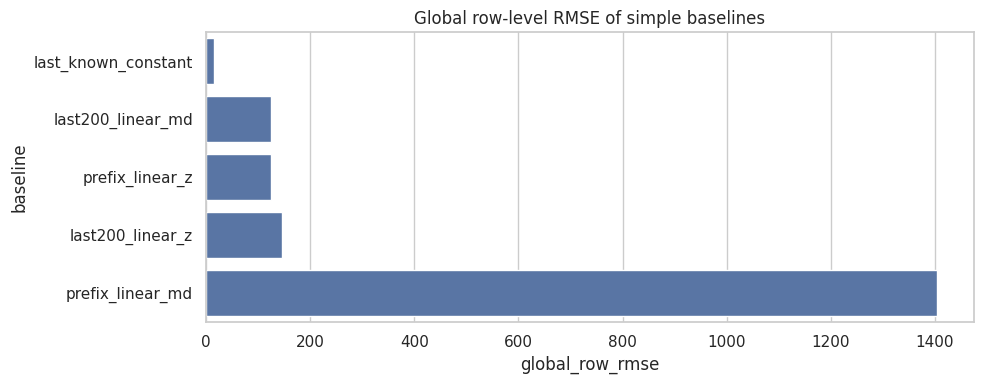

In [13]:
# Evaluate constant and linear baselines on the supervised prediction tail.

def rmse_from_sse(sse: float, n: int) -> float:
    return float(np.sqrt(sse / n)) if n else np.nan

baseline_sse = Counter()
baseline_n = Counter()
per_well_baseline = []

for path in train_horizontal_files:
    wid = well_id_from_path(path)
    df = pd.read_csv(path, usecols=['MD', 'Z', 'TVT', 'TVT_input'])
    mask = df['TVT_input'].isna().to_numpy()
    if not mask.any():
        continue
    known_idx = np.flatnonzero(~mask)
    tail_idx = np.flatnonzero(mask)
    tvt = df['TVT'].to_numpy()
    tvt_input = df['TVT_input'].to_numpy()
    md = df['MD'].to_numpy()
    z = df['Z'].to_numpy()
    known_y = tvt_input[known_idx]
    last_known = float(known_y[-1])
    yy = tvt[tail_idx]
    predictions = {}
    predictions['last_known_constant'] = np.full(len(tail_idx), last_known)
    
    # Intentionally naive baselines: useful to prove that blind extrapolation is dangerous.
    for name, x, idx in [
        ('prefix_linear_md', md, known_idx),
        ('prefix_linear_z', z, known_idx),
    ]:
        coef = np.polyfit(x[idx], known_y, 1)
        predictions[name] = np.polyval(coef, x[tail_idx])
    
    last200_idx = known_idx[-min(200, len(known_idx)):]
    for name, x in [('last200_linear_md', md), ('last200_linear_z', z)]:
        last200_y = tvt_input[last200_idx]
        coef = np.polyfit(x[last200_idx], last200_y, 1)
        predictions[name] = np.polyval(coef, x[tail_idx])
    
    row = {'well_id': wid, 'tail_rows': len(tail_idx)}
    for name, pred in predictions.items():
        err = pred - yy
        sse = float(np.sum(err ** 2))
        baseline_sse[name] += sse
        baseline_n[name] += len(err)
        row[f'{name}_rmse'] = float(np.sqrt(np.mean(err ** 2)))
    per_well_baseline.append(row)

baseline_report = pd.DataFrame({
    'baseline': list(baseline_sse.keys()),
    'global_row_rmse': [rmse_from_sse(baseline_sse[k], baseline_n[k]) for k in baseline_sse.keys()],
    'n_rows': [baseline_n[k] for k in baseline_sse.keys()],
}).sort_values('global_row_rmse')
per_well_baseline = pd.DataFrame(per_well_baseline)

display(baseline_report)
display(per_well_baseline.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=baseline_report, x='global_row_rmse', y='baseline', ax=ax)
ax.set_title('Global row-level RMSE of simple baselines')
plt.tight_layout()
plt.show()

### 10.1 Interpretation: Baseline Evaluation

### What the baseline means

`last_known_constant` is the null model: the tail stays at the final known TVT anchor.

### Modeling implication

To beat this baseline, a model must gain on drifting wells without creating unnecessary movement on flat wells. Residual prediction with shrinkage and clipping directly controls this trade-off.

<details>
<summary>Null residual form</summary>

$$
H_0: \Delta y_{w,i}=0
$$

</details>


## 🧱 11. Row-Level Features

### Domain framing

The target is a hidden coordinate transform from measured depth to typewell TVT. The feature table combines anchor context, current-row geometry, GR texture, typewell matching, and optional spatial geology references.

<details>
<summary>Coordinate-transform framing</summary>

$$
t_i=\phi_w(MD_i).
$$

A simplified log-correlation model is:

$$
GR^{horizontal}_{w,i}\approx a_w\,GR^{typewell}_w(t_i)+b_w+\epsilon_i.
$$

The calibration coefficients $a_w,b_w$ are estimated only on the known prefix.

</details>

### Strict feature groups

| Group | Examples | Leakage boundary |
|---|---|---|
| Prefix context | prefix length, GR stats, TVT range, prefix slopes | prefix only |
| Row position | `MD_i - MD_PS`, `X_i - X_PS`, `Y_i - Y_PS`, `Z_i - Z_PS` | current row |
| Current GR | raw GR, prefix-normalized GR, missing flag | current row |
| GR events | backward differences, MD-normalized slopes | rows up to `i` |
| Trailing GR context | rolling mean/std/range | rows up to `i` |
| Typewell alignment | typewell GR at prefix-derived TVT baselines | no true tail TVT |
| Local offset search | best GR match around prefix-derived baseline | target-free GR only |
| Calibrated typewell | affine-calibrated typewell residuals | prefix fit only |
| Typewell interval context | Geology interval phase at prefix-derived TVT positions | reference data + prefix baseline |

### Offline feature groups

| Feature | Why offline-only |
|---|---|
| Tail length / tail fraction | uses the full prediction tail |
| Full-row fraction and MD tail fraction | uses full test-file geometry |
| Gap geometry and GR quantiles | summarizes the full hidden interval |
| Centered GR rolling and lead/lag GR | uses future GR covariates, not future TVT labels |
| Candidate-path typewell endpoints | uses tail fraction to compare plausible TVT drift paths |
| Formation-plane/KNN references | projects train formation-top geometry onto target-free coordinates |
| Beam-path typewell alignment | uses the full hidden GR sequence to form a path feature |

<details>
<summary>Residual target and local alignment equations</summary>

Residual target:

$$
\Delta^{\mathrm{target}}_{w,i}=\mathrm{TVT}_{w,i}-\mathrm{TVT}_{\mathrm{input},w,\mathrm{PS}-1}.
$$

Prefix-derived baseline:

$$
B_{w,i}=y_{w,\mathrm{PS}-1}+\hat{\beta}^{\mathrm{prefix}}_w(MD_i-MD_{PS}).
$$

Local offset search:

$$
\delta^*_{w,i}=\arg\min_{\delta\in\mathcal{D}}
\left|GR^{horizontal}_{w,i}-GR^{typewell}_w(B_{w,i}+\delta)\right|.
$$

</details>

🚫 Excluded from all policies: `TVT_input_bfill`, true tail `TVT`, target-derived tail summaries, true future TVT knots, and direct train-only surface columns.


In [14]:
# Construct leakage-safe row-level tail features and residual targets for one well.

def safe_slope(x: np.ndarray, y: np.ndarray) -> float:
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan
    if np.nanstd(x[valid]) < 1e-9:
        return np.nan
    return float(np.polyfit(x[valid], y[valid], 1)[0])


def normalize_required_feature_columns(required_feature_columns) -> set[str] | None:
    if required_feature_columns is None:
        return None
    return {str(col) for col in required_feature_columns}


def needs_any(required_columns: set[str] | None, prefixes=(), exact=()) -> bool:
    if required_columns is None:
        return True
    prefixes = tuple(prefixes)
    exact = set(exact)
    for col in required_columns:
        if col in exact or any(col.startswith(prefix) for prefix in prefixes):
            return True
    return False




def typewell_gr_at_tvt(typewell_df: pd.DataFrame, tvt_values: np.ndarray) -> np.ndarray:
    if not {'TVT', 'GR'}.issubset(typewell_df.columns):
        return np.full(len(tvt_values), np.nan)
    tw = typewell_df[['TVT', 'GR']].dropna().sort_values('TVT')
    if len(tw) < 2:
        return np.full(len(tvt_values), np.nan)
    x = tw['TVT'].to_numpy(dtype=float)
    y = tw['GR'].to_numpy(dtype=float)
    return np.interp(np.asarray(tvt_values, dtype=float), x, y, left=np.nan, right=np.nan)


def safe_corr(a: np.ndarray, b: np.ndarray, min_points: int = 30) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    if valid.sum() < min_points:
        return np.nan
    aa = a[valid]
    bb = b[valid]
    if np.nanstd(aa) < 1e-9 or np.nanstd(bb) < 1e-9:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])


def recent_mean_diff(values: np.ndarray, window: int) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = values[-(window + 1):]
    if len(values) < 2:
        return np.nan
    return float(np.diff(values).mean())


def recent_slope_window(y_values: np.ndarray, x_values: np.ndarray, window: int) -> float:
    y_values = np.asarray(y_values, dtype=float)[-window:]
    x_values = np.asarray(x_values, dtype=float)[-window:]
    valid = np.isfinite(y_values) & np.isfinite(x_values)
    if valid.sum() < 2:
        return np.nan
    x = x_values[valid]
    y = y_values[valid]
    centered_x = x - x.mean()
    denominator = float(np.dot(centered_x, centered_x))
    if denominator <= 1e-12:
        return np.nan
    return float(np.dot(centered_x, y - y.mean()) / denominator)


def nearest_sorted_index(sorted_values: np.ndarray, target: float) -> int:
    values = np.asarray(sorted_values, dtype=float)
    if len(values) == 0:
        return 0
    idx = int(np.searchsorted(values, target, side='left'))
    if idx >= len(values):
        return len(values) - 1
    if idx > 0 and abs(values[idx - 1] - target) <= abs(values[idx] - target):
        return idx - 1
    return idx


def smooth_gr_for_beam(values: np.ndarray, fallback: float, radius: int) -> np.ndarray:
    series = pd.Series(values, dtype='float64').interpolate(limit_direction='both').fillna(fallback)
    if radius <= 0:
        return series.to_numpy(dtype=float)
    return series.rolling(radius * 2 + 1, center=True, min_periods=1).mean().to_numpy(dtype=float)


def beam_typewell_path(
    gr_values: np.ndarray,
    tw_tvt: np.ndarray,
    tw_gr: np.ndarray,
    start_tvt: float,
    beam_size: int = 10,
    move_cost: float = 20.0,
    emit_scale: float = 144.0,
    radius: int = 2,
) -> np.ndarray:
    tw_tvt = np.asarray(tw_tvt, dtype=float)
    tw_gr = np.asarray(tw_gr, dtype=float)
    valid_tw = np.isfinite(tw_tvt) & np.isfinite(tw_gr)
    tw_tvt = tw_tvt[valid_tw]
    tw_gr = tw_gr[valid_tw]
    order = np.argsort(tw_tvt)
    tw_tvt = tw_tvt[order]
    tw_gr = tw_gr[order]
    n = len(gr_values)
    if n == 0 or len(tw_tvt) < 2 or not np.isfinite(start_tvt):
        return np.full(n, np.nan)

    fallback = float(np.nanmean(tw_gr)) if np.isfinite(np.nanmean(tw_gr)) else 0.0
    smoothed_gr = smooth_gr_for_beam(gr_values, fallback=fallback, radius=radius)
    start_idx = nearest_sorted_index(tw_tvt, start_tvt)
    states = {start_idx: 0.0}
    backpointers: list[dict[int, int]] = []

    for gr_value in smoothed_gr:
        candidates: dict[int, float] = {}
        parents: dict[int, int] = {}
        if not np.isfinite(gr_value):
            gr_value = fallback
        for idx, cost in states.items():
            for delta in (-1, 0, 1):
                next_idx = idx + delta
                if next_idx < 0 or next_idx >= len(tw_tvt):
                    continue
                emit_cost = ((gr_value - tw_gr[next_idx]) ** 2) / max(emit_scale, 1e-6)
                total_cost = cost + emit_cost + move_cost * abs(delta)
                if next_idx not in candidates or total_cost < candidates[next_idx]:
                    candidates[next_idx] = float(total_cost)
                    parents[next_idx] = idx
        kept = sorted(candidates.items(), key=lambda item: item[1])[:beam_size]
        if not kept:
            return np.full(n, np.nan)
        states = {idx: cost for idx, cost in kept}
        backpointers.append({idx: parents[idx] for idx, _ in kept})

    final_idx = min(states, key=states.get)
    path = [final_idx]
    for step in range(len(backpointers) - 1, 0, -1):
        path.append(backpointers[step][path[-1]])
    path.reverse()
    return tw_tvt[np.asarray(path, dtype=int)]


def offline_beam_feature_names(prefix: str = 'tw_beam') -> list[str]:
    names = [
        f'{prefix}_tight_delta',
        f'{prefix}_conservative_delta',
        f'{prefix}_loose_delta',
        f'{prefix}_vloose_delta',
        f'{prefix}_gap',
        f'{prefix}_spread',
        f'{prefix}_mean_delta',
        f'{prefix}_std_delta',
        f'{prefix}_tight_step',
        f'{prefix}_conservative_step',
        f'{prefix}_loose_step',
        f'{prefix}_vloose_step',
        f'{prefix}_gr_at_conservative',
        f'{prefix}_gr_at_loose',
        f'{prefix}_gr_minus_conservative',
        f'{prefix}_gr_minus_loose',
    ]
    if prefix == 'tw_beam':
        names += [
            'beam_tight_delta',
            'beam_cons_delta',
            'beam_loose_delta',
            'beam_vloose_delta',
            'beam_mean_delta',
            'beam_std_delta',
            'beam_spread',
            'beam_gap',
            'gr_minus_tw_beam_cons',
            'gr_minus_tw_beam_loose',
        ]
    return names

def safe_stat(series, func) -> float:
    values = pd.to_numeric(series, errors='coerce').to_numpy(dtype=float)
    valid = np.isfinite(values)
    if not valid.any():
        return np.nan
    return float(func(values[valid]))


def safe_affine_fit(x: np.ndarray, y: np.ndarray, min_points: int = 30) -> tuple[float, float]:
    """Fit y ~= a*x + b using only finite prefix points."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < min_points or np.nanstd(x[valid]) < 1e-9:
        return np.nan, np.nan
    a, b = np.polyfit(x[valid], y[valid], 1)
    return float(a), float(b)


def apply_affine(x: np.ndarray | float, a: float, b: float):
    if np.isfinite(a) and np.isfinite(b):
        return a * x + b
    return np.full_like(np.asarray(x, dtype=float), np.nan, dtype=float)



def local_typewell_offset_features(
    typewell_df: pd.DataFrame,
    baseline_tvt: np.ndarray,
    horizontal_gr: np.ndarray,
    offsets: np.ndarray,
    affine_a: float | None = None,
    affine_b: float | None = None,
    score_scale: float = 20.0,
    prefix: str = 'typewell_local',
) -> dict[str, np.ndarray]:
    baseline_tvt = np.asarray(baseline_tvt, dtype=float)
    horizontal_gr = np.asarray(horizontal_gr, dtype=float)
    offsets = np.asarray(offsets, dtype=float)
    n = len(baseline_tvt)
    if n == 0 or len(offsets) == 0:
        return {
            f'{prefix}_best_delta': np.full(n, np.nan),
            f'{prefix}_best_abs_resid': np.full(n, np.nan),
            f'{prefix}_zero_abs_resid': np.full(n, np.nan),
            f'{prefix}_top2_gap': np.full(n, np.nan),
            f'{prefix}_soft_delta_mean': np.full(n, np.nan),
            f'{prefix}_best_gr': np.full(n, np.nan),
        }
    candidate_tvt = baseline_tvt[:, None] + offsets[None, :]
    candidate_gr = typewell_gr_at_tvt(typewell_df, candidate_tvt.reshape(-1)).reshape(n, len(offsets))
    if affine_a is not None and affine_b is not None and np.isfinite(affine_a) and np.isfinite(affine_b):
        candidate_gr = affine_a * candidate_gr + affine_b
    abs_resid = np.abs(horizontal_gr[:, None] - candidate_gr)
    valid = np.isfinite(abs_resid)
    masked = np.where(valid, abs_resid, np.inf)
    any_valid = valid.any(axis=1)
    best_idx = np.argmin(masked, axis=1)
    best_abs = np.where(any_valid, masked[np.arange(n), best_idx], np.nan)
    best_delta = np.where(any_valid, offsets[best_idx], np.nan)
    best_gr = np.where(any_valid, candidate_gr[np.arange(n), best_idx], np.nan)
    zero_idx = int(np.argmin(np.abs(offsets)))
    zero_abs = abs_resid[:, zero_idx] if len(offsets) else np.full(n, np.nan)
    if len(offsets) >= 2:
        sorted_abs = np.sort(masked, axis=1)
        top2_gap = np.full(n, np.nan)
        top2_ok = any_valid & np.isfinite(sorted_abs[:, 1])
        top2_gap[top2_ok] = sorted_abs[top2_ok, 1] - sorted_abs[top2_ok, 0]
    else:
        top2_gap = np.full(n, np.nan)
    weights = np.zeros_like(abs_resid, dtype=float)
    weights[valid] = np.exp(-abs_resid[valid] / score_scale)
    denom = weights.sum(axis=1)
    soft_delta = np.full(n, np.nan)
    denom_ok = denom > 0
    soft_delta[denom_ok] = (weights[denom_ok] * offsets[None, :]).sum(axis=1) / denom[denom_ok]
    return {
        f'{prefix}_best_delta': best_delta,
        f'{prefix}_best_abs_resid': best_abs,
        f'{prefix}_zero_abs_resid': zero_abs,
        f'{prefix}_top2_gap': top2_gap,
        f'{prefix}_soft_delta_mean': soft_delta,
        f'{prefix}_best_gr': best_gr,
    }

CANDIDATE_PATH_ENDPOINTS = np.array([-60.0, -40.0, -25.0, -15.0, -8.0, 0.0, 8.0, 15.0, 25.0, 40.0, 60.0])


def candidate_endpoint_label(endpoint: float) -> str:
    sign = 'm' if endpoint < 0 else 'p'
    value = str(int(abs(endpoint))) if float(endpoint).is_integer() else str(abs(endpoint)).replace('.', 'p')
    return f'{sign}{value}'


def candidate_path_feature_names(prefix: str = 'tw_path', endpoints: np.ndarray = CANDIDATE_PATH_ENDPOINTS) -> list[str]:
    names: list[str] = []
    for endpoint in endpoints:
        label = candidate_endpoint_label(float(endpoint))
        names.extend([
            f'{prefix}_gr_diff_{label}',
            f'{prefix}_gr_absdiff_{label}',
            f'{prefix}_boundary_count_{label}',
            f'{prefix}_boundary_nearest_{label}',
        ])
    names.extend([
        f'{prefix}_min_absdiff',
        f'{prefix}_best_endpoint',
        f'{prefix}_best_endpoint_centered',
        f'{prefix}_top2_absdiff_gap',
        f'{prefix}_soft_endpoint_mean',
        f'{prefix}_best_gr_resid',
    ])
    return names


def typewell_boundary_tvt(typewell_df: pd.DataFrame) -> np.ndarray:
    if 'Geology' not in typewell_df.columns or 'TVT' not in typewell_df.columns:
        return np.array([], dtype=float)
    tw = typewell_df[['TVT', 'Geology']].dropna().sort_values('TVT')
    if len(tw) < 2:
        return np.array([], dtype=float)
    tvt = pd.to_numeric(tw['TVT'], errors='coerce').to_numpy(dtype=float)
    geology = tw['Geology'].astype(str).to_numpy()
    valid = np.isfinite(tvt)
    tvt = tvt[valid]
    geology = geology[valid]
    if len(tvt) < 2:
        return np.array([], dtype=float)
    change_idx = np.flatnonzero(geology[1:] != geology[:-1]) + 1
    return tvt[change_idx]




def typewell_interval_boundaries(typewell_df: pd.DataFrame) -> np.ndarray:
    if 'TVT' not in typewell_df.columns:
        return np.array([], dtype=float)
    tvt = pd.to_numeric(typewell_df['TVT'], errors='coerce').dropna().to_numpy(dtype=float)
    if len(tvt) < 2:
        return np.array([], dtype=float)
    boundaries = typewell_boundary_tvt(typewell_df)
    bounds = np.unique(np.r_[np.nanmin(tvt), boundaries, np.nanmax(tvt)])
    return np.sort(bounds[np.isfinite(bounds)])


def typewell_interval_context_features(typewell_df: pd.DataFrame, target_tvt, prefix: str) -> dict[str, np.ndarray]:
    target = np.asarray(target_tvt, dtype=float)
    original_shape = target.shape
    target_flat = target.reshape(-1)
    bounds = typewell_interval_boundaries(typewell_df)
    out = {
        f'{prefix}_prev_boundary_dist': np.full(len(target_flat), np.nan),
        f'{prefix}_next_boundary_dist': np.full(len(target_flat), np.nan),
        f'{prefix}_interval_thickness': np.full(len(target_flat), np.nan),
        f'{prefix}_interval_phase': np.full(len(target_flat), np.nan),
        f'{prefix}_interval_phase_sin': np.full(len(target_flat), np.nan),
        f'{prefix}_interval_phase_cos': np.full(len(target_flat), np.nan),
        f'{prefix}_boundary_balance': np.full(len(target_flat), np.nan),
        f'{prefix}_boundary_proximity': np.full(len(target_flat), np.nan),
    }
    if len(bounds) < 2:
        return {k: v.reshape(original_shape) for k, v in out.items()}
    valid = np.isfinite(target_flat)
    if valid.any():
        idx = np.searchsorted(bounds, target_flat[valid], side='right') - 1
        idx = np.clip(idx, 0, len(bounds) - 2)
        top = bounds[idx]
        base = bounds[idx + 1]
        thickness = base - top
        ok = np.isfinite(thickness) & (np.abs(thickness) > 1e-9)
        valid_positions = np.flatnonzero(valid)
        rows = valid_positions[ok]
        phase = (target_flat[rows] - top[ok]) / thickness[ok]
        prev_dist = target_flat[rows] - top[ok]
        next_dist = base[ok] - target_flat[rows]
        out[f'{prefix}_prev_boundary_dist'][rows] = prev_dist
        out[f'{prefix}_next_boundary_dist'][rows] = next_dist
        out[f'{prefix}_interval_thickness'][rows] = thickness[ok]
        out[f'{prefix}_interval_phase'][rows] = phase
        out[f'{prefix}_interval_phase_sin'][rows] = np.sin(np.pi * phase)
        out[f'{prefix}_interval_phase_cos'][rows] = np.cos(np.pi * phase)
        out[f'{prefix}_boundary_balance'][rows] = (next_dist - prev_dist) / (thickness[ok] + 1e-6)
        out[f'{prefix}_boundary_proximity'][rows] = np.minimum(prev_dist, next_dist) / (thickness[ok] + 1e-6)
    return {k: v.reshape(original_shape) for k, v in out.items()}


def typewell_interval_context_feature_names(prefix: str) -> list[str]:
    return [
        f'{prefix}_prev_boundary_dist',
        f'{prefix}_next_boundary_dist',
        f'{prefix}_interval_thickness',
        f'{prefix}_interval_phase',
        f'{prefix}_interval_phase_sin',
        f'{prefix}_interval_phase_cos',
        f'{prefix}_boundary_balance',
        f'{prefix}_boundary_proximity',
    ]

def boundary_count_between(boundaries: np.ndarray, start_tvt: float, target_tvt: np.ndarray) -> np.ndarray:
    target_tvt = np.asarray(target_tvt, dtype=float)
    if len(boundaries) == 0 or not np.isfinite(start_tvt):
        return np.full(len(target_tvt), np.nan)
    lo = np.minimum(start_tvt, target_tvt)
    hi = np.maximum(start_tvt, target_tvt)
    valid = np.isfinite(lo) & np.isfinite(hi)
    counts = np.full(len(target_tvt), np.nan)
    if valid.any():
        counts[valid] = ((boundaries[None, :] > lo[valid, None]) & (boundaries[None, :] <= hi[valid, None])).sum(axis=1)
    return counts


def nearest_boundary_distance(boundaries: np.ndarray, target_tvt: np.ndarray) -> np.ndarray:
    target_tvt = np.asarray(target_tvt, dtype=float)
    if len(boundaries) == 0:
        return np.full(len(target_tvt), np.nan)
    dist = np.full(len(target_tvt), np.nan)
    valid = np.isfinite(target_tvt)
    if valid.any():
        dist[valid] = np.min(np.abs(target_tvt[valid, None] - boundaries[None, :]), axis=1)
    return dist


def typewell_candidate_path_features(
    typewell_df: pd.DataFrame,
    last_known_tvt: float,
    tail_frac: np.ndarray,
    horizontal_gr: np.ndarray,
    endpoints: np.ndarray = CANDIDATE_PATH_ENDPOINTS,
    prefix: str = 'tw_path',
    score_scale: float = 20.0,
) -> dict[str, np.ndarray]:
    tail_frac = np.asarray(tail_frac, dtype=float)
    horizontal_gr = np.asarray(horizontal_gr, dtype=float)
    endpoints = np.asarray(endpoints, dtype=float)
    n = len(tail_frac)
    if n == 0 or len(endpoints) == 0 or not np.isfinite(last_known_tvt):
        return {name: np.full(n, np.nan) for name in candidate_path_feature_names(prefix, endpoints)}

    candidate_tvt = last_known_tvt + tail_frac[:, None] * endpoints[None, :]
    candidate_gr = typewell_gr_at_tvt(typewell_df, candidate_tvt.reshape(-1)).reshape(n, len(endpoints))
    gr_diff = horizontal_gr[:, None] - candidate_gr
    absdiff = np.abs(gr_diff)
    valid = np.isfinite(absdiff)
    masked = np.where(valid, absdiff, np.inf)
    any_valid = valid.any(axis=1)
    best_idx = np.argmin(masked, axis=1)
    best_abs = np.where(any_valid, masked[np.arange(n), best_idx], np.nan)
    best_endpoint = np.where(any_valid, endpoints[best_idx], np.nan)
    best_gr = np.where(any_valid, candidate_gr[np.arange(n), best_idx], np.nan)

    if len(endpoints) >= 2:
        sorted_abs = np.sort(masked, axis=1)
        top2_gap = np.full(n, np.nan)
        top2_ok = any_valid & np.isfinite(sorted_abs[:, 1])
        top2_gap[top2_ok] = sorted_abs[top2_ok, 1] - sorted_abs[top2_ok, 0]
    else:
        top2_gap = np.full(n, np.nan)

    weights = np.zeros_like(absdiff, dtype=float)
    weights[valid] = np.exp(-absdiff[valid] / score_scale)
    denom = weights.sum(axis=1)
    soft_endpoint = np.full(n, np.nan)
    denom_ok = denom > 0
    soft_endpoint[denom_ok] = (weights[denom_ok] * endpoints[None, :]).sum(axis=1) / denom[denom_ok]

    boundaries = typewell_boundary_tvt(typewell_df)
    max_endpoint = np.nanmax(np.abs(endpoints)) if len(endpoints) else np.nan
    features: dict[str, np.ndarray] = {}
    for j, endpoint in enumerate(endpoints):
        label = candidate_endpoint_label(float(endpoint))
        features[f'{prefix}_gr_diff_{label}'] = gr_diff[:, j]
        features[f'{prefix}_gr_absdiff_{label}'] = absdiff[:, j]
        features[f'{prefix}_boundary_count_{label}'] = boundary_count_between(boundaries, last_known_tvt, candidate_tvt[:, j])
        features[f'{prefix}_boundary_nearest_{label}'] = nearest_boundary_distance(boundaries, candidate_tvt[:, j])
    features[f'{prefix}_min_absdiff'] = best_abs
    features[f'{prefix}_best_endpoint'] = best_endpoint
    features[f'{prefix}_best_endpoint_centered'] = best_endpoint / max_endpoint if np.isfinite(max_endpoint) and max_endpoint > 0 else np.nan
    features[f'{prefix}_top2_absdiff_gap'] = top2_gap
    features[f'{prefix}_soft_endpoint_mean'] = soft_endpoint
    features[f'{prefix}_best_gr_resid'] = horizontal_gr - best_gr
    return features


FORMATION_TOP_COLUMNS = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
FORMATION_LABELS = [name.lower() for name in FORMATION_TOP_COLUMNS]


def formation_feature_names(include_row: bool = True) -> list[str]:
    plane_names = [f'formation_plane_{label}' for label in FORMATION_LABELS]
    per_formation_formula_names: list[str] = []
    for label in FORMATION_LABELS:
        per_formation_formula_names.extend([
            f'formation_plane_anchor_b_{label}',
            f'formation_plane_anchor_b50_{label}',
            f'formation_plane_prefix_rmse_{label}',
            f'formation_plane_prefix_mae_{label}',
            f'formation_plane_tvt_formula_{label}',
            f'formation_plane_delta_formula_{label}',
            f'formation_plane_delta_formula50_{label}',
        ])
    names = [
        *plane_names,
        'formation_plane_min_dist',
        'formation_plane_anchor_b',
        'formation_plane_anchor_b50',
        'formation_plane_prefix_rmse',
        'formation_plane_prefix_mae',
        'formation_plane_tvt_formula',
        'formation_plane_delta_formula',
        'formation_plane_delta_from_slope_last200',
        *per_formation_formula_names,
        'formation_plane_formula_mean_delta',
        'formation_plane_formula_std_delta',
        'formation_plane_formula_min_delta',
        'formation_plane_formula_max_delta',
    ]
    if include_row:
        names += [
            'formation_row_ancc',
            'formation_row_ancc_std',
            'formation_row_min_dist',
            'formation_row_anchor_b',
            'formation_row_anchor_b50',
            'formation_row_prefix_rmse',
            'formation_row_prefix_mae',
            'formation_row_prefix_bias',
            'formation_row_tvt_formula',
            'formation_row_delta_formula',
            'formation_row_delta_formula50',
            'formation_row_delta_from_plane',
            'formation_formula_mean_delta',
            'formation_formula_abs_gap',
            'dense_ancc',
            'dense_std',
            'dense_dist',
            'dense_rmse',
            'dense_bias',
            'dense_nb_std',
            'tvt_dense_delta',
            'tvt_dense50_delta',
            'spatial_vs_dense',
        ]
    return names


def _safe_weighted_plane_predict(xy_query: np.ndarray, xy_neighbors: np.ndarray, values_neighbors: np.ndarray, weights: np.ndarray) -> np.ndarray:
    xy_query = np.asarray(xy_query, dtype=float)
    n_query = len(xy_query)
    n_targets = values_neighbors.shape[2]
    out = np.full((n_query, n_targets), np.nan, dtype=np.float32)
    for r in range(n_query):
        valid = np.isfinite(weights[r]) & (weights[r] > 0)
        if valid.sum() < 3:
            if valid.any():
                sw = weights[r, valid].sum()
                out[r] = (values_neighbors[r, valid] * weights[r, valid, None]).sum(axis=0) / max(sw, 1e-12)
            continue
        x = xy_neighbors[r, valid, 0]
        y = xy_neighbors[r, valid, 1]
        w = weights[r, valid]
        X = np.column_stack([x, y, np.ones(len(x))])
        WX = X * w[:, None]
        ata = X.T @ WX
        ata.flat[::4] += 1e-8
        atb = X.T @ (values_neighbors[r, valid] * w[:, None])
        try:
            coef = np.linalg.solve(ata, atb)
        except np.linalg.LinAlgError:
            coef = np.linalg.pinv(ata) @ atb
        qx, qy = xy_query[r]
        out[r] = (qx * coef[0] + qy * coef[1] + coef[2]).astype(np.float32)
    return out


class FormationPlaneKNN:
    """Spatial plane-fit imputer for train-only formation top columns."""

    def __init__(self, well_ids, split_dir: Path, formations=FORMATION_TOP_COLUMNS, k: int = 10):
        self.formations = list(formations)
        self.k = int(k)
        rows = []
        for well_id in sorted(well_ids):
            path = split_dir / f'{well_id}__horizontal_well.csv'
            if not path.exists():
                continue
            try:
                df = pd.read_csv(path, usecols=lambda c: c in {'X', 'Y', *self.formations}).dropna(subset=['X', 'Y'])
            except Exception:
                continue
            if df.empty or not set(self.formations).issubset(df.columns):
                continue
            valid = df[['X', 'Y', *self.formations]].dropna()
            if valid.empty:
                continue
            row = {
                'well_id': well_id,
                'x': float(valid['X'].median()),
                'y': float(valid['Y'].median()),
            }
            for col in self.formations:
                row[col] = float(valid[col].median())
            rows.append(row)
        self.df = pd.DataFrame(rows)
        self.ready = cKDTree is not None and len(self.df) >= 3
        if not self.ready:
            self.well_to_idx = {}
            self.xy = np.empty((0, 2), dtype=float)
            self.values = np.empty((0, len(self.formations)), dtype=float)
            self.scale = np.ones(2, dtype=float)
            self.tree = None
            return
        self.well_to_idx = {well_id: i for i, well_id in enumerate(self.df['well_id'].to_numpy())}
        self.xy = self.df[['x', 'y']].to_numpy(dtype=float)
        self.values = self.df[self.formations].to_numpy(dtype=float)
        self.scale = np.nanstd(self.xy, axis=0)
        self.scale = np.where(self.scale < 1e-6, 1.0, self.scale)
        self.tree = cKDTree(self.xy / self.scale)

    def impute(self, xy_query, self_wid=None, k: int | None = None):
        xy_query = np.atleast_2d(np.asarray(xy_query, dtype=float))
        n = len(xy_query)
        if not self.ready:
            return np.full((n, len(self.formations)), np.nan, dtype=np.float32), np.full(n, np.nan, dtype=np.float32)
        k = int(k or self.k)
        n_fetch = min(max(k + 5, k), len(self.df))
        dist, idx = self.tree.query(xy_query / self.scale, k=n_fetch)
        dist = np.atleast_2d(dist)
        idx = np.atleast_2d(idx)
        if dist.shape[0] != n:
            dist = dist.reshape(n, -1)
            idx = idx.reshape(n, -1)
        if self_wid is not None and self_wid in self.well_to_idx:
            self_idx = self.well_to_idx[self_wid]
            dist = np.where(idx == self_idx, np.inf, dist)
        valid = np.isfinite(dist)
        safe_order_k = min(max(k - 1, 0), dist.shape[1] - 1)
        order = np.argpartition(np.where(valid, dist, np.inf), kth=safe_order_k, axis=1)[:, :k]
        d_k = np.take_along_axis(dist, order, axis=1)
        idx_k = np.take_along_axis(idx, order, axis=1)
        valid_k = np.isfinite(d_k)
        weights = np.where(valid_k, 1.0 / (d_k + 1e-3), 0.0)
        xy_neighbors = self.xy[idx_k]
        value_neighbors = self.values[idx_k]
        pred = _safe_weighted_plane_predict(xy_query, xy_neighbors, value_neighbors, weights)
        no_neighbor = weights.sum(axis=1) <= 1e-12
        if no_neighbor.any():
            pred[no_neighbor] = np.nanmean(self.values, axis=0).astype(np.float32)
        min_dist = np.where(valid_k, d_k, np.inf).min(axis=1).astype(np.float32)
        min_dist[~np.isfinite(min_dist)] = np.nan
        return pred.astype(np.float32), min_dist


class RowANCCKNN:
    """Sampled row-level KNN imputer for ANCC only."""

    def __init__(self, well_ids, split_dir: Path, samples_per_well: int = 400, seed: int = 42):
        xs, ys, vals, wids = [], [], [], []
        rng = np.random.default_rng(seed)
        for well_id in sorted(well_ids):
            path = split_dir / f'{well_id}__horizontal_well.csv'
            if not path.exists():
                continue
            try:
                df = pd.read_csv(path, usecols=lambda c: c in {'X', 'Y', 'ANCC'}).dropna()
            except Exception:
                continue
            if df.empty:
                continue
            if len(df) > samples_per_well:
                idx = np.sort(rng.choice(df.index.to_numpy(), size=samples_per_well, replace=False))
                df = df.loc[idx]
            xs.append(df['X'].to_numpy(dtype=float))
            ys.append(df['Y'].to_numpy(dtype=float))
            vals.append(df['ANCC'].to_numpy(dtype=float))
            wids.extend([well_id] * len(df))
        self.ready = cKDTree is not None and bool(xs)
        if not self.ready:
            self.xy = np.empty((0, 2), dtype=float)
            self.ancc = np.empty(0, dtype=float)
            self.wids = np.empty(0, dtype=object)
            self.scale = np.ones(2, dtype=float)
            self.tree = None
            return
        self.xy = np.column_stack([np.concatenate(xs), np.concatenate(ys)])
        self.ancc = np.concatenate(vals).astype(np.float32)
        self.wids = np.asarray(wids, dtype=object)
        self.scale = np.nanstd(self.xy, axis=0)
        self.scale = np.where(self.scale < 1e-6, 1.0, self.scale)
        self.tree = cKDTree(self.xy / self.scale)

    def impute(self, xy_query, self_wid=None, k: int = 20, extra_fetch: int = 450):
        xy_query = np.atleast_2d(np.asarray(xy_query, dtype=float))
        n = len(xy_query)
        if not self.ready:
            return (
                np.full(n, np.nan, dtype=np.float32),
                np.full(n, np.nan, dtype=np.float32),
                np.full(n, np.nan, dtype=np.float32),
            )
        n_fetch = min(max(k + extra_fetch, k), len(self.ancc))
        dist, idx = self.tree.query(xy_query / self.scale, k=n_fetch, workers=-1)
        dist = np.atleast_2d(dist)
        idx = np.atleast_2d(idx)
        if dist.shape[0] != n:
            dist = dist.reshape(n, -1)
            idx = idx.reshape(n, -1)
        if self_wid is not None:
            dist = np.where(self.wids[idx] == self_wid, np.inf, dist)
        valid = np.isfinite(dist)
        safe_order_k = min(max(k - 1, 0), dist.shape[1] - 1)
        order = np.argpartition(np.where(valid, dist, np.inf), kth=safe_order_k, axis=1)[:, :k]
        d_k = np.take_along_axis(dist, order, axis=1)
        idx_k = np.take_along_axis(idx, order, axis=1)
        valid_k = np.isfinite(d_k)
        weights = np.where(valid_k, 1.0 / (d_k + 1e-3), 0.0)
        sw = weights.sum(axis=1)
        safe = np.where(sw <= 1e-12, 1.0, sw)
        neighbor_vals = self.ancc[idx_k]
        pred = (neighbor_vals * weights).sum(axis=1) / safe
        no_neighbor = sw <= 1e-12
        if no_neighbor.any():
            pred[no_neighbor] = float(np.nanmean(self.ancc))
        var = (((neighbor_vals - pred[:, None]) ** 2) * weights).sum(axis=1) / safe
        std = np.sqrt(np.maximum(var, 0.0))
        min_dist = np.where(valid_k, d_k, np.inf).min(axis=1)
        min_dist[~np.isfinite(min_dist)] = np.nan
        return pred.astype(np.float32), std.astype(np.float32), min_dist.astype(np.float32)


def make_formation_imputers(well_ids, split_dir: Path, need_row_ancc: bool = False, seed: int = 42):
    plane = FormationPlaneKNN(well_ids, split_dir=split_dir, k=10)
    row = RowANCCKNN(well_ids, split_dir=split_dir, samples_per_well=400, seed=seed) if need_row_ancc else None
    return plane, row


def make_tail_features_for_well(
    well_id: str,
    split_dir: Path,
    include_target: bool = True,
    use_beam_features: bool | None = None,
    required_feature_columns=None,
    formation_plane_imputer=None,
    row_ancc_imputer=None,
    exclude_query_well_from_formation: bool = True,
) -> pd.DataFrame:
    if use_beam_features is None:
        use_beam_features = bool(globals().get('ENABLE_OFFLINE_BEAM_FEATURES', False))
    required_feature_columns = normalize_required_feature_columns(required_feature_columns)
    need_trailing_gr_roll = needs_any(required_feature_columns, prefixes=('gr_roll_',))
    need_offline_gr_context = needs_any(
        required_feature_columns,
        prefixes=('gr_center_',),
        exact=('gr_cumsum_since_ps',),
    )
    need_typewell_features = needs_any(
        required_feature_columns,
        prefixes=(
            'typewell_', 'gr_minus_typewell_', 'prefix_horizontal_vs_typewell_',
            'calibrated_', 'gr_minus_calibrated_', 'prefix_typewell_',
            'tw_path_', 'tw_path_ease_', 'tw_beam_', 'beam_',
        ),
    )
    need_typewell_slope_features = needs_any(
        required_feature_columns,
        prefixes=('gr_minus_typewell_slope_',),
        exact=('typewell_gr_at_slope_baseline_all', 'typewell_gr_at_slope_baseline_last200'),
    )
    need_local_typewell = needs_any(required_feature_columns, prefixes=('typewell_local_last200_',))
    need_calibrated_typewell = needs_any(
        required_feature_columns,
        prefixes=('calibrated_', 'gr_minus_calibrated_'),
        exact=(
            'prefix_typewell_gr_affine_a',
            'prefix_typewell_gr_affine_b',
            'prefix_horizontal_vs_calibrated_typewell_gr_mae',
            'prefix_horizontal_vs_calibrated_typewell_gr_rmse',
            'typewell_calibrated_gr_at_last_known_tvt',
            'typewell_calibrated_gr_at_slope_baseline_all',
            'typewell_calibrated_gr_at_slope_baseline_last200',
        ),
    )
    need_local_calibrated_typewell = needs_any(required_feature_columns, prefixes=('calibrated_typewell_local_last200_',))
    need_typewell_interval_context = needs_any(
        required_feature_columns,
        prefixes=('typewell_last_geo_', 'typewell_baseline_last200_geo_'),
    )
    need_typewell_anchor_offsets = needs_any(required_feature_columns, prefixes=('typewell_anchor_gr_diff_',))
    need_calibrated_anchor_offsets = needs_any(required_feature_columns, prefixes=('calibrated_typewell_anchor_gr_diff_',))
    need_candidate_path = needs_any(required_feature_columns, prefixes=('tw_path_', 'tw_path_ease_'))
    need_beam = bool(use_beam_features and needs_any(required_feature_columns, prefixes=('tw_beam_', 'beam_')))
    need_formation_plane = needs_any(required_feature_columns, prefixes=('formation_plane_', 'spatial_vs_'))
    need_row_ancc = needs_any(
        required_feature_columns,
        prefixes=('formation_row_', 'formation_formula_', 'dense_', 'tvt_dense_', 'spatial_vs_'),
    )
    need_formation_features = need_formation_plane or need_row_ancc
    path = split_dir / f'{well_id}__horizontal_well.csv'
    df = pd.read_csv(path)
    mask = df['TVT_input'].isna().to_numpy()
    pred_idx = np.flatnonzero(mask)
    if len(pred_idx) == 0:
        return pd.DataFrame()
    ps = int(pred_idx[0])
    tail = df.iloc[pred_idx].copy()
    prefix = df.iloc[:ps].copy()
    last_known_tvt = float(prefix['TVT_input'].iloc[-1])
    last_known_md = float(prefix['MD'].iloc[-1])
    ps_md = float(df['MD'].iloc[ps])
    ps_x = float(df['X'].iloc[ps])
    ps_y = float(df['Y'].iloc[ps])
    ps_z = float(df['Z'].iloc[ps])
    prefix_tvt = pd.to_numeric(prefix['TVT_input'], errors='coerce')
    prefix_gr = pd.to_numeric(prefix['GR'], errors='coerce')
    tail_gr = pd.to_numeric(tail['GR'], errors='coerce').to_numpy(dtype=float)
    prefix_gr_mean = safe_stat(prefix_gr, np.mean)
    prefix_gr_std = safe_stat(prefix_gr, np.std)
    prefix_tvt_values = prefix_tvt.to_numpy(dtype=float)
    prefix_md_values = pd.to_numeric(prefix['MD'], errors='coerce').to_numpy(dtype=float)
    prefix_z_values = pd.to_numeric(prefix['Z'], errors='coerce').to_numpy(dtype=float)
    prefix_tvt_slope_all = safe_slope(prefix_md_values, prefix_tvt_values)
    prefix_tvt_slope_last200 = safe_slope(prefix['MD'].tail(200).to_numpy(), prefix_tvt.tail(200).to_numpy())
    prefix_tvt_step20 = recent_mean_diff(prefix_tvt_values, 20)
    prefix_tvt_step100 = recent_mean_diff(prefix_tvt_values, 100)
    prefix_tvt_md_slope100 = recent_slope_window(prefix_tvt_values, prefix_md_values, 100)
    prefix_tvt_z_slope100 = recent_slope_window(prefix_tvt_values, prefix_z_values, 100)
    
    # Use only the known prefix to estimate orientation. Full-well endpoint azimuth would use future tail information.
    if len(prefix) >= 2:
        dx_prefix = float(prefix['X'].iloc[-1] - prefix['X'].iloc[0])
        dy_prefix = float(prefix['Y'].iloc[-1] - prefix['Y'].iloc[0])
        prefix_azimuth = (np.degrees(np.arctan2(dx_prefix, dy_prefix)) + 360.0) % 360.0
    else:
        prefix_azimuth = np.nan
    
    md_since_ps = tail['MD'].to_numpy(dtype=float) - ps_md
    tail_len = len(tail)
    tail_row_number = np.arange(tail_len, dtype=float)
    tail_frac = tail_row_number / max(tail_len - 1, 1)
    n_rows = len(df)
    row_frac = pred_idx.astype(float) / max(n_rows - 1, 1)
    md_tail_span = float(tail['MD'].iloc[-1] - ps_md) if len(tail) else np.nan
    md_tail_frac = md_since_ps / md_tail_span if np.isfinite(md_tail_span) and abs(md_tail_span) > 1e-9 else np.full(tail_len, np.nan)
    tail_gr_missing_rate = float(pd.to_numeric(tail['GR'], errors='coerce').isna().mean())
    tail_frac2 = tail_frac ** 2
    tail_frac3 = tail_frac ** 3
    sqrt_tail_frac = np.sqrt(np.clip(tail_frac, 0.0, None))
    log1p_tail_row = np.log1p(tail_row_number)
    sin_tail_frac_pi = np.sin(np.pi * tail_frac)
    sin_tail_frac_2pi = np.sin(2.0 * np.pi * tail_frac)
    cos_tail_frac_3pi = np.cos(3.0 * np.pi * tail_frac)
    gap_x_delta = float(tail['X'].iloc[-1] - tail['X'].iloc[0]) if len(tail) else np.nan
    gap_y_delta = float(tail['Y'].iloc[-1] - tail['Y'].iloc[0]) if len(tail) else np.nan
    gap_z_delta = float(tail['Z'].iloc[-1] - tail['Z'].iloc[0]) if len(tail) else np.nan
    gap_xy_span = float(np.hypot(gap_x_delta, gap_y_delta)) if np.isfinite(gap_x_delta) and np.isfinite(gap_y_delta) else np.nan
    gap_z_over_xy = gap_z_delta / (gap_xy_span + 1.0) if np.isfinite(gap_z_delta) and np.isfinite(gap_xy_span) else np.nan
    finite_tail_gr = tail_gr[np.isfinite(tail_gr)]
    if len(finite_tail_gr):
        gap_gr_mean = float(np.mean(finite_tail_gr))
        gap_gr_std = float(np.std(finite_tail_gr))
        gap_gr_min = float(np.min(finite_tail_gr))
        gap_gr_max = float(np.max(finite_tail_gr))
        gap_gr_q = {q: float(np.quantile(finite_tail_gr, q)) for q in [0.05, 0.25, 0.50, 0.75, 0.95]}
    else:
        gap_gr_mean = gap_gr_std = gap_gr_min = gap_gr_max = np.nan
        gap_gr_q = {q: np.nan for q in [0.05, 0.25, 0.50, 0.75, 0.95]}
    x_delta_ps = tail['X'].to_numpy(dtype=float) - ps_x
    y_delta_ps = tail['Y'].to_numpy(dtype=float) - ps_y
    z_delta_ps = tail['Z'].to_numpy(dtype=float) - ps_z
    safe_md_since_ps = np.where(np.abs(md_since_ps) > 1e-9, md_since_ps, np.nan)
    dist_xyz_ps = np.sqrt(x_delta_ps ** 2 + y_delta_ps ** 2 + z_delta_ps ** 2)
    slope_delta_all = prefix_tvt_slope_all * md_since_ps if np.isfinite(prefix_tvt_slope_all) else np.full(len(tail), np.nan)
    slope_delta_last200 = prefix_tvt_slope_last200 * md_since_ps if np.isfinite(prefix_tvt_slope_last200) else np.full(len(tail), np.nan)
    slope_baseline_tvt_all = last_known_tvt + slope_delta_all
    slope_baseline_tvt_last200 = last_known_tvt + slope_delta_last200
    prefix_valid_gr = prefix_gr.dropna()
    if len(prefix_valid_gr):
        prefix_last_valid_gr = float(prefix_valid_gr.iloc[-1])
        prefix_last_valid_gr_index = int(prefix_valid_gr.index[-1])
        prefix_last_valid_gr_md = float(df['MD'].iloc[prefix_last_valid_gr_index])
    else:
        prefix_last_valid_gr = np.nan
        prefix_last_valid_gr_index = -1
        prefix_last_valid_gr_md = np.nan
    gr_prefix_z = (tail_gr - prefix_gr_mean) / (prefix_gr_std + 1e-6) if np.isfinite(prefix_gr_std) else np.full(len(tail), np.nan)
    
    md_full = pd.to_numeric(df['MD'], errors='coerce')
    x_full = pd.to_numeric(df['X'], errors='coerce')
    y_full = pd.to_numeric(df['Y'], errors='coerce')
    z_full = pd.to_numeric(df['Z'], errors='coerce')
    gr_full_numeric = pd.to_numeric(df['GR'], errors='coerce')
    md_step_1 = md_full.diff(1).iloc[pred_idx].to_numpy(dtype=float)
    x_step_1 = x_full.diff(1).iloc[pred_idx].to_numpy(dtype=float)
    y_step_1 = y_full.diff(1).iloc[pred_idx].to_numpy(dtype=float)
    z_step_1 = z_full.diff(1).iloc[pred_idx].to_numpy(dtype=float)
    gr_diff_1 = gr_full_numeric.diff(1).iloc[pred_idx].to_numpy(dtype=float)
    gr_diff_5 = gr_full_numeric.diff(5).iloc[pred_idx].to_numpy(dtype=float)
    safe_md_step_1 = np.where(np.abs(md_step_1) > 1e-9, md_step_1, np.nan)
    
    out = pd.DataFrame({
        'well_id': well_id,
        'row_index': pred_idx,
        'id': [f'{well_id}_{i}' for i in pred_idx],
        'MD': tail['MD'].to_numpy(),
        'X': tail['X'].to_numpy(),
        'Y': tail['Y'].to_numpy(),
        'Z': tail['Z'].to_numpy(),
        'GR': tail_gr,
        'GR_isna': tail['GR'].isna().astype(int).to_numpy(),
        'GR_prefix_z': gr_prefix_z,
        'gr_diff_1': gr_diff_1,
        'gr_diff_5': gr_diff_5,
        'gr_slope_md_1': gr_diff_1 / safe_md_step_1,
        'md_step_1': md_step_1,
        'x_step_1': x_step_1,
        'y_step_1': y_step_1,
        'z_step_1': z_step_1,
        'trajectory_step_1': np.sqrt(x_step_1 ** 2 + y_step_1 ** 2 + z_step_1 ** 2),
        'z_slope_md_1': z_step_1 / safe_md_step_1,
        'last_known_TVT': last_known_tvt,
        'last_known_MD': last_known_md,
        'tail_len': tail_len,
        'tail_row_number': tail_row_number,
        'tail_frac': tail_frac,
        'tail_frac2': tail_frac2,
        'tail_frac3': tail_frac3,
        'sqrt_tail_frac': sqrt_tail_frac,
        'log1p_tail_row': log1p_tail_row,
        'sin_tail_frac_pi': sin_tail_frac_pi,
        'sin_tail_frac_2pi': sin_tail_frac_2pi,
        'cos_tail_frac_3pi': cos_tail_frac_3pi,
        'n_rows': n_rows,
        'row_frac': row_frac,
        'md_tail_span': md_tail_span,
        'md_tail_frac': md_tail_frac,
        'gap_md_span': md_tail_span,
        'gap_x_delta': gap_x_delta,
        'gap_y_delta': gap_y_delta,
        'gap_z_delta': gap_z_delta,
        'gap_xy_span': gap_xy_span,
        'gap_z_over_xy': gap_z_over_xy,
        'gap_gr_mean': gap_gr_mean,
        'gap_gr_std': gap_gr_std,
        'gap_gr_min': gap_gr_min,
        'gap_gr_p05': gap_gr_q[0.05],
        'gap_gr_p25': gap_gr_q[0.25],
        'gap_gr_p50': gap_gr_q[0.50],
        'gap_gr_p75': gap_gr_q[0.75],
        'gap_gr_p95': gap_gr_q[0.95],
        'gap_gr_max': gap_gr_max,
        'tail_gr_missing_rate': tail_gr_missing_rate,
        'md_since_ps': md_since_ps,
        'x_delta_ps': x_delta_ps,
        'y_delta_ps': y_delta_ps,
        'z_delta_ps': z_delta_ps,
        'xy_dist_ps': np.hypot(x_delta_ps, y_delta_ps),
        'dist_xyz_ps': dist_xyz_ps,
        'dx_per_md_since_ps': x_delta_ps / safe_md_since_ps,
        'dy_per_md_since_ps': y_delta_ps / safe_md_since_ps,
        'dz_per_md_since_ps': z_delta_ps / safe_md_since_ps,
        'prefix_len': len(prefix),
        'prefix_azimuth_deg': prefix_azimuth,
        'prefix_gr_missing_rate': float(prefix_gr.isna().mean()),
        'prefix_gr_mean': prefix_gr_mean,
        'prefix_gr_std': prefix_gr_std,
        'prefix_gr_min': safe_stat(prefix_gr, np.min),
        'prefix_gr_max': safe_stat(prefix_gr, np.max),
        'prefix_last_valid_gr': prefix_last_valid_gr,
        'rows_since_prefix_last_valid_gr': pred_idx - prefix_last_valid_gr_index if prefix_last_valid_gr_index >= 0 else np.nan,
        'md_since_prefix_last_valid_gr': tail['MD'].to_numpy(dtype=float) - prefix_last_valid_gr_md,
        'gr_minus_prefix_last_valid_gr': tail_gr - prefix_last_valid_gr,
        'gr_minus_prefix_gr_mean': tail_gr - prefix_gr_mean,
        'prefix_tvt_min': safe_stat(prefix_tvt, np.min),
        'prefix_tvt_max': safe_stat(prefix_tvt, np.max),
        'prefix_tvt_range': safe_stat(prefix_tvt, np.max) - safe_stat(prefix_tvt, np.min),
        'prefix_tvt_mean': safe_stat(prefix_tvt, np.mean),
        'prefix_tvt_std': safe_stat(prefix_tvt, np.std),
        'prefix_tvt_slope_md_all': prefix_tvt_slope_all,
        'prefix_tvt_slope_md_last200': prefix_tvt_slope_last200,
        'prefix_tvt_step20': prefix_tvt_step20,
        'prefix_tvt_step100': prefix_tvt_step100,
        'prefix_tvt_md_slope100': prefix_tvt_md_slope100,
        'prefix_tvt_z_slope100': prefix_tvt_z_slope100,
        'slope_baseline_delta_all': slope_delta_all,
        'slope_baseline_delta_last200': slope_delta_last200,
        'slope_baseline_tvt_all': slope_baseline_tvt_all,
        'slope_baseline_tvt_last200': slope_baseline_tvt_last200,
    })
    
    # Rolling GR features are trailing only for strict mode.
    gr_full = df['GR'].copy()
    if need_trailing_gr_roll:
        for window in [25, 100, 300]:
            roll = gr_full.rolling(window, min_periods=max(5, window // 5))
            out[f'gr_roll_mean_{window}'] = roll.mean().iloc[pred_idx].to_numpy()
            out[f'gr_roll_std_{window}'] = roll.std().iloc[pred_idx].to_numpy()
            out[f'gr_roll_min_{window}'] = roll.min().iloc[pred_idx].to_numpy()
            out[f'gr_roll_max_{window}'] = roll.max().iloc[pred_idx].to_numpy()
            out[f'gr_roll_range_{window}'] = (roll.max() - roll.min()).iloc[pred_idx].to_numpy()
    
    # Offline features use target-free covariates from the full provided horizontal file.
    gr_full_filled = None
    if need_offline_gr_context:
        for window in [5, 21, 51, 151, 301]:
            center_roll = gr_full.rolling(window, center=True, min_periods=max(1, min(5, window // 2)))
            out[f'gr_center_roll_mean_{window}'] = center_roll.mean().iloc[pred_idx].to_numpy()
            out[f'gr_center_roll_std_{window}'] = center_roll.std().iloc[pred_idx].to_numpy()
            out[f'gr_center_roll_range_{window}'] = (center_roll.max() - center_roll.min()).iloc[pred_idx].to_numpy()
        fallback_gr = prefix_gr_mean if np.isfinite(prefix_gr_mean) else 0.0
        gr_full_filled = gr_full_numeric.interpolate(limit_direction='both').fillna(fallback_gr)
        gr_cumsum = gr_full_filled.cumsum()
        cumsum_anchor = float(gr_cumsum.iloc[ps - 1]) if ps > 0 else 0.0
        out['gr_center_grad_1'] = gr_full_filled.diff().fillna(0.0).iloc[pred_idx].to_numpy()
        out['gr_center_lag1'] = gr_full_filled.shift(1).bfill().iloc[pred_idx].to_numpy()
        out['gr_center_lead1'] = gr_full_filled.shift(-1).ffill().iloc[pred_idx].to_numpy()
        out['gr_center_lag5'] = gr_full_filled.shift(5).bfill().iloc[pred_idx].to_numpy()
        out['gr_center_lead5'] = gr_full_filled.shift(-5).ffill().iloc[pred_idx].to_numpy()
        out['gr_cumsum_since_ps'] = (gr_cumsum.iloc[pred_idx] - cumsum_anchor).to_numpy()
    
    # Formation top features use train-only surfaces only as auxiliary labels for a spatial imputer.
    if need_formation_features:
        self_wid = well_id if exclude_query_well_from_formation else None
        prefix_xy = prefix[['X', 'Y']].to_numpy(dtype=float)
        tail_xy = tail[['X', 'Y']].to_numpy(dtype=float)
        prefix_z = prefix['Z'].to_numpy(dtype=float)
        tail_z = tail['Z'].to_numpy(dtype=float)
        plane_delta = np.full(len(tail), np.nan, dtype=float)
        if need_formation_plane and formation_plane_imputer is not None and getattr(formation_plane_imputer, 'ready', False):
            plane_prefix, _ = formation_plane_imputer.impute(prefix_xy, self_wid=self_wid)
            plane_tail, plane_dist = formation_plane_imputer.impute(tail_xy, self_wid=self_wid)
            out['formation_plane_min_dist'] = plane_dist
            plane_delta_stack = []
            for label_idx, label in enumerate(FORMATION_LABELS):
                plane_prefix_surface = plane_prefix[:, label_idx]
                plane_tail_surface = plane_tail[:, label_idx]
                out[f'formation_plane_{label}'] = plane_tail_surface
                valid_b = np.isfinite(prefix_tvt_values) & np.isfinite(prefix_z) & np.isfinite(plane_prefix_surface)
                anchor_series = prefix_tvt_values + prefix_z - plane_prefix_surface
                anchor_b = float(np.nanmedian(anchor_series[valid_b])) if valid_b.any() else np.nan
                if valid_b.any():
                    valid_idx = np.flatnonzero(valid_b)
                    tail_idx = valid_idx[-min(50, len(valid_idx)):]
                    anchor_b50 = float(np.nanmedian(anchor_series[tail_idx]))
                else:
                    anchor_b50 = np.nan
                tvt_formula = -tail_z + plane_tail_surface + anchor_b
                tvt_formula50 = -tail_z + plane_tail_surface + anchor_b50
                prefix_formula = -prefix_z + plane_prefix_surface + anchor_b
                prefix_valid_formula = valid_b & np.isfinite(prefix_formula)
                prefix_resid = prefix_tvt_values[prefix_valid_formula] - prefix_formula[prefix_valid_formula]
                delta_formula = tvt_formula - last_known_tvt
                out[f'formation_plane_anchor_b_{label}'] = anchor_b
                out[f'formation_plane_anchor_b50_{label}'] = anchor_b50
                out[f'formation_plane_prefix_rmse_{label}'] = float(np.sqrt(np.mean(prefix_resid ** 2))) if len(prefix_resid) else np.nan
                out[f'formation_plane_prefix_mae_{label}'] = float(np.mean(np.abs(prefix_resid))) if len(prefix_resid) else np.nan
                out[f'formation_plane_tvt_formula_{label}'] = tvt_formula
                out[f'formation_plane_delta_formula_{label}'] = delta_formula
                out[f'formation_plane_delta_formula50_{label}'] = tvt_formula50 - last_known_tvt
                plane_delta_stack.append(delta_formula)
                if label == 'ancc':
                    out['formation_plane_anchor_b'] = anchor_b
                    out['formation_plane_anchor_b50'] = anchor_b50
                    out['formation_plane_prefix_rmse'] = out[f'formation_plane_prefix_rmse_{label}']
                    out['formation_plane_prefix_mae'] = out[f'formation_plane_prefix_mae_{label}']
                    out['formation_plane_tvt_formula'] = tvt_formula
                    out['formation_plane_delta_formula'] = delta_formula
                    out['formation_plane_delta_from_slope_last200'] = (tvt_formula - slope_baseline_tvt_last200)
            if plane_delta_stack:
                plane_delta_matrix = np.vstack(plane_delta_stack)
                out['formation_plane_formula_mean_delta'] = np.nanmean(plane_delta_matrix, axis=0)
                out['formation_plane_formula_std_delta'] = np.nanstd(plane_delta_matrix, axis=0)
                out['formation_plane_formula_min_delta'] = np.nanmin(plane_delta_matrix, axis=0)
                out['formation_plane_formula_max_delta'] = np.nanmax(plane_delta_matrix, axis=0)
            plane_delta = np.asarray(out.get('formation_plane_delta_formula', np.full(len(tail), np.nan)), dtype=float)
        row_delta = np.full(len(tail), np.nan, dtype=float)
        if need_row_ancc and row_ancc_imputer is not None and getattr(row_ancc_imputer, 'ready', False):
            row_prefix_ancc, row_prefix_std, _ = row_ancc_imputer.impute(prefix_xy, self_wid=self_wid)
            row_tail_ancc, row_tail_std, row_dist = row_ancc_imputer.impute(tail_xy, self_wid=self_wid)
            valid_b = np.isfinite(prefix_tvt_values) & np.isfinite(prefix_z) & np.isfinite(row_prefix_ancc)
            row_anchor_series = prefix_tvt_values + prefix_z - row_prefix_ancc
            row_anchor_b = float(np.nanmedian(row_anchor_series[valid_b])) if valid_b.any() else np.nan
            if valid_b.any():
                valid_idx = np.flatnonzero(valid_b)
                tail_idx = valid_idx[-min(50, len(valid_idx)):]
                row_anchor_b50 = float(np.nanmedian(row_anchor_series[tail_idx]))
            else:
                row_anchor_b50 = np.nan
            row_tvt_formula = -tail_z + row_tail_ancc + row_anchor_b
            row_tvt_formula50 = -tail_z + row_tail_ancc + row_anchor_b50
            row_prefix_formula = -prefix_z + row_prefix_ancc + row_anchor_b
            prefix_valid_formula = valid_b & np.isfinite(row_prefix_formula)
            row_prefix_resid = prefix_tvt_values[prefix_valid_formula] - row_prefix_formula[prefix_valid_formula]
            out['formation_row_ancc'] = row_tail_ancc
            out['formation_row_ancc_std'] = row_tail_std
            out['formation_row_min_dist'] = row_dist
            out['formation_row_anchor_b'] = row_anchor_b
            out['formation_row_anchor_b50'] = row_anchor_b50
            out['formation_row_prefix_rmse'] = float(np.sqrt(np.mean(row_prefix_resid ** 2))) if len(row_prefix_resid) else np.nan
            out['formation_row_prefix_mae'] = float(np.mean(np.abs(row_prefix_resid))) if len(row_prefix_resid) else np.nan
            out['formation_row_prefix_bias'] = float(np.mean(row_prefix_resid)) if len(row_prefix_resid) else np.nan
            out['formation_row_tvt_formula'] = row_tvt_formula
            out['formation_row_delta_formula'] = row_tvt_formula - last_known_tvt
            out['formation_row_delta_formula50'] = row_tvt_formula50 - last_known_tvt
            row_delta = np.asarray(out['formation_row_delta_formula'], dtype=float)
            out['formation_row_delta_from_plane'] = row_delta - plane_delta
            out['dense_ancc'] = row_tail_ancc
            out['dense_std'] = row_tail_std
            out['dense_dist'] = row_dist
            out['dense_rmse'] = out['formation_row_prefix_rmse']
            out['dense_bias'] = out['formation_row_prefix_bias']
            out['dense_nb_std'] = row_tail_std
            out['tvt_dense_delta'] = row_delta
            out['tvt_dense50_delta'] = out['formation_row_delta_formula50']
            out['spatial_vs_dense'] = plane_delta - row_delta
            stacked_delta = np.vstack([plane_delta, row_delta])
            finite_count = np.isfinite(stacked_delta).sum(axis=0)
            summed_delta = np.nansum(stacked_delta, axis=0)
            out['formation_formula_mean_delta'] = np.divide(
                summed_delta,
                finite_count,
                out=np.full(len(tail), np.nan, dtype=float),
                where=finite_count > 0,
            )
            out['formation_formula_abs_gap'] = np.abs(row_delta - plane_delta)
    
    # Typewell features are available reference-well features. They are evaluated only at prefix-derived TVT baselines.
    tw_path = split_dir / f'{well_id}__typewell.csv'
    if need_typewell_features and tw_path.exists():
        tw = pd.read_csv(tw_path)
    else:
        tw = pd.DataFrame(columns=['TVT', 'GR'])
    if need_typewell_features and {'TVT', 'GR'}.issubset(tw.columns) and tw[['TVT', 'GR']].dropna().shape[0] >= 2:
        tw_tvt = pd.to_numeric(tw['TVT'], errors='coerce')
        tw_gr = pd.to_numeric(tw['GR'], errors='coerce')
        tw_last_known_gr = typewell_gr_at_tvt(tw, np.array([last_known_tvt]))[0]
        tw_slope_all_gr = typewell_gr_at_tvt(tw, slope_baseline_tvt_all) if need_typewell_slope_features else np.full(len(tail), np.nan)
        tw_slope_last200_gr = typewell_gr_at_tvt(tw, slope_baseline_tvt_last200) if (need_typewell_slope_features or need_local_typewell or need_local_calibrated_typewell or need_calibrated_typewell) else np.full(len(tail), np.nan)
        prefix_tw_gr = typewell_gr_at_tvt(tw, prefix_tvt.to_numpy(dtype=float))
        prefix_gr_values = prefix_gr.to_numpy(dtype=float)
        valid_prefix_align = np.isfinite(prefix_gr_values) & np.isfinite(prefix_tw_gr)
        prefix_align_residual = prefix_gr_values - prefix_tw_gr
        prefix_align_absdiff = (
            float(np.mean(np.abs(prefix_align_residual[valid_prefix_align])))
            if valid_prefix_align.any()
            else np.nan
        )
        prefix_align_rmse = (
            float(np.sqrt(np.mean(prefix_align_residual[valid_prefix_align] ** 2)))
            if valid_prefix_align.any()
            else np.nan
        )
        calib_a = calib_b = np.nan
        prefix_calib_mae = prefix_calib_rmse = np.nan
        tw_last_known_gr_calibrated = np.nan
        tw_slope_all_gr_calibrated = np.full(len(tail), np.nan)
        tw_slope_last200_gr_calibrated = np.full(len(tail), np.nan)
        if need_calibrated_typewell or need_local_calibrated_typewell or need_calibrated_anchor_offsets:
            calib_a, calib_b = safe_affine_fit(prefix_tw_gr, prefix_gr_values)
            prefix_tw_gr_calibrated = apply_affine(prefix_tw_gr, calib_a, calib_b)
            tw_last_known_gr_calibrated = apply_affine(np.array([tw_last_known_gr]), calib_a, calib_b)[0]
            tw_slope_all_gr_calibrated = apply_affine(tw_slope_all_gr, calib_a, calib_b)
            tw_slope_last200_gr_calibrated = apply_affine(tw_slope_last200_gr, calib_a, calib_b)
            valid_prefix_calib = np.isfinite(prefix_gr_values) & np.isfinite(prefix_tw_gr_calibrated)
            prefix_calib_residual = prefix_gr_values - prefix_tw_gr_calibrated
            prefix_calib_mae = (
                float(np.mean(np.abs(prefix_calib_residual[valid_prefix_calib])))
                if valid_prefix_calib.any()
                else np.nan
            )
            prefix_calib_rmse = (
                float(np.sqrt(np.mean(prefix_calib_residual[valid_prefix_calib] ** 2)))
                if valid_prefix_calib.any()
                else np.nan
            )
        local_offsets = np.arange(-60.0, 60.1, 5.0)
        local_raw = {}
        if need_local_typewell:
            local_raw = local_typewell_offset_features(
                tw,
                slope_baseline_tvt_last200,
                tail_gr,
                local_offsets,
                prefix='typewell_local_last200',
            )
        local_calibrated = {}
        if need_local_calibrated_typewell:
            local_calibrated = local_typewell_offset_features(
                tw,
                slope_baseline_tvt_last200,
                tail_gr,
                local_offsets,
                affine_a=calib_a,
                affine_b=calib_b,
                prefix='calibrated_typewell_local_last200',
            )
        out['typewell_tvt_min'] = safe_stat(tw_tvt, np.min)
        out['typewell_tvt_max'] = safe_stat(tw_tvt, np.max)
        out['typewell_tvt_range'] = safe_stat(tw_tvt, np.max) - safe_stat(tw_tvt, np.min)
        out['typewell_gr_mean'] = safe_stat(tw_gr, np.mean)
        out['typewell_gr_std'] = safe_stat(tw_gr, np.std)
        out['typewell_gr_at_last_known_tvt'] = tw_last_known_gr
        out['typewell_gr_at_slope_baseline_all'] = tw_slope_all_gr
        out['typewell_gr_at_slope_baseline_last200'] = tw_slope_last200_gr
        out['gr_minus_typewell_last_known_tvt'] = tail_gr - tw_last_known_gr
        out['gr_minus_typewell_slope_baseline_all'] = tail_gr - tw_slope_all_gr
        out['gr_minus_typewell_slope_baseline_last200'] = tail_gr - tw_slope_last200_gr
        out['prefix_horizontal_vs_typewell_gr_corr'] = safe_corr(prefix_gr_values, prefix_tw_gr)
        out['prefix_horizontal_vs_typewell_gr_mae'] = prefix_align_absdiff
        out['prefix_horizontal_vs_typewell_gr_rmse'] = prefix_align_rmse
        if need_typewell_interval_context:
            last_geo_context = typewell_interval_context_features(tw, np.array([last_known_tvt]), prefix='typewell_last_geo')
            for col, values in last_geo_context.items():
                out[col] = values[0]
            baseline_geo_context = typewell_interval_context_features(tw, slope_baseline_tvt_last200, prefix='typewell_baseline_last200_geo')
            for col, values in baseline_geo_context.items():
                out[col] = values
        anchor_offsets = np.array([-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80], dtype=float)
        if need_typewell_anchor_offsets:
            for anchor_offset in anchor_offsets:
                label = candidate_endpoint_label(float(anchor_offset))
                anchor_gr = typewell_gr_at_tvt(tw, np.array([last_known_tvt + float(anchor_offset)]))[0]
                out[f'typewell_anchor_gr_diff_{label}'] = tail_gr - anchor_gr
        if need_local_typewell:
            for col, values in local_raw.items():
                out[col] = values
            out['typewell_local_last200_gr_resid_best'] = tail_gr - out['typewell_local_last200_best_gr']
            out['typewell_local_last200_best_vs_zero_gain'] = out['typewell_local_last200_zero_abs_resid'] - out['typewell_local_last200_best_abs_resid']
        out['prefix_typewell_gr_affine_a'] = calib_a
        out['prefix_typewell_gr_affine_b'] = calib_b
        out['prefix_horizontal_vs_calibrated_typewell_gr_mae'] = prefix_calib_mae
        out['prefix_horizontal_vs_calibrated_typewell_gr_rmse'] = prefix_calib_rmse
        if need_calibrated_anchor_offsets:
            for anchor_offset in anchor_offsets:
                label = candidate_endpoint_label(float(anchor_offset))
                anchor_gr = typewell_gr_at_tvt(tw, np.array([last_known_tvt + float(anchor_offset)]))[0]
                anchor_gr_calibrated = apply_affine(np.array([anchor_gr]), calib_a, calib_b)[0]
                out[f'calibrated_typewell_anchor_gr_diff_{label}'] = tail_gr - anchor_gr_calibrated
        out['typewell_calibrated_gr_at_last_known_tvt'] = tw_last_known_gr_calibrated
        out['typewell_calibrated_gr_at_slope_baseline_all'] = tw_slope_all_gr_calibrated
        out['typewell_calibrated_gr_at_slope_baseline_last200'] = tw_slope_last200_gr_calibrated
        out['gr_minus_calibrated_typewell_last_known_tvt'] = tail_gr - tw_last_known_gr_calibrated
        out['gr_minus_calibrated_typewell_slope_baseline_all'] = tail_gr - tw_slope_all_gr_calibrated
        out['gr_minus_calibrated_typewell_slope_baseline_last200'] = tail_gr - tw_slope_last200_gr_calibrated
        out['calibrated_typewell_slope_last200_gr_prefix_z'] = (tw_slope_last200_gr_calibrated - prefix_gr_mean) / (prefix_gr_std + 1e-6) if np.isfinite(prefix_gr_std) else np.nan
        if need_local_calibrated_typewell:
            for col, values in local_calibrated.items():
                out[col] = values
            out['calibrated_typewell_local_last200_gr_resid_best'] = tail_gr - out['calibrated_typewell_local_last200_best_gr']
            out['calibrated_typewell_local_last200_best_vs_zero_gain'] = out['calibrated_typewell_local_last200_zero_abs_resid'] - out['calibrated_typewell_local_last200_best_abs_resid']
        if need_candidate_path:
            candidate_path_features = typewell_candidate_path_features(
                tw,
                last_known_tvt,
                tail_frac,
                tail_gr,
                endpoints=CANDIDATE_PATH_ENDPOINTS,
                prefix='tw_path',
            )
            candidate_path_ease_features = typewell_candidate_path_features(
                tw,
                last_known_tvt,
                np.power(np.clip(tail_frac, 0.0, None), 1.45),
                tail_gr,
                endpoints=CANDIDATE_PATH_ENDPOINTS,
                prefix='tw_path_ease',
            )
            for col, values in candidate_path_features.items():
                out[col] = values
            for col, values in candidate_path_ease_features.items():
                out[col] = values
        if need_beam:
            if gr_full_filled is None:
                fallback_gr = prefix_gr_mean if np.isfinite(prefix_gr_mean) else 0.0
                gr_full_filled = gr_full_numeric.interpolate(limit_direction='both').fillna(fallback_gr)
            hidden_gr_for_beam = gr_full_filled.iloc[pred_idx].to_numpy(dtype=float)
            tw_tvt_values = tw_tvt.to_numpy(dtype=float)
            tw_gr_values = tw_gr.to_numpy(dtype=float)
            beam_configs = {
                'tight': dict(beam_size=5, move_cost=50.0, emit_scale=200.0, radius=1),
                'conservative': dict(beam_size=10, move_cost=20.0, emit_scale=144.0, radius=2),
                'loose': dict(beam_size=15, move_cost=8.0, emit_scale=64.0, radius=2),
                'vloose': dict(beam_size=20, move_cost=3.0, emit_scale=25.0, radius=3),
            }
            beam_paths = {
                name: beam_typewell_path(
                    hidden_gr_for_beam,
                    tw_tvt_values,
                    tw_gr_values,
                    last_known_tvt,
                    **config,
                )
                for name, config in beam_configs.items()
            }
            beam_tight = beam_paths['tight']
            beam_cons = beam_paths['conservative']
            beam_loose = beam_paths['loose']
            beam_vloose = beam_paths['vloose']
            beam_deltas = np.vstack([
                beam_tight - last_known_tvt,
                beam_cons - last_known_tvt,
                beam_loose - last_known_tvt,
                beam_vloose - last_known_tvt,
            ])
            out['tw_beam_tight_delta'] = beam_tight - last_known_tvt
            out['tw_beam_conservative_delta'] = beam_cons - last_known_tvt
            out['tw_beam_loose_delta'] = beam_loose - last_known_tvt
            out['tw_beam_vloose_delta'] = beam_vloose - last_known_tvt
            out['tw_beam_gap'] = beam_loose - beam_cons
            out['tw_beam_spread'] = np.nanmax(beam_deltas, axis=0) - np.nanmin(beam_deltas, axis=0)
            out['tw_beam_mean_delta'] = np.nanmean(beam_deltas, axis=0)
            out['tw_beam_std_delta'] = np.nanstd(beam_deltas, axis=0)
            out['tw_beam_tight_step'] = np.r_[np.nan, np.diff(beam_tight)]
            out['tw_beam_conservative_step'] = np.r_[np.nan, np.diff(beam_cons)]
            out['tw_beam_loose_step'] = np.r_[np.nan, np.diff(beam_loose)]
            out['tw_beam_vloose_step'] = np.r_[np.nan, np.diff(beam_vloose)]
            out['tw_beam_gr_at_conservative'] = np.interp(beam_cons, tw_tvt_values, tw_gr_values, left=np.nan, right=np.nan)
            out['tw_beam_gr_at_loose'] = np.interp(beam_loose, tw_tvt_values, tw_gr_values, left=np.nan, right=np.nan)
            out['tw_beam_gr_minus_conservative'] = tail_gr - out['tw_beam_gr_at_conservative']
            out['tw_beam_gr_minus_loose'] = tail_gr - out['tw_beam_gr_at_loose']
            out['beam_tight_delta'] = out['tw_beam_tight_delta']
            out['beam_cons_delta'] = out['tw_beam_conservative_delta']
            out['beam_loose_delta'] = out['tw_beam_loose_delta']
            out['beam_vloose_delta'] = out['tw_beam_vloose_delta']
            out['beam_mean_delta'] = out['tw_beam_mean_delta']
            out['beam_std_delta'] = out['tw_beam_std_delta']
            out['beam_spread'] = out['tw_beam_spread']
            out['beam_gap'] = out['tw_beam_gap']
            out['gr_minus_tw_beam_cons'] = out['tw_beam_gr_minus_conservative']
            out['gr_minus_tw_beam_loose'] = out['tw_beam_gr_minus_loose']
    else:
        for col in [
            'typewell_tvt_min',
            'typewell_tvt_max',
            'typewell_tvt_range',
            'typewell_gr_mean',
            'typewell_gr_std',
            'typewell_gr_at_last_known_tvt',
            'typewell_gr_at_slope_baseline_all',
            'typewell_gr_at_slope_baseline_last200',
            'gr_minus_typewell_last_known_tvt',
            'gr_minus_typewell_slope_baseline_all',
            'gr_minus_typewell_slope_baseline_last200',
            'prefix_horizontal_vs_typewell_gr_corr',
            'prefix_horizontal_vs_typewell_gr_mae',
            'prefix_horizontal_vs_typewell_gr_rmse',
            'typewell_local_last200_best_delta',
            'typewell_local_last200_best_abs_resid',
            'typewell_local_last200_zero_abs_resid',
            'typewell_local_last200_top2_gap',
            'typewell_local_last200_soft_delta_mean',
            'typewell_local_last200_best_gr',
            'typewell_local_last200_gr_resid_best',
            'typewell_local_last200_best_vs_zero_gain',
            'prefix_typewell_gr_affine_a',
            'prefix_typewell_gr_affine_b',
            'prefix_horizontal_vs_calibrated_typewell_gr_mae',
    'prefix_horizontal_vs_typewell_gr_rmse',
    'prefix_tvt_step20',
    'typewell_last_geo_interval_phase',
    'typewell_baseline_last200_geo_boundary_proximity',
            'prefix_horizontal_vs_calibrated_typewell_gr_rmse',
            'typewell_calibrated_gr_at_last_known_tvt',
            'typewell_calibrated_gr_at_slope_baseline_all',
            'typewell_calibrated_gr_at_slope_baseline_last200',
            'gr_minus_calibrated_typewell_last_known_tvt',
            'gr_minus_calibrated_typewell_slope_baseline_all',
            'gr_minus_calibrated_typewell_slope_baseline_last200',
            'calibrated_typewell_slope_last200_gr_prefix_z',
            'calibrated_typewell_local_last200_best_delta',
            'calibrated_typewell_local_last200_best_abs_resid',
            'calibrated_typewell_local_last200_zero_abs_resid',
            'calibrated_typewell_local_last200_top2_gap',
            'calibrated_typewell_local_last200_soft_delta_mean',
            'calibrated_typewell_local_last200_best_gr',
            'calibrated_typewell_local_last200_gr_resid_best',
            'calibrated_typewell_local_last200_best_vs_zero_gain',
        ]:
            out[col] = np.nan
        for col in candidate_path_feature_names(prefix='tw_path'):
            out[col] = np.nan
        for col in candidate_path_feature_names(prefix='tw_path_ease'):
            out[col] = np.nan
        for col in typewell_interval_context_feature_names(prefix='typewell_last_geo'):
            out[col] = np.nan
        for col in typewell_interval_context_feature_names(prefix='typewell_baseline_last200_geo'):
            out[col] = np.nan
        for offset in [-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80]:
            label = candidate_endpoint_label(float(offset))
            out[f'typewell_anchor_gr_diff_{label}'] = np.nan
            out[f'calibrated_typewell_anchor_gr_diff_{label}'] = np.nan
        if need_beam:
            for col in offline_beam_feature_names(prefix='tw_beam'):
                out[col] = np.nan
    
    if include_target and 'TVT' in df.columns:
        out['target_tvt'] = tail['TVT'].to_numpy()
        out['target_delta_from_last_known'] = out['target_tvt'] - last_known_tvt
    return out

preview_well_id = globals().get('representative_well_id')
if preview_well_id is None and globals().get('train_h_ids'):
    preview_well_id = sorted(train_h_ids)[0]

if preview_well_id is not None:
    representative_feature_frame = make_tail_features_for_well(preview_well_id, TRAIN_DIR, include_target=True, use_beam_features=False)
    print('representative_feature_frame shape:', representative_feature_frame.shape)
    display(representative_feature_frame.head())
    preview_columns = [
        'target_delta_from_last_known',
        'md_since_ps',
        'prefix_azimuth_deg',
        'prefix_horizontal_vs_typewell_gr_corr',
        'prefix_horizontal_vs_calibrated_typewell_gr_mae',
        'gr_minus_calibrated_typewell_slope_baseline_last200',
        'typewell_local_last200_best_delta',
        'typewell_local_last200_best_vs_zero_gain',
        'tw_path_min_absdiff',
        'tw_path_best_endpoint',
        'tw_path_top2_absdiff_gap',
        'tw_path_ease_min_absdiff',
        'gap_gr_std',
        'sin_tail_frac_pi',
        'gr_center_roll_mean_21',
        'gr_center_lead1',
        'gr_cumsum_since_ps',
        'calibrated_typewell_local_last200_best_delta',
        'calibrated_typewell_local_last200_best_vs_zero_gain',
        'GR_prefix_z',
        'gr_diff_1',
        'gr_slope_md_1',
        'gr_roll_range_25',
        'rows_since_prefix_last_valid_gr',
        'md_since_prefix_last_valid_gr',
        'trajectory_step_1',
        'z_slope_md_1',
        'GR_isna',
    ]
    preview_columns = [col for col in preview_columns if col in representative_feature_frame.columns]
    display(representative_feature_frame[preview_columns].describe().T)
else:
    print('Representative feature preview skipped because no training wells are available.')


representative_feature_frame shape: (3836, 304)


,well_id,row_index,id,MD,X,Y,Z,GR,GR_isna,GR_prefix_z,gr_diff_1,gr_diff_5,gr_slope_md_1,md_step_1,x_step_1,y_step_1,z_step_1,trajectory_step_1,z_slope_md_1,last_known_TVT,last_known_MD,tail_len,tail_row_number,tail_frac,tail_frac2,tail_frac3,sqrt_tail_frac,log1p_tail_row,sin_tail_frac_pi,sin_tail_frac_2pi,cos_tail_frac_3pi,n_rows,row_frac,md_tail_span,md_tail_frac,gap_md_span,gap_x_delta,gap_y_delta,gap_z_delta,gap_xy_span,gap_z_over_xy,gap_gr_mean,gap_gr_std,gap_gr_min,gap_gr_p05,gap_gr_p25,gap_gr_p50,gap_gr_p75,gap_gr_p95,gap_gr_max,tail_gr_missing_rate,md_since_ps,x_delta_ps,y_delta_ps,z_delta_ps,xy_dist_ps,dist_xyz_ps,dx_per_md_since_ps,dy_per_md_since_ps,dz_per_md_since_ps,...,tw_path_boundary_count_p60,tw_path_boundary_nearest_p60,tw_path_min_absdiff,tw_path_best_endpoint,tw_path_best_endpoint_centered,tw_path_top2_absdiff_gap,tw_path_soft_endpoint_mean,tw_path_best_gr_resid,tw_path_ease_gr_diff_m60,tw_path_ease_gr_absdiff_m60,tw_path_ease_boundary_count_m60,tw_path_ease_boundary_nearest_m60,tw_path_ease_gr_diff_m40,tw_path_ease_gr_absdiff_m40,tw_path_ease_boundary_count_m40,tw_path_ease_boundary_nearest_m40,tw_path_ease_gr_diff_m25,tw_path_ease_gr_absdiff_m25,tw_path_ease_boundary_count_m25,tw_path_ease_boundary_nearest_m25,tw_path_ease_gr_diff_m15,tw_path_ease_gr_absdiff_m15,tw_path_ease_boundary_count_m15,tw_path_ease_boundary_nearest_m15,tw_path_ease_gr_diff_m8,tw_path_ease_gr_absdiff_m8,tw_path_ease_boundary_count_m8,tw_path_ease_boundary_nearest_m8,tw_path_ease_gr_diff_p0,tw_path_ease_gr_absdiff_p0,tw_path_ease_boundary_count_p0,tw_path_ease_boundary_nearest_p0,tw_path_ease_gr_diff_p8,tw_path_ease_gr_absdiff_p8,tw_path_ease_boundary_count_p8,tw_path_ease_boundary_nearest_p8,tw_path_ease_gr_diff_p15,tw_path_ease_gr_absdiff_p15,tw_path_ease_boundary_count_p15,tw_path_ease_boundary_nearest_p15,tw_path_ease_gr_diff_p25,tw_path_ease_gr_absdiff_p25,tw_path_ease_boundary_count_p25,tw_path_ease_boundary_nearest_p25,tw_path_ease_gr_diff_p40,tw_path_ease_gr_absdiff_p40,tw_path_ease_boundary_count_p40,tw_path_ease_boundary_nearest_p40,tw_path_ease_gr_diff_p60,tw_path_ease_gr_absdiff_p60,tw_path_ease_boundary_count_p60,tw_path_ease_boundary_nearest_p60,tw_path_ease_min_absdiff,tw_path_ease_best_endpoint,tw_path_ease_best_endpoint_centered,tw_path_ease_top2_absdiff_gap,tw_path_ease_soft_endpoint_mean,tw_path_ease_best_gr_resid,target_tvt,target_delta_from_last_known
0,000d7d20,1442,000d7d20_1442,12909.0,2983537.06,1070212.72,-9735.07,NaN,1,NaN,NaN,NaN,NaN,1.0,-0.03,1.00,0.01,1.000500,0.01,11747.37,12908.0,3836,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,5278,0.273261,3835.0,0.000000,3835.0,-63.96,3827.84,100.02,3828.374322,0.026119,97.91243,15.568259,48.009716,78.692617,87.717,96.127724,103.960888,131.315146,217.352257,0.47341,0.0,0.00,0.00,0.00,0.000000,0.000000,NaN,NaN,NaN,...,0.0,3.420000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.42,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,0.0,3.420000,NaN,NaN,NaN,NaN,NaN,NaN,11747.38,0.01
1,000d7d20,1443,000d7d20_1443,12910.0,2983537.03,1070213.72,-9735.06,NaN,1,NaN,NaN,NaN,NaN,1.0,-0.03,1.00,0.01,1.000500,0.01,11747.37,12908.0,3836,1.0,0.000261,6.799379e-08,1.772980e-11,0.016148,0.693147,0.000819,0.001638,0.999997,5278,0.273451,3835.0,0.000261,3835.0,-63.96,3827.84,100.02,3828.374322,0.026119,97.91243,15.568259,48.009716,78.692617,87.717,96.127724,103.960888,131.315146,217.352257,0.47341,1.0,-0.03,1.00,0.01,1.000450,1.000500,-0.03,1.000000,0.01,...,0.0,3.435645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.419618,NaN,NaN,0.0,3.419746,NaN,NaN,0.0,3.419841,NaN,NaN,0.0,3.419905,NaN,NaN,0.0,3.419949,NaN,NaN,0.0,3.42,NaN,NaN,0.0,3.420051,NaN,NaN,0.0,3.420095,NaN,NaN,0.0,3.420159,NaN,NaN,0.0,3.420254,NaN,NaN,0.0,3.420382,NaN,NaN,NaN,NaN,NaN,NaN,11747.39,0.02
2,000d7d20,1444,000d7d20_1444,12911.0,2983537.00,1070214.

,count,mean,std,min,25%,50%,75%,max
target_delta_from_last_known,3836.0,-5.445566,5.091294e+00,-12.540000,-10.960000,-5.320000,-1.140000,2.660000
md_since_ps,3836.0,1917.500000,1.107502e+03,0.000000,958.750000,1917.500000,2876.250000,3835.000000
prefix_azimuth_deg,3836.0,0.574562,2.753712e-14,0.574562,0.574562,0.574562,0.574562,0.574562
prefix_horizontal_vs_typewell_gr_corr,3836.0,0.771747,2.842541e-14,0.771747,0.771747,0.771747,0.771747,0.771747
prefix_horizontal_vs_calibrated_typewell_gr_mae,3836.0,10.565205,2.966903e-13,10.565205,10.565205,10.565205,10.565205,10.565205
gr_minus_calibrated_typewell_slope_baseline_last200,2020.0,1.457952,1.528064e+01,-49.383035,-8.012940,-0.356420,8.084809,119.567504
typewell_local_last200_best_delta,2020.0,10.195545,3.876785e+01,-60.000000,-25.000000,10.000000,50.000000,60.000000
typewell_local_last200_best_vs_zero_gain,2020.0,8.014793,6.276722e+00,0.000000,2.834072,7.190982,12.895323,36.398818
tw_path_min_absdiff,2020.0,3.547384,5.823206e+00,0.000283,0.670922,1.624106,3.646117,101.622606
tw_path_best_endpoint,2020.0,-0.685149,3.119800e+01,-60.000000,-15.000000,0.000000,15.000000,60.000000


## 12. Curve-Level Target Diagnostics

### Statistical role

Summarize each tail as a fixed number of curve knots for target-shape analysis.

### Why this matters

If TVT curves are smooth, a knot model can reduce row-wise noise and produce more stable long-tail shapes. The labels are allowed for training, but their future-tail construction must not leak into inference features.

<details>
<summary>Knot target definition</summary>

Let $q_j\in[0,1]$ be a tail-fraction grid. The knot target is:

$$
\Delta y_w(q_j)=y_w(q_j)-y_{w,\mathrm{PS}-1}
$$

At prediction time, row-level predictions are reconstructed by interpolation:

$$
\hat{y}_{w,i}=y_{w,\mathrm{PS}-1}+\mathrm{Interp}\left(q_i; \widehat{\Delta y}_w(q_1),\ldots,\widehat{\Delta y}_w(q_m)\right)
$$

</details>

### Leakage boundary

The knot targets in this section use the true future tail TVT and full tail length. They are supervised labels for curve-model training or target-shape diagnostics, not row-level input features. A drilling-time compatible curve model must predict these knots from prefix/current-row-safe features only.


knot_targets shape: (773, 27)


,well_id,tail_len,last_known_TVT,delta_knot_0.00,delta_knot_0.05,delta_knot_0.10,delta_knot_0.15,delta_knot_0.20,delta_knot_0.25,delta_knot_0.30,delta_knot_0.35,delta_knot_0.40,delta_knot_0.45,delta_knot_0.50,delta_knot_0.55,delta_knot_0.60,delta_knot_0.65,delta_knot_0.70,delta_knot_0.75,delta_knot_0.80,delta_knot_0.85,delta_knot_0.90,delta_knot_0.95,delta_knot_1.00,tail_min_delta,tail_max_delta,tail_end_delta
0,000d7d20,3836,11747.37,0.01,2.605,1.940,0.7200,1.860,-1.140,-5.330,-6.2075,-4.730,-1.7825,-2.595,-3.4525,-6.40,-9.7975,-11.395,-12.3175,-11.560,-11.5475,-11.775,-10.6700,-10.06,-12.54,2.66,-10.06
1,00bbac68,6014,12223.54,0.02,5.160,6.590,5.8705,4.844,4.985,12.428,14.2000,11.008,10.8085,11.075,3.3630,6.65,2.1920,-13.555,-27.9400,-32.966,-31.0790,-21.819,-13.9995,-6.74,-33.72,16.47,-6.74
2,00e12e8b,4301,11604.82,0.04,7.430,11.250,10.9200,11.810,8.570,2.900,2.9100,-3.350,-11.9400,-16.480,-6.6700,-1.56,-0.7400,-2.260,-8.9600,-9.120,-5.8900,1.450,-1.6500,-8.45,-17.77,11.82,-8.45
3,015fe0d2,4296,12233.78,0.03,5.785,6.560,4.5100,-0.410,1.405,8.110,15.6775,21.460,25.3950,29.405,30.4850,34.24,37.2550,34.055,30.5650,27.750,26.0425,21.775,23.4525,23.98,-0.86,37.75,23.98
4,01869cd4,5557,11745.94,0.00,-5.984,-9.366,-16.2960,-9.382,1.520,-1.270,-0.1340,5.212,8.1660,11.510,19.1860,18.46,6.0000,2.072,11.6800,10.466,15.6760,16.114,4.8240,3.45,-17.19,21.81,3.45


,count,mean,std,min,5%,25%,50%,75%,95%,max
delta_knot_0.00,773.0,0.001332,0.034621,-0.130,-0.0400,-0.010,0.000,0.02,0.040,0.5300
delta_knot_0.25,773.0,1.184111,13.201656,-47.505,-19.9435,-6.160,0.175,8.00,22.536,62.3375
delta_knot_0.50,773.0,1.779547,15.764000,-74.680,-23.1580,-6.870,1.490,10.46,26.142,85.7600
delta_knot_0.75,773.0,1.678981,18.060348,-62.975,-25.6380,-7.885,1.730,11.68,28.532,89.5750
delta_knot_1.00,773.0,0.984605,20.583950,-103.780,-31.4260,-9.500,1.400,12.00,32.160,89.7400
tail_min_delta,773.0,-13.487245,13.513969,-103.780,-38.6860,-19.490,-10.670,-3.61,0.030,0.5300
tail_max_delta,773.0,15.920129,14.518829,-0.110,-0.0140,5.330,13.310,22.75,41.884,98.9200


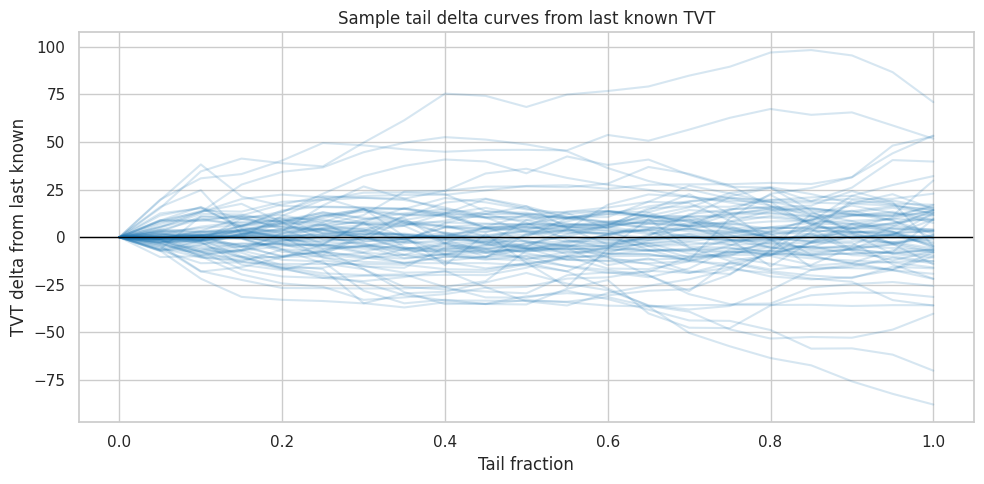

In [15]:
# Convert each tail TVT curve into fixed-fraction knot delta targets.

def make_knot_targets(path: Path, knots=np.linspace(0, 1, 21)) -> dict:
    wid = well_id_from_path(path)
    df = pd.read_csv(path, usecols=['TVT', 'TVT_input'])
    mask = df['TVT_input'].isna().to_numpy()
    pred_idx = np.flatnonzero(mask)
    if len(pred_idx) == 0:
        return {'well_id': wid}
    last_known = float(df['TVT_input'].iloc[pred_idx[0] - 1])
    tail_y = df['TVT'].iloc[pred_idx].to_numpy()
    x = np.linspace(0, 1, len(tail_y))
    knot_delta = np.interp(knots, x, tail_y - last_known)
    row = {'well_id': wid, 'tail_len': len(tail_y), 'last_known_TVT': last_known}
    for k, value in zip(knots, knot_delta):
        row[f'delta_knot_{k:.2f}'] = float(value)
    row['tail_min_delta'] = float(np.min(tail_y - last_known))
    row['tail_max_delta'] = float(np.max(tail_y - last_known))
    row['tail_end_delta'] = float(tail_y[-1] - last_known)
    return row

knot_targets = pd.DataFrame([make_knot_targets(path) for path in train_horizontal_files])
print('knot_targets shape:', knot_targets.shape)
display(knot_targets.head())

selected_knot_cols = ['delta_knot_0.00', 'delta_knot_0.25', 'delta_knot_0.50', 'delta_knot_0.75', 'delta_knot_1.00', 'tail_min_delta', 'tail_max_delta']
display(knot_targets[selected_knot_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in knot_targets.sample(min(80, len(knot_targets)), random_state=42).iterrows():
    values = [row[f'delta_knot_{k:.2f}'] for k in np.linspace(0, 1, 21)]
    ax.plot(np.linspace(0, 1, 21), values, alpha=0.18, color='tab:blue')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Sample tail delta curves from last known TVT')
ax.set_xlabel('Tail fraction')
ax.set_ylabel('TVT delta from last known')
plt.tight_layout()
plt.show()

## 13. Nearby-Well Spatial Signal

### Statistical role

Diagnose whether spatial drift in nearby wells is related to the target well drift.

### Leakage caution

This diagnostic uses target-derived drift only to measure whether spatial proximity has signal. In real CV features, target-derived drift from validation-fold wells must not enter the neighbor reference table.

<details>
<summary>KNN drift diagnostic</summary>

Distance between Prediction Start coordinates:

$$
d(w,u)=\sqrt{(X_{PS,w}-X_{PS,u})^2+(Y_{PS,w}-Y_{PS,u})^2}
$$

K-nearest-neighbor prior:

$$
\widehat{\Delta}^{NN}_w=\frac{1}{K}\sum_{u\in NN_K(w)}\Delta^{\mathrm{end}}_u
$$

</details>


leave-one-out nearest 3 mean vs own tail_end_delta correlation: 0.1183
leave-one-out nearest 5 mean vs own tail_end_delta correlation: 0.1248
leave-one-out nearest 10 mean vs own tail_end_delta correlation: 0.0982
leave-one-out nearest 20 mean vs own tail_end_delta correlation: 0.0563


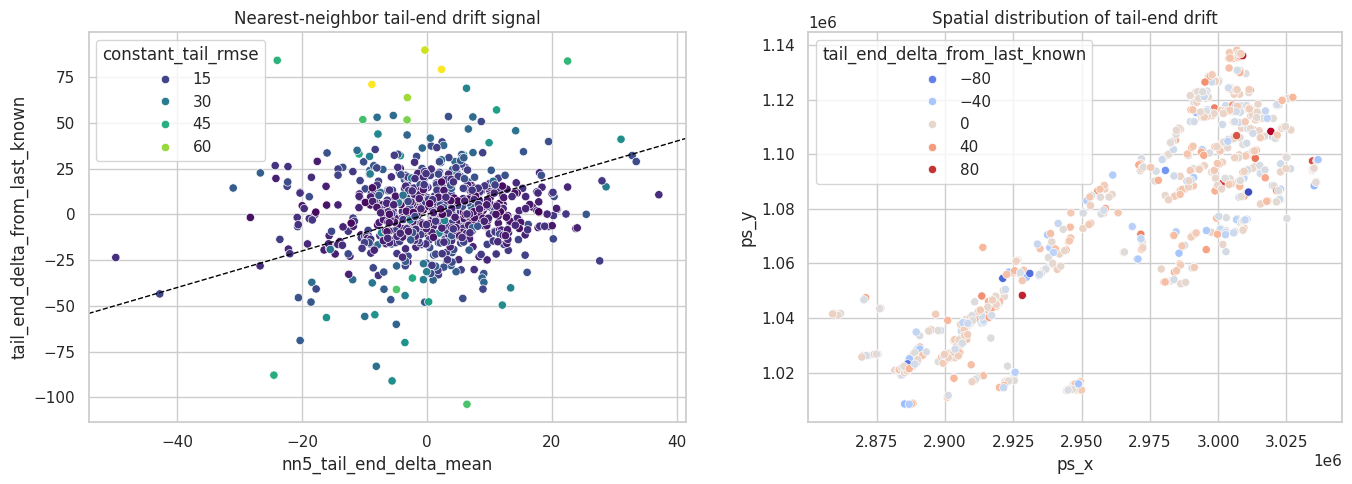

In [16]:
# Estimate leave-one-out nearest-neighbor spatial drift signal.

spatial_frame = h_summary[['well_id', 'ps_x', 'ps_y', 'azimuth_deg', 'tail_end_delta_from_last_known', 'tail_tvt_range', 'constant_tail_rmse']].dropna().reset_index(drop=True)
coords = spatial_frame[['ps_x', 'ps_y']].to_numpy()
# Pairwise distance is small enough: 773 x 773.
dx = coords[:, None, 0] - coords[None, :, 0]
dy = coords[:, None, 1] - coords[None, :, 1]
dist = np.sqrt(dx ** 2 + dy ** 2)
np.fill_diagonal(dist, np.inf)

for k in [3, 5, 10, 20]:
    nn = np.argsort(dist, axis=1)[:, :k]
    neighbor_mean = spatial_frame['tail_end_delta_from_last_known'].to_numpy()[nn].mean(axis=1)
    spatial_frame[f'nn{k}_tail_end_delta_mean'] = neighbor_mean
    corr = np.corrcoef(spatial_frame['tail_end_delta_from_last_known'], neighbor_mean)[0, 1]
    print(f'leave-one-out nearest {k} mean vs own tail_end_delta correlation: {corr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=spatial_frame, x='nn5_tail_end_delta_mean', y='tail_end_delta_from_last_known', hue='constant_tail_rmse', palette='viridis', ax=axes[0])
axes[0].axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Nearest-neighbor tail-end drift signal')
sns.scatterplot(data=spatial_frame, x='ps_x', y='ps_y', hue='tail_end_delta_from_last_known', palette='coolwarm', ax=axes[1], s=35)
axes[1].set_title('Spatial distribution of tail-end drift')
axes[1].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

## 14. Representative Well Plot

### Statistical role

Inspect one well visually to catch curve behavior that aggregate statistics can hide.

### What to inspect

- TVT continuity before and after Prediction Start
- GR missingness locations
- TVT-axis similarity between typewell GR and horizontal known-prefix GR
- Whether the tail is flat, increasing, or decreasing

### Why this matters

Aggregate RMSE can hide specific well-level failure modes. Plots are useful for building a failure taxonomy.


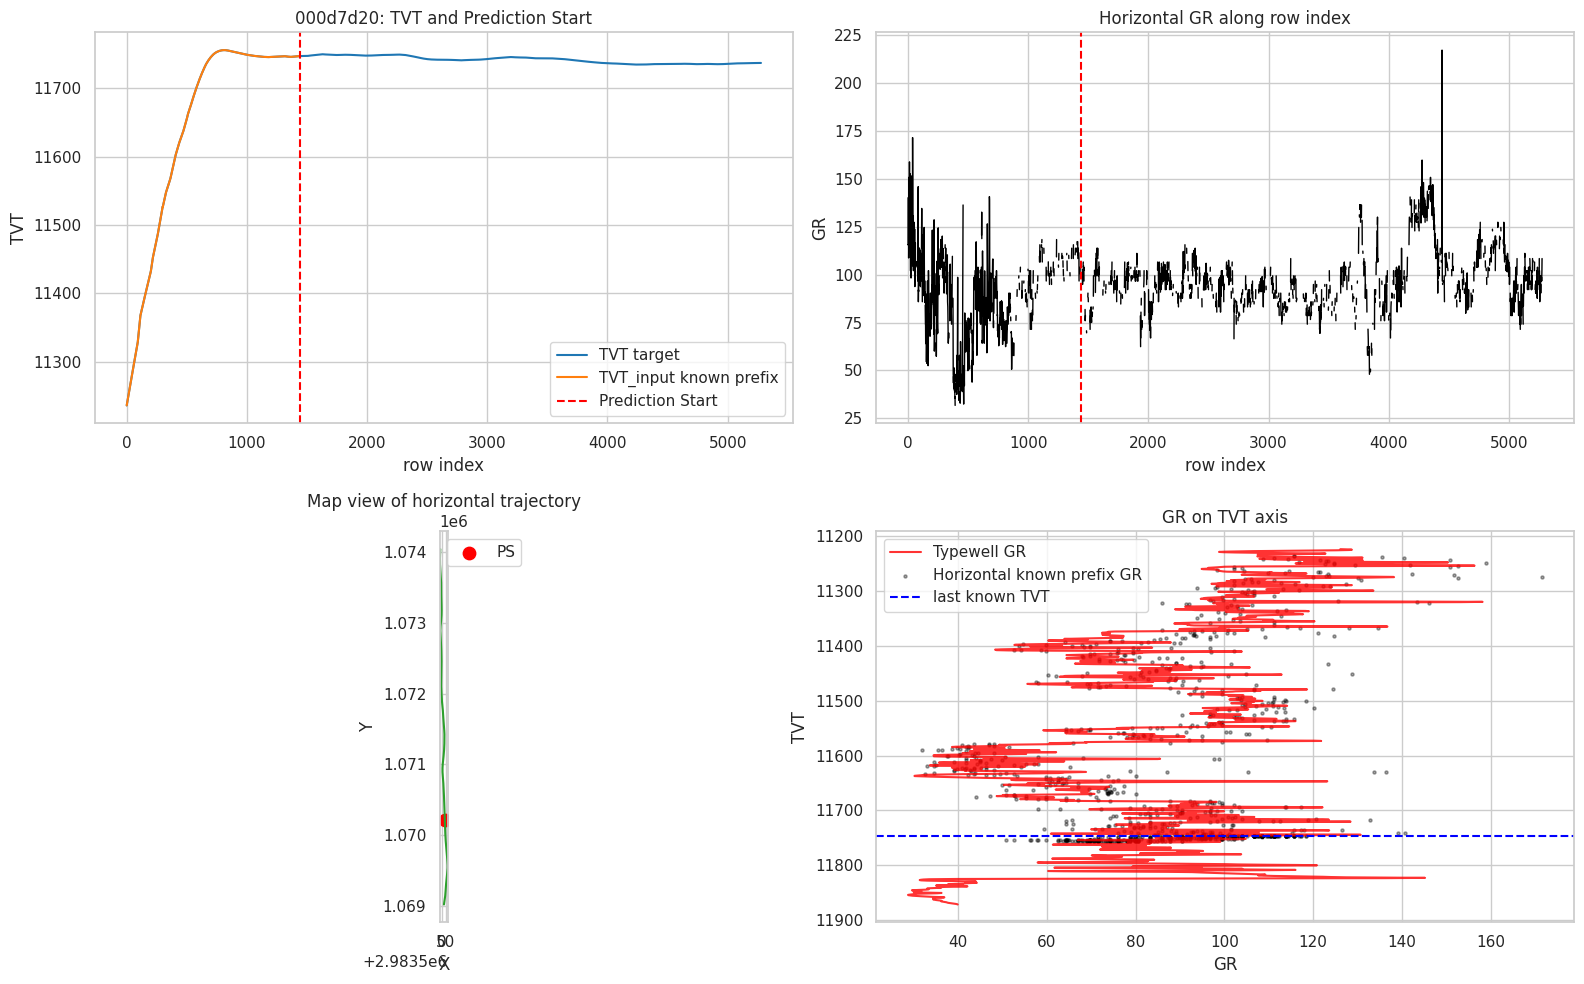

In [17]:
# Plot a representative well across TVT, GR, map trajectory, and typewell-aligned GR axes.

def plot_well_overview(well_id: str):
    h = pd.read_csv(TRAIN_DIR / f'{well_id}__horizontal_well.csv')
    tw = pd.read_csv(TRAIN_DIR / f'{well_id}__typewell.csv')
    mask = h['TVT_input'].isna().to_numpy()
    ps = int(np.flatnonzero(mask)[0]) if mask.any() else len(h)
    last_known_tvt = h['TVT_input'].iloc[ps - 1]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    ax = axes[0, 0]
    ax.plot(h.index, h['TVT'], label='TVT target', color='tab:blue')
    ax.plot(h.index, h['TVT_input'], label='TVT_input known prefix', color='tab:orange')
    ax.axvline(ps, color='red', linestyle='--', label='Prediction Start')
    ax.set_title(f'{well_id}: TVT and Prediction Start')
    ax.set_xlabel('row index')
    ax.set_ylabel('TVT')
    ax.legend()
    
    ax = axes[0, 1]
    ax.plot(h.index, h['GR'], color='black', linewidth=1)
    ax.axvline(ps, color='red', linestyle='--')
    ax.set_title('Horizontal GR along row index')
    ax.set_xlabel('row index')
    ax.set_ylabel('GR')
    
    ax = axes[1, 0]
    ax.plot(h['X'], h['Y'], color='tab:green')
    ax.scatter(h['X'].iloc[ps], h['Y'].iloc[ps], color='red', s=80, label='PS')
    ax.set_title('Map view of horizontal trajectory')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal', adjustable='box')
    ax.legend()
    
    ax = axes[1, 1]
    known = h['TVT_input'].notna() & h['GR'].notna()
    ax.plot(tw['GR'], tw['TVT'], color='red', alpha=0.8, label='Typewell GR')
    ax.scatter(h.loc[known, 'GR'], h.loc[known, 'TVT_input'], s=5, alpha=0.35, color='black', label='Horizontal known prefix GR')
    ax.axhline(last_known_tvt, color='blue', linestyle='--', label='last known TVT')
    ax.invert_yaxis()
    ax.set_title('GR on TVT axis')
    ax.set_xlabel('GR')
    ax.set_ylabel('TVT')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_well_overview(representative_well_id)

## 🧠 15. Model Logic from EDA

### 🧩 Prediction architecture

```text
last_known_TVT anchor
        +
residual model from leakage-checked features
        +
OOF-selected post-processing
        ↓
row-level TVT prediction
```

### 📏 Validation rules

| Rule | Reason |
|---|---|
| `GroupKFold` by `well_id` | estimates unseen-well generalization |
| Evaluate only `TVT_input.isna()` rows | matches the submission target |
| Row-level RMSE | matches the competition metric |
| Row-weighted CV summary | long tails should carry more metric weight |
| Global postprocess selection | avoids fold-specific oracle tuning |

<details>
<summary>Row-weighted CV aggregation</summary>

$$
\mathrm{RMSE}_{CV}
=
\sqrt{\frac{\sum_f n_f\,\mathrm{RMSE}_f^2}{\sum_f n_f}}.
$$

</details>

### 🧬 Signal families

| Signal | Status | Construction |
|---|---:|---|
| Residual target | ✅ | predict `TVT - last_known_TVT`, not raw TVT |
| Typewell GR alignment | ✅ | interpolate reference GR at prefix-derived TVT baselines |
| GR affine calibration | ✅ | prefix-only fit between horizontal GR and typewell GR |
| GR derivative/event features | ✅ | backward differences and trailing ranges |
| Local trajectory steps | ✅ | current and previous survey rows |
| Prefix TVT context | ✅ | prefix-only statistics and slopes |
| Offline tail-position/path features | 🌐 | target-free full-tail covariates |
| Formation-plane/KNN references | 🌐 | train surfaces as auxiliary labels, fold-safe in CV |
| Beam-path alignment | 🧪 | full hidden GR sequence, no future TVT labels |
| Fade-in residual | ✅ | suppresses unsupported early-tail jumps |
| Anchor-aware slope clipping | ✅ | anchor plus previous clipped prediction |
| Centered GR rolling | 🌐 | future GR covariates |
| Direct train-only surfaces | 🚫 | hidden-test feature mismatch |

### 🎯 Statistical objective

| Goal | Practical consequence |
|---|---|
| protect flat wells | shrink residuals and fade in near Prediction Start |
| correct drifting wells | use GR/typewell, trajectory, and formation-plane evidence |
| avoid nonphysical jumps | apply anchor-aware slope limiting when selected |


## 🧮 16. Residual Prediction Model

### 🔁 Residual pipeline

| Stage | Input | Output | Purpose |
|---|---|---|---|
| Anchor | `last_known_TVT` | flat baseline | strong empirical prior |
| Model | feature row | raw residual | learn non-zero drift |
| Residual clip | raw residual | bounded residual | remove extreme model outliers |
| Global alpha | bounded residual | shrunk residual | match OOF residual variance |
| Fade-in | shrunk residual | early-tail guarded residual | keep first tail rows near anchor |
| Slope limiter | TVT curve | clipped TVT curve | suppress implausible jumps |

<details>
<summary>Compact prediction equation</summary>

$$
\hat{y}_{w,i}
=
y_{w,L}
+
\rho_{w,i}(\tau)\,\alpha\,\mathrm{clip}(\widehat{\Delta y}_{w,i}).
$$

The fade-in factor is:

$$
\rho_{w,i}(\tau)
=
1-
\exp\left(-\frac{\max(MD_{w,i}-MD_{w,PS},0)}{\tau}\right).
$$

When no fade-in is selected, $\rho_{w,i}=1$.

</details>

### 🧠 Encoded domain structure

| Feature family | Signal |
|---|---|
| Prefix context | known TVT range, statistics, slopes |
| Typewell alignment | typewell GR at prefix-derived TVT baselines |
| Calibrated typewell | prefix-only affine GR calibration |
| Causal events | backward GR derivatives and trailing GR ranges |
| Trajectory steps | local geometric movement |
| Offline tail covariates | target-free batch-prediction context |
| Formation-plane references | spatial formation-top geometry projected onto hidden rows |

### 🧯 Anchor-aware causal clipping

| Row | Reference value | Constraint |
|---|---|---|
| first tail row | last known prefix TVT | no unsupported jump from anchor |
| later tail rows | previous clipped prediction | smooth row-to-row movement |

The slope bound is estimated from train-fold TVT slope quantiles.


### 16.0 Feature Leakage Review

### Strict policy inputs

| Feature source | Why it is allowed |
|---|---|
| `MD`, `X`, `Y`, `Z`, `GR` at row $i$ | observed at the row |
| Prefix aggregates | known before tail prediction |
| `last_known_TVT` and prefix TVT statistics | known from prefix `TVT_input` |
| Backward GR differences | previous/current rows only |
| Trailing GR rolling features | rows up to $i$ only |
| Typewell GR at prefix-derived baselines | reference log + prefix baseline |
| Prefix-only affine GR calibration | fit only where `TVT_input` is present |
| Anchor-aware slope clipping | anchor, train-fold slope bound, previous clipped prediction |

### Offline policy inputs

| Feature source | Offline reason |
|---|---|
| Tail length and tail fraction | prediction rows are known before writing predictions |
| Full-row fraction and MD tail fraction | test trajectory is provided |
| Gap geometry and full-tail GR summaries | target-free covariates from the provided file |
| Centered GR rolling and lead/lag GR | future GR covariates, not future TVT labels |
| Candidate-path typewell features | tail fraction defines candidate paths, but no true tail TVT is used |
| Spatial formation-plane features | train-only surfaces are auxiliary labels for a reference imputer; validation folds use only training wells |
| Beam-path typewell features | full hidden GR sequence is used; true tail TVT is not used |

### Excluded from all feature policies

| Excluded item | Reason |
|---|---|
| `TVT` in the prediction tail | direct target leakage |
| Train-only surfaces (`ANCC` ... `BUDA`) | hidden-test feature mismatch |
| `TVT_input_bfill` | reads rows after the prediction row |
| Target-derived tail summaries | answer-key information |
| Nearby target drift from validation wells | fold leakage |


In [18]:
# Configure the residual model, feature sets, validation, and causal post-processing.

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Execution controls.
NOTEBOOK_RUN_VERSION = 'ROGII_EDA_v3_light_format_2026_05_09'
# Local research runs keep grouped CV enabled. Kaggle submission runs skip CV by default
# and use the latest stored CV selection before fitting the all-row GPU LightGBM candidate.
QUICK_CHECK_MODE = False
KAGGLE_MEMORY_SAFE_MODE = True
ENABLE_KAGGLE_BEAM_FEATURES = False
RUN_HGB_DIAGNOSTIC_SUBMISSIONS = not KAGGLE_NOTEBOOK_RUN
RUN_GROUPED_CV = not KAGGLE_NOTEBOOK_RUN

MODEL_CONFIG = {
    # Resource-controlled settings for grouped CV and final training.
    'random_state': 42,
    'n_splits': 5,
    'cv_folds_to_run': 5,
    'train_rows_per_well': 350,
    'final_train_rows_per_well': 700,
    'feature_policy_for_selection': 'strict',
    'residual_shrinkage': 0.80,
    'alpha_bounds': (0.0, 1.5),
    'delta_clip_quantiles': (0.005, 0.995),
    'fade_in_tau_md_to_compare': [None, 25.0, 50.0, 100.0, 200.0],
    'slope_clip_quantiles_to_compare': [0.90, 0.95, 0.975, 0.99, 0.995],
    'postprocess_slope_quantile': 0.995,
    'feature_sets_to_compare': None,
    'select_best_feature_set_from_cv': True,
    'apply_slope_clip_if_cv_improves': True,
    'write_submission': True,
    'write_public_clean_submission': True,
}

if QUICK_CHECK_MODE:
    MODEL_CONFIG.update({
        'cv_folds_to_run': 1,
        'train_rows_per_well': 150,
        'final_train_rows_per_well': 150,
        'feature_sets_to_compare': [
            'calibrated_typewell_alignment',
            'offline_candidate_path_alignment',
        ],
    })

BASE_FEATURE_COLUMNS = [
    # Row position and trajectory after Prediction Start.
    'md_since_ps',
    'x_delta_ps',
    'y_delta_ps',
    'z_delta_ps',
    'xy_dist_ps',
    'MD',
    'X',
    'Y',
    'Z',
    # Prefix-only well context.
    'prefix_len',
    'prefix_azimuth_deg',
    'prefix_gr_missing_rate',
    # Row-level GR signal and trailing GR context.
    'GR',
    'GR_isna',
    'GR_prefix_z',
    'gr_diff_1',
    'gr_diff_5',
    'gr_slope_md_1',
    'md_step_1',
    'x_step_1',
    'y_step_1',
    'z_step_1',
    'trajectory_step_1',
    'z_slope_md_1',
    'prefix_gr_mean',
    'prefix_gr_std',
    'gr_roll_mean_25',
    'gr_roll_std_25',
    'gr_roll_min_25',
    'gr_roll_max_25',
    'gr_roll_range_25',
    'gr_roll_mean_100',
    'gr_roll_std_100',
    'gr_roll_range_100',
    'gr_roll_mean_300',
    'gr_roll_std_300',
    'gr_roll_range_300',
    # Known-prefix TVT trend. This can help, but shrinkage/clipping protects against blind extrapolation.
    'prefix_tvt_slope_md_all',
    'prefix_tvt_slope_md_last200',
]

PREFIX_CONTEXT_COLUMNS = [
    'last_known_TVT',
    'prefix_gr_min',
    'prefix_gr_max',
    'prefix_last_valid_gr',
    'rows_since_prefix_last_valid_gr',
    'md_since_prefix_last_valid_gr',
    'gr_minus_prefix_last_valid_gr',
    'gr_minus_prefix_gr_mean',
    'prefix_tvt_min',
    'prefix_tvt_max',
    'prefix_tvt_range',
    'prefix_tvt_mean',
    'prefix_tvt_std',
    'prefix_tvt_step20',
    'prefix_tvt_step100',
    'prefix_tvt_md_slope100',
    'prefix_tvt_z_slope100',
    'slope_baseline_delta_all',
    'slope_baseline_delta_last200',
    'slope_baseline_tvt_all',
    'slope_baseline_tvt_last200',
]

TYPEWELL_INTERVAL_CONTEXT_COLUMNS = (
    typewell_interval_context_feature_names(prefix='typewell_last_geo')
    + typewell_interval_context_feature_names(prefix='typewell_baseline_last200_geo')
)

TYPEWELL_ANCHOR_OFFSET_COLUMNS = [
    f'typewell_anchor_gr_diff_{candidate_endpoint_label(float(offset))}'
    for offset in [-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80]
]

CALIBRATED_TYPEWELL_ANCHOR_OFFSET_COLUMNS = [
    f'calibrated_typewell_anchor_gr_diff_{candidate_endpoint_label(float(offset))}'
    for offset in [-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80]
]

TYPEWELL_ALIGNMENT_COLUMNS = [
    'typewell_tvt_min',
    'typewell_tvt_max',
    'typewell_tvt_range',
    'typewell_gr_mean',
    'typewell_gr_std',
    'typewell_gr_at_last_known_tvt',
    'typewell_gr_at_slope_baseline_all',
    'typewell_gr_at_slope_baseline_last200',
    'gr_minus_typewell_last_known_tvt',
    'gr_minus_typewell_slope_baseline_all',
    'gr_minus_typewell_slope_baseline_last200',
    'prefix_horizontal_vs_typewell_gr_corr',
    'prefix_horizontal_vs_typewell_gr_mae',
    'prefix_horizontal_vs_typewell_gr_rmse',
    *TYPEWELL_INTERVAL_CONTEXT_COLUMNS,
    *TYPEWELL_ANCHOR_OFFSET_COLUMNS,
    'typewell_local_last200_best_delta',
    'typewell_local_last200_best_abs_resid',
    'typewell_local_last200_zero_abs_resid',
    'typewell_local_last200_top2_gap',
    'typewell_local_last200_soft_delta_mean',
    'typewell_local_last200_gr_resid_best',
    'typewell_local_last200_best_vs_zero_gain',
]

CALIBRATED_TYPEWELL_ALIGNMENT_COLUMNS = [
    'prefix_typewell_gr_affine_a',
    'prefix_typewell_gr_affine_b',
    'prefix_horizontal_vs_calibrated_typewell_gr_mae',
    'prefix_horizontal_vs_calibrated_typewell_gr_rmse',
    *CALIBRATED_TYPEWELL_ANCHOR_OFFSET_COLUMNS,
    'typewell_calibrated_gr_at_last_known_tvt',
    'typewell_calibrated_gr_at_slope_baseline_all',
    'typewell_calibrated_gr_at_slope_baseline_last200',
    'gr_minus_calibrated_typewell_last_known_tvt',
    'gr_minus_calibrated_typewell_slope_baseline_all',
    'gr_minus_calibrated_typewell_slope_baseline_last200',
    'calibrated_typewell_slope_last200_gr_prefix_z',
    'calibrated_typewell_local_last200_best_delta',
    'calibrated_typewell_local_last200_best_abs_resid',
    'calibrated_typewell_local_last200_zero_abs_resid',
    'calibrated_typewell_local_last200_top2_gap',
    'calibrated_typewell_local_last200_soft_delta_mean',
    'calibrated_typewell_local_last200_gr_resid_best',
    'calibrated_typewell_local_last200_best_vs_zero_gain',
]

FORMATION_PLANE_COLUMNS = formation_feature_names(include_row=False)
FORMATION_ROW_ANCC_COLUMNS = [
    col
    for col in formation_feature_names(include_row=True)
    if col not in set(FORMATION_PLANE_COLUMNS)
]

# Beam alignment is expensive during repeated local CV. Keep it off locally by default,
# and enable it only for explicit Kaggle all-row experiments.
ENABLE_OFFLINE_BEAM_FEATURES = bool(ENABLE_KAGGLE_BEAM_FEATURES and KAGGLE_NOTEBOOK_RUN and not KAGGLE_MEMORY_SAFE_MODE)
OFFLINE_CANDIDATE_PATH_COLUMNS = candidate_path_feature_names(prefix='tw_path')
OFFLINE_CANDIDATE_PATH_EASE_COLUMNS = candidate_path_feature_names(prefix='tw_path_ease')
OFFLINE_BEAM_FEATURE_COLUMNS = offline_beam_feature_names(prefix='tw_beam')

OFFLINE_EXTRA_FEATURE_COLUMNS = [
    'tail_len',
    'tail_row_number',
    'tail_frac',
    'tail_frac2',
    'tail_frac3',
    'sqrt_tail_frac',
    'log1p_tail_row',
    'sin_tail_frac_pi',
    'sin_tail_frac_2pi',
    'cos_tail_frac_3pi',
    'n_rows',
    'row_frac',
    'md_tail_span',
    'md_tail_frac',
    'tail_gr_missing_rate',
    'gap_md_span',
    'gap_x_delta',
    'gap_y_delta',
    'gap_z_delta',
    'gap_xy_span',
    'gap_z_over_xy',
    'gap_gr_mean',
    'gap_gr_std',
    'gap_gr_min',
    'gap_gr_p05',
    'gap_gr_p25',
    'gap_gr_p50',
    'gap_gr_p75',
    'gap_gr_p95',
    'gap_gr_max',
    'dist_xyz_ps',
    'dx_per_md_since_ps',
    'dy_per_md_since_ps',
    'dz_per_md_since_ps',
    'gr_center_roll_mean_5',
    'gr_center_roll_std_5',
    'gr_center_roll_range_5',
    'gr_center_roll_mean_21',
    'gr_center_roll_std_21',
    'gr_center_roll_range_21',
    'gr_center_grad_1',
    'gr_center_lag1',
    'gr_center_lead1',
    'gr_center_lag5',
    'gr_center_lead5',
    'gr_cumsum_since_ps',
    'gr_center_roll_mean_51',
    'gr_center_roll_std_51',
    'gr_center_roll_range_51',
    'gr_center_roll_mean_151',
    'gr_center_roll_std_151',
    'gr_center_roll_range_151',
    'gr_center_roll_mean_301',
    'gr_center_roll_std_301',
    'gr_center_roll_range_301',
]

STRICT_FEATURE_SETS = {
    'causal_base': BASE_FEATURE_COLUMNS,
    'prefix_context': BASE_FEATURE_COLUMNS + PREFIX_CONTEXT_COLUMNS,
    'typewell_alignment': BASE_FEATURE_COLUMNS + PREFIX_CONTEXT_COLUMNS + TYPEWELL_ALIGNMENT_COLUMNS,
    'calibrated_typewell_alignment': (
        BASE_FEATURE_COLUMNS
        + PREFIX_CONTEXT_COLUMNS
        + TYPEWELL_ALIGNMENT_COLUMNS
        + CALIBRATED_TYPEWELL_ALIGNMENT_COLUMNS
    ),
}

OFFLINE_FEATURE_SETS = {
    'offline_prefix_context': STRICT_FEATURE_SETS['prefix_context'] + OFFLINE_EXTRA_FEATURE_COLUMNS,
    'offline_typewell_alignment': STRICT_FEATURE_SETS['typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS,
    'offline_calibrated_typewell_alignment': STRICT_FEATURE_SETS['calibrated_typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS,
    'offline_candidate_path_alignment': STRICT_FEATURE_SETS['typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS + OFFLINE_CANDIDATE_PATH_COLUMNS + OFFLINE_CANDIDATE_PATH_EASE_COLUMNS,
    'offline_candidate_path_calibrated_alignment': STRICT_FEATURE_SETS['calibrated_typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS + OFFLINE_CANDIDATE_PATH_COLUMNS + OFFLINE_CANDIDATE_PATH_EASE_COLUMNS,
    'offline_formation_plane_alignment': STRICT_FEATURE_SETS['typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS + FORMATION_PLANE_COLUMNS,
    'offline_formation_top_alignment': STRICT_FEATURE_SETS['typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS + FORMATION_PLANE_COLUMNS + FORMATION_ROW_ANCC_COLUMNS,
}
if ENABLE_OFFLINE_BEAM_FEATURES:
    OFFLINE_FEATURE_SETS['offline_beam_candidate_path_alignment'] = (
        STRICT_FEATURE_SETS['typewell_alignment']
        + OFFLINE_EXTRA_FEATURE_COLUMNS
        + OFFLINE_CANDIDATE_PATH_COLUMNS
        + OFFLINE_CANDIDATE_PATH_EASE_COLUMNS
        + OFFLINE_BEAM_FEATURE_COLUMNS
    )

FEATURE_SETS = {**STRICT_FEATURE_SETS, **OFFLINE_FEATURE_SETS}
FEATURE_SET_POLICY = {name: 'strict' for name in STRICT_FEATURE_SETS}
FEATURE_SET_POLICY.update({name: 'offline' for name in OFFLINE_FEATURE_SETS})

DEFAULT_FEATURE_SETS_TO_COMPARE = [
    name
    for name in FEATURE_SETS
    if name not in {
        # Row-level ANCC KNN is useful as a targeted experiment, but it is heavier than the
        # plane-fit formation features and is not needed for the memory-safe submission path.
        'offline_formation_top_alignment',
    }
]
if MODEL_CONFIG['feature_sets_to_compare'] is None:
    MODEL_CONFIG['feature_sets_to_compare'] = DEFAULT_FEATURE_SETS_TO_COMPARE

# Latest full grouped-CV selection saved in this notebook.
# These defaults make submission-only runs reproducible without rerunning CV.
SELECTED_FEATURE_SET = 'calibrated_typewell_alignment'
FEATURE_COLUMNS = FEATURE_SETS[SELECTED_FEATURE_SET]
SELECTED_POLICY_METRIC = 'global_alpha_0.812_fade_200_0_slope_q_0_9'
SELECTED_SHRINKAGE_ALPHA = 0.811832
SELECTED_FADE_IN_TAU_MD = 200.0
SELECTED_SLOPE_QUANTILE = 0.90
APPLY_SELECTED_SLOPE_CLIP = True
BEST_OVERALL_FEATURE_SET = 'offline_candidate_path_alignment'
BEST_OVERALL_SHRINKAGE_ALPHA = 0.941149
BEST_OVERALL_FADE_IN_TAU_MD = 200.0
BEST_OVERALL_SLOPE_QUANTILE = 0.90
APPLY_BEST_OVERALL_SLOPE_CLIP = True

PUBLIC_LGBM_STYLE_COLUMNS = [
    'row_index', 'last_known_TVT', 'prefix_len', 'tail_len', 'tail_row_number', 'tail_frac',
    'n_rows', 'row_frac', 'md_tail_frac', 'md_tail_span',
    'MD', 'Z', 'X', 'Y', 'GR', 'GR_isna',
    'gr_center_roll_mean_5', 'gr_center_roll_mean_21',
    'gr_center_grad_1', 'gr_center_roll_std_5', 'gr_center_roll_std_21',
    'gr_center_lag1', 'gr_center_lead1', 'gr_center_lag5', 'gr_center_lead5', 'gr_cumsum_since_ps',
    'md_since_ps', 'z_delta_ps', 'x_delta_ps', 'y_delta_ps',
    'dx_per_md_since_ps', 'dy_per_md_since_ps', 'dz_per_md_since_ps', 'xy_dist_ps', 'dist_xyz_ps',
    'prefix_tvt_step20', 'prefix_tvt_step100', 'prefix_tvt_md_slope100', 'prefix_tvt_z_slope100',
    'prefix_horizontal_vs_typewell_gr_rmse', 'prefix_horizontal_vs_typewell_gr_mae',
    'typewell_anchor_gr_diff_m80', 'typewell_anchor_gr_diff_m40', 'typewell_anchor_gr_diff_m20',
    'typewell_anchor_gr_diff_m10', 'typewell_anchor_gr_diff_m5', 'typewell_anchor_gr_diff_p0',
    'typewell_anchor_gr_diff_p5', 'typewell_anchor_gr_diff_p10', 'typewell_anchor_gr_diff_p20',
    'typewell_anchor_gr_diff_p40', 'typewell_anchor_gr_diff_p80',
]
PUBLIC_LGBM_ALWAYS_AVAILABLE_COLUMNS = ['row_index']
PUBLIC_LGBM_COMPACT_EXTRA_COLUMNS = [
    'tail_frac2',
    'tail_frac3',
    'sqrt_tail_frac',
    'log1p_tail_row',
    'sin_tail_frac_pi',
    'sin_tail_frac_2pi',
    'cos_tail_frac_3pi',
    'gap_md_span',
    'gap_x_delta',
    'gap_y_delta',
    'gap_z_delta',
    'gap_xy_span',
    'gap_z_over_xy',
    'gap_gr_mean',
    'gap_gr_std',
    'gap_gr_min',
    'gap_gr_p05',
    'gap_gr_p25',
    'gap_gr_p50',
    'gap_gr_p75',
    'gap_gr_p95',
    'gap_gr_max',
    'tail_gr_missing_rate',
    'gr_center_roll_range_5',
    'gr_center_roll_range_21',
    'gr_center_roll_mean_51',
    'gr_center_roll_std_51',
    'gr_center_roll_range_51',
    'gr_center_roll_mean_151',
    'gr_center_roll_std_151',
    'gr_center_roll_range_151',
]
PUBLIC_LGBM_STYLE_COLUMNS = list(dict.fromkeys(PUBLIC_LGBM_STYLE_COLUMNS + PUBLIC_LGBM_COMPACT_EXTRA_COLUMNS))
PUBLIC_LGBM_STYLE_COLUMNS = [
    col
    for col in PUBLIC_LGBM_STYLE_COLUMNS
    if col in FEATURE_SETS['offline_typewell_alignment'] + OFFLINE_EXTRA_FEATURE_COLUMNS + PUBLIC_LGBM_ALWAYS_AVAILABLE_COLUMNS
]
FEATURE_SETS['offline_public_lgbm_style'] = list(dict.fromkeys(PUBLIC_LGBM_STYLE_COLUMNS))
FEATURE_SET_POLICY['offline_public_lgbm_style'] = 'offline'
PUBLIC_LGBM_FORMATION_STYLE_COLUMNS = list(dict.fromkeys(PUBLIC_LGBM_STYLE_COLUMNS + FORMATION_PLANE_COLUMNS))
FEATURE_SETS['offline_public_lgbm_formation_style'] = PUBLIC_LGBM_FORMATION_STYLE_COLUMNS
FEATURE_SET_POLICY['offline_public_lgbm_formation_style'] = 'offline'
PUBLIC_LGBM_FORMATION_TOP_STYLE_COLUMNS = list(dict.fromkeys(
    PUBLIC_LGBM_STYLE_COLUMNS + FORMATION_PLANE_COLUMNS + FORMATION_ROW_ANCC_COLUMNS
))
FEATURE_SETS['offline_public_lgbm_formation_top_style'] = PUBLIC_LGBM_FORMATION_TOP_STYLE_COLUMNS
FEATURE_SET_POLICY['offline_public_lgbm_formation_top_style'] = 'offline'
# The public-style feature set is available for targeted experiments but excluded from default CV
# unless explicitly listed in MODEL_CONFIG['feature_sets_to_compare'].

feature_set_report = pd.DataFrame({
    'feature_set': list(FEATURE_SETS.keys()),
    'feature_policy': [FEATURE_SET_POLICY[name] for name in FEATURE_SETS],
    'feature_count': [len(cols) for cols in FEATURE_SETS.values()],
})
display(feature_set_report)
print('NOTEBOOK_RUN_VERSION:', NOTEBOOK_RUN_VERSION)
print('RUN_GROUPED_CV:', RUN_GROUPED_CV)
print('KAGGLE_MEMORY_SAFE_MODE:', KAGGLE_MEMORY_SAFE_MODE)
print('ENABLE_OFFLINE_BEAM_FEATURES:', ENABLE_OFFLINE_BEAM_FEATURES)
print('RUN_HGB_DIAGNOSTIC_SUBMISSIONS:', RUN_HGB_DIAGNOSTIC_SUBMISSIONS)
print('QUICK_CHECK_MODE:', QUICK_CHECK_MODE)
print('selection_feature_policy:', MODEL_CONFIG['feature_policy_for_selection'])
print('configured_feature_set_before_cv:', SELECTED_FEATURE_SET)



,feature_set,feature_policy,feature_count
0,causal_base,strict,39
1,prefix_context,strict,60
2,typewell_alignment,strict,108
3,calibrated_typewell_alignment,strict,137
4,offline_prefix_context,offline,115
5,offline_typewell_alignment,offline,163
6,offline_calibrated_typewell_alignment,offline,192
7,offline_candidate_path_alignment,offline,263
8,offline_candidate_path_calibrated_alignment,offline,292
9,offline_formation_plane_alignment,offline,223


NOTEBOOK_RUN_VERSION: ROGII_EDA_v3_light_format_2026_05_09
RUN_GROUPED_CV: False
KAGGLE_MEMORY_SAFE_MODE: True
ENABLE_OFFLINE_BEAM_FEATURES: False
RUN_HGB_DIAGNOSTIC_SUBMISSIONS: False
QUICK_CHECK_MODE: False
selection_feature_policy: strict
configured_feature_set_before_cv: calibrated_typewell_alignment


### 16.1 Feature Table Builder

### Sampling rule

If well $w$ has $n_w$ eligible tail rows and the cap is $m$:

$$
S_w \subset \mathcal{T}_w, \quad |S_w|=\min(n_w,m).
$$

| Effect | Statistical consequence |
|---|---|
| Reduces millions of rows | lower computation cost |
| Caps rows per well | loss weighting becomes less dominated by very long wells |
| Sampling inside training fold | no validation-label leakage |

Feature construction must obey the active information policy.

In [19]:
# Build tail feature matrices and define model/post-processing helpers.

def feature_columns_require_beam(feature_columns) -> bool:
    if feature_columns is None:
        return bool(globals().get('ENABLE_OFFLINE_BEAM_FEATURES', False))
    return any(str(col).startswith('tw_beam_') or str(col).startswith('beam_') for col in feature_columns)


def feature_columns_require_formation(feature_columns) -> bool:
    if feature_columns is None:
        return False
    return any(str(col).startswith(('formation_', 'dense_', 'tvt_dense_', 'spatial_vs_')) for col in feature_columns)


def feature_columns_require_row_ancc(feature_columns) -> bool:
    if feature_columns is None:
        return False
    return any(str(col).startswith(('formation_row_', 'formation_formula_', 'dense_', 'tvt_dense_', 'spatial_vs_')) for col in feature_columns)


def compact_tail_feature_frame(
    frame: pd.DataFrame,
    keep_columns=None,
    include_target: bool = True,
    keep_metadata: bool = True,
) -> pd.DataFrame:
    if keep_columns is not None:
        required_columns = []
        if keep_metadata:
            required_columns += [
                'well_id',
                'row_index',
                'id',
                'MD',
                'last_known_TVT',
                'last_known_MD',
                'md_since_ps',
            ]
        if include_target:
            required_columns += ['target_tvt', 'target_delta_from_last_known']
        frame = frame.copy()
        for col in keep_columns:
            if col not in frame.columns:
                frame[col] = np.nan
        wanted = list(dict.fromkeys(required_columns + list(keep_columns)))
        frame = frame[[col for col in wanted if col in frame.columns]]
    else:
        frame = frame.copy()

    for col in frame.columns:
        if pd.api.types.is_float_dtype(frame[col]):
            frame[col] = pd.to_numeric(frame[col], downcast='float')
        elif pd.api.types.is_integer_dtype(frame[col]) and col not in {'row_index'}:
            frame[col] = pd.to_numeric(frame[col], downcast='integer')
    return frame


def build_tail_feature_frame(
    well_ids,
    split_dir: Path,
    include_target: bool,
    rows_per_well: int | None = None,
    random_state: int = 42,
    use_beam_features: bool | None = None,
    keep_columns=None,
    formation_plane_imputer=None,
    row_ancc_imputer=None,
    imputer_well_ids=None,
    keep_metadata: bool = True,
    exclude_query_well_from_formation: bool = True,
) -> pd.DataFrame:
    if use_beam_features is None:
        use_beam_features = bool(globals().get('ENABLE_OFFLINE_BEAM_FEATURES', False))
    need_formation = feature_columns_require_formation(keep_columns)
    need_row_ancc = feature_columns_require_row_ancc(keep_columns)
    if need_formation and formation_plane_imputer is None:
        source_wells = imputer_well_ids if imputer_well_ids is not None else globals().get('all_train_wells', globals().get('train_h_ids', []))
        formation_plane_imputer, maybe_row = make_formation_imputers(
            source_wells,
            TRAIN_DIR,
            need_row_ancc=need_row_ancc and row_ancc_imputer is None,
            seed=random_state,
        )
        if row_ancc_imputer is None:
            row_ancc_imputer = maybe_row
    rng = np.random.default_rng(random_state)
    frames = []
    for well_id in sorted(well_ids):
        frame = make_tail_features_for_well(
            well_id,
            split_dir,
            include_target=include_target,
            use_beam_features=use_beam_features,
            required_feature_columns=keep_columns,
            formation_plane_imputer=formation_plane_imputer,
            row_ancc_imputer=row_ancc_imputer,
            exclude_query_well_from_formation=exclude_query_well_from_formation,
        )
        if frame.empty:
            continue
        if rows_per_well is not None and len(frame) > rows_per_well:
            sampled_idx = np.sort(rng.choice(frame.index.to_numpy(), size=rows_per_well, replace=False))
            frame = frame.loc[sampled_idx]
        frame = compact_tail_feature_frame(
            frame,
            keep_columns=keep_columns,
            include_target=include_target,
            keep_metadata=keep_metadata,
        )
        frames.append(frame)
        gc.collect()
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, copy=False)


def model_ready_xy(frame: pd.DataFrame, feature_columns=None):
    if feature_columns is None:
        feature_columns = FEATURE_COLUMNS
    X = frame[feature_columns].copy()
    y_delta = frame['target_delta_from_last_known'].to_numpy()
    y_tvt = frame['target_tvt'].to_numpy()
    return X, y_delta, y_tvt


def make_residual_model(random_state: int = 42):
    # Fixed-iteration HGB avoids row-random internal early stopping inside a grouped-CV fold.
    return HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.06,
        max_iter=220,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        early_stopping=False,
        random_state=random_state,
    )


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def clip_delta_by_train_quantiles(delta_pred: np.ndarray, train_delta: np.ndarray, config=MODEL_CONFIG) -> np.ndarray:
    lo_q, hi_q = config['delta_clip_quantiles']
    lo, hi = np.nanquantile(train_delta, [lo_q, hi_q])
    return np.clip(delta_pred, lo, hi)


def shrink_delta(delta: np.ndarray, alpha: float | None = None, config=MODEL_CONFIG) -> np.ndarray:
    if alpha is None:
        alpha = config['residual_shrinkage']
    return float(alpha) * np.asarray(delta, dtype=float)


def fade_in_delta(frame: pd.DataFrame, delta: np.ndarray, tau_md: float | None) -> np.ndarray:
    """Dampen residuals close to Prediction Start; tau=None leaves them unchanged."""
    values = np.asarray(delta, dtype=float)
    if tau_md is None or not np.isfinite(tau_md) or tau_md <= 0:
        return values
    md_since = frame['md_since_ps'].to_numpy(dtype=float)
    rho = 1.0 - np.exp(-np.maximum(md_since, 0.0) / float(tau_md))
    return values * rho


def fade_in_tau_label(tau_md: float | None) -> str:
    if tau_md is None or (isinstance(tau_md, float) and not np.isfinite(tau_md)):
        return 'none'
    return str(float(tau_md)).replace('.', '_')


def fit_global_alpha_from_fold_parts(fold_parts, tau_md: float | None, config=MODEL_CONFIG) -> tuple[float, float]:
    """Fit one alpha over all validation folds for a fixed fade-in setting."""
    numerator = 0.0
    denominator = 0.0
    for part in fold_parts:
        frame = part['frame']
        base_delta = fade_in_delta(frame, part['clipped_delta'], tau_md)
        y_delta = frame['target_delta_from_last_known'].to_numpy(dtype=float)
        valid = np.isfinite(base_delta) & np.isfinite(y_delta)
        numerator += float(np.dot(y_delta[valid], base_delta[valid]))
        denominator += float(np.dot(base_delta[valid], base_delta[valid]))
    if denominator <= 1e-12:
        alpha = 0.0
    else:
        alpha = numerator / denominator
    lo, hi = config['alpha_bounds']
    alpha = float(np.clip(alpha, lo, hi))
    score = score_policy_from_fold_parts(fold_parts, alpha=alpha, tau_md=tau_md, slope_quantile=None)['rmse']
    return alpha, score


def score_policy_from_fold_parts(fold_parts, alpha: float, tau_md: float | None, slope_quantile: float | None) -> dict[str, float]:
    sse = 0.0
    n = 0
    for part in fold_parts:
        frame = part['frame']
        delta = shrink_delta(fade_in_delta(frame, part['clipped_delta'], tau_md), alpha=alpha)
        pred = frame['last_known_TVT'].to_numpy(dtype=float) + delta
        if slope_quantile is not None:
            pred = causal_slope_clip_by_well(frame, pred, part['slope_bounds'][float(slope_quantile)])
        y = frame['target_tvt'].to_numpy(dtype=float)
        valid = np.isfinite(y) & np.isfinite(pred)
        err = y[valid] - pred[valid]
        sse += float(np.dot(err, err))
        n += int(valid.sum())
    return {'rmse': float(np.sqrt(sse / n)), 'sse': sse, 'n': n}


def policy_metric_name(alpha: float, tau_md: float | None, slope_quantile: float | None) -> str:
    tau_label = fade_in_tau_label(tau_md)
    if slope_quantile is None:
        slope_label = 'none'
    else:
        slope_label = f'q_{slope_quantile_label(float(slope_quantile))}'
    return f'global_alpha_{alpha:.3f}_fade_{tau_label}_slope_{slope_label}'


def best_alpha_for_clipped_delta(
    last_known_tvt: np.ndarray,
    clipped_delta: np.ndarray,
    y_true: np.ndarray,
    alphas=None,
) -> tuple[float, float]:
    if alphas is None:
        alphas = np.linspace(0.0, 1.5, 61)
    best_score = np.inf
    best_alpha = np.nan
    for alpha in alphas:
        score = rmse(y_true, last_known_tvt + alpha * clipped_delta)
        if score < best_score:
            best_score = score
            best_alpha = float(alpha)
    return best_alpha, float(best_score)


def estimate_abs_tvt_slope_quantiles(paths, quantiles, max_wells=None) -> dict[float, float]:
    slopes = []
    selected_paths = list(paths)[:max_wells] if max_wells is not None else list(paths)
    for path in selected_paths:
        df = pd.read_csv(path, usecols=['MD', 'TVT'])
        md = df['MD'].to_numpy(dtype=float)
        tvt = df['TVT'].to_numpy(dtype=float)
        dmd = np.diff(md)
        dtvt = np.diff(tvt)
        valid = np.isfinite(dmd) & np.isfinite(dtvt) & (np.abs(dmd) > 1e-9)
        if valid.any():
            slopes.append(np.abs(dtvt[valid] / dmd[valid]))
    if not slopes:
        return {float(q): np.nan for q in quantiles}
    values = np.concatenate(slopes)
    return {float(q): float(np.nanquantile(values, q)) for q in quantiles}


def estimate_abs_tvt_slope_quantile(paths, quantile=0.995, max_wells=None) -> float:
    return estimate_abs_tvt_slope_quantiles(paths, [quantile], max_wells=max_wells)[float(quantile)]


def slope_quantile_label(q: float) -> str:
    return str(float(q)).replace('.', '_')


def causal_slope_clip_by_well(frame: pd.DataFrame, pred_tvt: np.ndarray, max_abs_slope: float) -> np.ndarray:
    """Anchor-aware forward slope limiter. It never averages with future rows."""
    clipped = np.asarray(pred_tvt, dtype=float).copy()
    if not np.isfinite(max_abs_slope) or max_abs_slope <= 0:
        return clipped
    required = ['well_id', 'row_index', 'MD', 'last_known_TVT', 'last_known_MD']
    frame_ordered = frame[required].copy()
    frame_ordered['_pos'] = np.arange(len(frame_ordered))
    for _, g in frame_ordered.sort_values(['well_id', 'row_index']).groupby('well_id', sort=False):
        pos = g['_pos'].to_numpy(dtype=int)
        md = g['MD'].to_numpy(dtype=float)
        prev_tvt = float(g['last_known_TVT'].iloc[0])
        prev_md = float(g['last_known_MD'].iloc[0])
        for k in range(len(pos)):
            step_md = abs(md[k] - prev_md)
            limit = max_abs_slope * max(step_md, 1e-6)
            clipped[pos[k]] = np.clip(clipped[pos[k]], prev_tvt - limit, prev_tvt + limit)
            prev_tvt = clipped[pos[k]]
            prev_md = md[k]
    return clipped


MAX_ABS_TVT_SLOPE_BY_QUANTILE = estimate_abs_tvt_slope_quantiles(
    train_horizontal_files,
    quantiles=MODEL_CONFIG['slope_clip_quantiles_to_compare'],
)
MAX_ABS_TVT_SLOPE = MAX_ABS_TVT_SLOPE_BY_QUANTILE[float(MODEL_CONFIG['postprocess_slope_quantile'])]
print('feature builder configured')
print('final_train_max_abs_tvt_slope_by_quantile:', MAX_ABS_TVT_SLOPE_BY_QUANTILE)


feature builder configured
final_train_max_abs_tvt_slope_by_quantile: {0.9: 0.5799999999999272, 0.95: 0.9099999999998545, 0.975: 1.0, 0.99: 1.069999999999709, 0.995: 1.180000000000291}


### 16.2 GroupKFold Validation

### Fold metric

Validation is evaluated on full prediction tails from held-out wells. Fold summaries are row-weighted because the competition metric is row-level RMSE and long tails contribute more rows.

<details>
<summary>Fold RMSE</summary>

$$
\mathrm{RMSE}^{(k)}
=
\sqrt{
\frac{1}{N_k}
\sum_{w\in\mathcal{W}^{(k)}_{valid}}
\sum_{i\in\mathcal{T}_w}
(y_{w,i}-\hat{y}_{w,i})^2
}.
$$

</details>

### Prediction variants

| Variant | Purpose |
|---|---|
| Raw | checks the residual model before post-processing |
| Delta-clipped | removes extreme residual outliers |
| Global-shrunk | fits one alpha across all OOF rows for a feature set |
| Fade-in | suppresses early-tail residuals near Prediction Start |
| Slope-limited | applies anchor-aware causal clipping after shrinkage and fade-in |

### Selection rule

A single post-processing policy is selected per feature set using all OOF rows. This avoids choosing a different oracle alpha inside each fold.

### CV caution

`GroupKFold` balances well ids, not geology, geography, tail length, or GR missingness. Those variables remain useful for fold-difficulty diagnostics.


In [20]:
# Run well-level GroupKFold validation and choose one global post-processing policy per feature set.

all_train_wells = np.array(sorted(train_h_ids))
gkf = GroupKFold(n_splits=MODEL_CONFIG['n_splits'])
fold_splits = list(gkf.split(all_train_wells, groups=all_train_wells))[:MODEL_CONFIG['cv_folds_to_run']]
slope_quantiles = [float(q) for q in MODEL_CONFIG['slope_clip_quantiles_to_compare']]
tau_candidates = MODEL_CONFIG['fade_in_tau_md_to_compare']
feature_names_to_compare = list(MODEL_CONFIG['feature_sets_to_compare'])
cv_required_feature_columns = list(dict.fromkeys(
    col
    for name in feature_names_to_compare
    if name in FEATURE_SETS
    for col in FEATURE_SETS[name]
))
cv_requires_beam_features = any(
    feature_columns_require_beam(FEATURE_SETS[name])
    for name in feature_names_to_compare
    if name in FEATURE_SETS
)
cv_requires_formation_features = feature_columns_require_formation(cv_required_feature_columns)
cv_requires_row_ancc_features = feature_columns_require_row_ancc(cv_required_feature_columns)

if not RUN_GROUPED_CV:
    cv_report = pd.DataFrame()
    policy_grid = pd.DataFrame()
    fold_overview = pd.DataFrame()
    feature_fold_parts = {}
    cv_summary = pd.DataFrame([
        {
            'feature_set': SELECTED_FEATURE_SET,
            'feature_policy': FEATURE_SET_POLICY[SELECTED_FEATURE_SET],
            'feature_count': len(FEATURE_SETS[SELECTED_FEATURE_SET]),
            'row_weighted_policy_rmse': np.nan,
            'selected_policy_metric': SELECTED_POLICY_METRIC,
            'policy_alpha': SELECTED_SHRINKAGE_ALPHA,
            'policy_fade_tau_md': SELECTED_FADE_IN_TAU_MD,
            'policy_slope_quantile': SELECTED_SLOPE_QUANTILE,
            'policy_apply_slope_clip': APPLY_SELECTED_SLOPE_CLIP,
        },
        {
            'feature_set': BEST_OVERALL_FEATURE_SET,
            'feature_policy': FEATURE_SET_POLICY[BEST_OVERALL_FEATURE_SET],
            'feature_count': len(FEATURE_SETS[BEST_OVERALL_FEATURE_SET]),
            'row_weighted_policy_rmse': np.nan,
            'selected_policy_metric': 'stored_best_overall',
            'policy_alpha': BEST_OVERALL_SHRINKAGE_ALPHA,
            'policy_fade_tau_md': BEST_OVERALL_FADE_IN_TAU_MD,
            'policy_slope_quantile': BEST_OVERALL_SLOPE_QUANTILE,
            'policy_apply_slope_clip': APPLY_BEST_OVERALL_SLOPE_CLIP,
        },
    ])
    print('Grouped CV skipped. Using stored CV selections from the latest full validation run.')
    display(cv_summary)
else:
    cv_rows = []
    policy_rows = []
    fold_overview_rows = []
    feature_fold_parts = {name: [] for name in feature_names_to_compare}

    for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
        train_wells = all_train_wells[tr_idx]
        valid_wells = all_train_wells[va_idx]
        fold_train_paths = [TRAIN_DIR / f'{well_id}__horizontal_well.csv' for well_id in train_wells]
        fold_slope_bounds = estimate_abs_tvt_slope_quantiles(
            fold_train_paths,
            quantiles=slope_quantiles,
        )
        configured_fold_slope = fold_slope_bounds[float(MODEL_CONFIG['postprocess_slope_quantile'])]
        fold_plane_imputer = fold_row_imputer = None
        if cv_requires_formation_features:
            fold_plane_imputer, fold_row_imputer = make_formation_imputers(
                train_wells,
                TRAIN_DIR,
                need_row_ancc=cv_requires_row_ancc_features,
                seed=MODEL_CONFIG['random_state'] + fold,
            )
    
        train_frame = build_tail_feature_frame(
            train_wells,
            TRAIN_DIR,
            include_target=True,
            rows_per_well=MODEL_CONFIG['train_rows_per_well'],
            random_state=MODEL_CONFIG['random_state'] + fold,
            use_beam_features=cv_requires_beam_features,
            keep_columns=cv_required_feature_columns,
            formation_plane_imputer=fold_plane_imputer,
            row_ancc_imputer=fold_row_imputer,
            imputer_well_ids=train_wells,
        )
        valid_frame = build_tail_feature_frame(
            valid_wells,
            TRAIN_DIR,
            include_target=True,
            rows_per_well=None,
            random_state=MODEL_CONFIG['random_state'] + 1000 + fold,
            use_beam_features=cv_requires_beam_features,
            keep_columns=cv_required_feature_columns,
            formation_plane_imputer=fold_plane_imputer,
            row_ancc_imputer=fold_row_imputer,
            imputer_well_ids=train_wells,
        )
        last_known_valid = valid_frame['last_known_TVT'].to_numpy(dtype=float)
        y_valid_tvt = valid_frame['target_tvt'].to_numpy(dtype=float)
        y_valid_delta = valid_frame['target_delta_from_last_known'].to_numpy(dtype=float)
        fold_baseline_rmse = rmse(y_valid_tvt, last_known_valid)
    
        fold_overview_rows.append({
            'fold': fold,
            'valid_wells': len(valid_wells),
            'valid_rows': len(valid_frame),
            'constant_baseline_rmse': fold_baseline_rmse,
        })
        compact_valid = valid_frame[[
            'well_id',
            'row_index',
            'MD',
            'last_known_MD',
            'last_known_TVT',
            'target_tvt',
            'target_delta_from_last_known',
            'md_since_ps',
            'tail_row_number',
        ]].copy()
    
        for feature_set_name in feature_names_to_compare:
            feature_columns = FEATURE_SETS[feature_set_name]
            X_train, y_train_delta, _ = model_ready_xy(train_frame, feature_columns)
            X_valid, _, _ = model_ready_xy(valid_frame, feature_columns)
            model = make_residual_model(random_state=MODEL_CONFIG['random_state'] + fold)
            model.fit(X_train, y_train_delta)
            raw_delta = model.predict(X_valid)
            clipped_delta = clip_delta_by_train_quantiles(raw_delta, y_train_delta)
            fixed_shrunk_delta = shrink_delta(clipped_delta)
            pred_raw = last_known_valid + raw_delta
            pred_clipped = last_known_valid + clipped_delta
            pred_fixed_shrunk = last_known_valid + fixed_shrunk_delta
            fold_best_alpha, fold_best_alpha_rmse = best_alpha_for_clipped_delta(last_known_valid, clipped_delta, y_valid_tvt)
            pred_configured_slope = causal_slope_clip_by_well(valid_frame, pred_fixed_shrunk, configured_fold_slope)
        
            cv_rows.append({
                'fold': fold,
                'feature_set': feature_set_name,
                'feature_policy': FEATURE_SET_POLICY[feature_set_name],
                'feature_count': len(feature_columns),
                'train_wells': len(train_wells),
                'valid_wells': len(valid_wells),
                'train_rows_sampled': len(train_frame),
                'valid_rows_full': len(valid_frame),
                'configured_fold_max_abs_tvt_slope': configured_fold_slope,
                'baseline_constant_rmse': fold_baseline_rmse,
                'rmse_raw_model': rmse(y_valid_tvt, pred_raw),
                'rmse_delta_clipped': rmse(y_valid_tvt, pred_clipped),
                'rmse_fixed_shrunk_delta': rmse(y_valid_tvt, pred_fixed_shrunk),
                'rmse_anchor_slope_limited': rmse(y_valid_tvt, pred_configured_slope),
                'fixed_shrinkage_alpha': MODEL_CONFIG['residual_shrinkage'],
                'fold_oracle_alpha_from_delta_clip': fold_best_alpha,
                'rmse_fold_oracle_alpha_delta_clip': fold_best_alpha_rmse,
                'delta_target_std_valid': float(np.nanstd(y_valid_delta)),
                'delta_pred_std_raw': float(np.nanstd(raw_delta)),
                'delta_pred_std_clipped': float(np.nanstd(clipped_delta)),
                'delta_pred_std_fixed_shrunk': float(np.nanstd(fixed_shrunk_delta)),
            })
            feature_fold_parts[feature_set_name].append({
                'fold': fold,
                'frame': compact_valid,
                'clipped_delta': clipped_delta,
                'slope_bounds': fold_slope_bounds,
            })

    for feature_set_name in feature_names_to_compare:
        feature_columns = FEATURE_SETS[feature_set_name]
        fold_parts = feature_fold_parts[feature_set_name]
        fade_candidates = []
        for tau_md in tau_candidates:
            alpha, no_slope_rmse = fit_global_alpha_from_fold_parts(fold_parts, tau_md=tau_md)
            fade_candidates.append({
                'tau_md': tau_md,
                'alpha': alpha,
                'no_slope_rmse': no_slope_rmse,
            })
        best_fade = min(fade_candidates, key=lambda row: row['no_slope_rmse'])
    
        slope_options = [None] + slope_quantiles
        for slope_q in slope_options:
            score = score_policy_from_fold_parts(
                fold_parts,
                alpha=best_fade['alpha'],
                tau_md=best_fade['tau_md'],
                slope_quantile=slope_q,
            )
            policy_rows.append({
                'feature_set': feature_set_name,
                'feature_policy': FEATURE_SET_POLICY[feature_set_name],
                'feature_count': len(feature_columns),
                'policy_metric': policy_metric_name(best_fade['alpha'], best_fade['tau_md'], slope_q),
                'policy_alpha': best_fade['alpha'],
                'policy_fade_tau_md': best_fade['tau_md'],
                'policy_slope_quantile': slope_q,
                'policy_apply_slope_clip': slope_q is not None,
                'policy_rmse': score['rmse'],
                'policy_rows': score['n'],
                'global_alpha_no_slope_rmse': best_fade['no_slope_rmse'],
            })

    cv_report = pd.DataFrame(cv_rows)
    policy_grid = pd.DataFrame(policy_rows)
    fold_overview = pd.DataFrame(fold_overview_rows)

    if len(cv_report) and len(policy_grid):
        print('CV folds evaluated:', cv_report['fold'].nunique())
        print('Feature sets compared:', cv_report['feature_set'].nunique())
        print('Postprocess policies compared:', len(policy_grid))
    
        agg_spec = {
            'feature_policy': ('feature_policy', 'first'),
            'feature_count': ('feature_count', 'first'),
            'mean_baseline_rmse': ('baseline_constant_rmse', 'mean'),
            'mean_rmse_raw_model': ('rmse_raw_model', 'mean'),
            'mean_rmse_delta_clipped': ('rmse_delta_clipped', 'mean'),
            'mean_rmse_fixed_shrunk_delta': ('rmse_fixed_shrunk_delta', 'mean'),
            'mean_rmse_anchor_slope_limited': ('rmse_anchor_slope_limited', 'mean'),
            'mean_fold_oracle_alpha': ('fold_oracle_alpha_from_delta_clip', 'mean'),
            'mean_rmse_fold_oracle_alpha': ('rmse_fold_oracle_alpha_delta_clip', 'mean'),
            'std_rmse_fixed_shrunk_delta': ('rmse_fixed_shrunk_delta', 'std'),
            'std_rmse_anchor_slope_limited': ('rmse_anchor_slope_limited', 'std'),
        }
        cv_summary = cv_report.groupby('feature_set', as_index=False).agg(**agg_spec)
    
        row_weighted_metric_columns = [
            'baseline_constant_rmse',
            'rmse_raw_model',
            'rmse_delta_clipped',
            'rmse_fixed_shrunk_delta',
            'rmse_anchor_slope_limited',
            'rmse_fold_oracle_alpha_delta_clip',
        ]
        weighted_rows = []
        for feature_set_name, g in cv_report.groupby('feature_set'):
            weights = g['valid_rows_full'].to_numpy(dtype=float)
            row = {'feature_set': feature_set_name}
            for metric_col in row_weighted_metric_columns:
                values = g[metric_col].to_numpy(dtype=float)
                row[f'row_weighted_{metric_col}'] = float(np.sqrt(np.sum(weights * values ** 2) / np.sum(weights)))
            weighted_rows.append(row)
        cv_summary = cv_summary.merge(pd.DataFrame(weighted_rows), on='feature_set', how='left')
    
        best_policy_by_feature = (
            policy_grid.sort_values('policy_rmse')
            .drop_duplicates('feature_set')
            .rename(columns={
                'policy_rmse': 'row_weighted_policy_rmse',
                'policy_metric': 'selected_policy_metric',
            })
        )
        cv_summary = cv_summary.merge(
            best_policy_by_feature[[
                'feature_set',
                'selected_policy_metric',
                'policy_alpha',
                'policy_fade_tau_md',
                'policy_slope_quantile',
                'policy_apply_slope_clip',
                'row_weighted_policy_rmse',
                'global_alpha_no_slope_rmse',
            ]],
            on='feature_set',
            how='left',
        )
        cv_summary['row_weighted_policy_improvement'] = (
            cv_summary['row_weighted_baseline_constant_rmse'] - cv_summary['row_weighted_policy_rmse']
        )
        cv_summary = cv_summary.sort_values(['feature_policy', 'row_weighted_policy_rmse'])
    
        display(fold_overview.style.format({
            'valid_rows': '{:,.0f}',
            'constant_baseline_rmse': '{:.4f}',
        }))
    
        cv_summary_display = cv_summary[[
            'feature_set',
            'feature_policy',
            'feature_count',
            'row_weighted_baseline_constant_rmse',
            'row_weighted_rmse_raw_model',
            'global_alpha_no_slope_rmse',
            'row_weighted_policy_rmse',
            'policy_alpha',
            'policy_fade_tau_md',
            'policy_slope_quantile',
            'selected_policy_metric',
        ]].rename(columns={
            'row_weighted_baseline_constant_rmse': 'baseline_rmse',
            'row_weighted_rmse_raw_model': 'raw_rmse',
            'global_alpha_no_slope_rmse': 'global_alpha_rmse',
            'row_weighted_policy_rmse': 'policy_rmse',
            'policy_alpha': 'alpha',
            'policy_fade_tau_md': 'fade_tau_md',
            'policy_slope_quantile': 'slope_q',
        })
        display(cv_summary_display.style.format({
            'baseline_rmse': '{:.4f}',
            'raw_rmse': '{:.4f}',
            'global_alpha_rmse': '{:.4f}',
            'policy_rmse': '{:.4f}',
            'alpha': '{:.3f}',
            'fade_tau_md': lambda x: 'none' if pd.isna(x) else f'{x:.0f}',
            'slope_q': lambda x: 'none' if pd.isna(x) else f'{x:.3f}',
        }))
    
        best_overall = cv_summary.sort_values('row_weighted_policy_rmse').iloc[0]
        BEST_OVERALL_FEATURE_SET = str(best_overall['feature_set'])
        BEST_OVERALL_SHRINKAGE_ALPHA = float(best_overall['policy_alpha'])
        BEST_OVERALL_FADE_IN_TAU_MD = None if pd.isna(best_overall['policy_fade_tau_md']) else float(best_overall['policy_fade_tau_md'])
        BEST_OVERALL_SLOPE_QUANTILE = None if pd.isna(best_overall['policy_slope_quantile']) else float(best_overall['policy_slope_quantile'])
        APPLY_BEST_OVERALL_SLOPE_CLIP = bool(best_overall['policy_apply_slope_clip'])
    
        if MODEL_CONFIG['select_best_feature_set_from_cv']:
            selection_policy = MODEL_CONFIG['feature_policy_for_selection']
            selection_summary = cv_summary[cv_summary['feature_policy'].eq(selection_policy)].copy()
            if selection_summary.empty:
                raise ValueError(f'No feature sets available for selection policy: {selection_policy}')
            selected = selection_summary.sort_values('row_weighted_policy_rmse').iloc[0]
            SELECTED_FEATURE_SET = str(selected['feature_set'])
            FEATURE_COLUMNS = FEATURE_SETS[SELECTED_FEATURE_SET]
            SELECTED_POLICY_METRIC = str(selected['selected_policy_metric'])
            SELECTED_SHRINKAGE_ALPHA = float(selected['policy_alpha'])
            SELECTED_FADE_IN_TAU_MD = None if pd.isna(selected['policy_fade_tau_md']) else float(selected['policy_fade_tau_md'])
            SELECTED_SLOPE_QUANTILE = None if pd.isna(selected['policy_slope_quantile']) else float(selected['policy_slope_quantile'])
            APPLY_SELECTED_SLOPE_CLIP = bool(selected['policy_apply_slope_clip'])
            selected_summary = pd.Series({
                'selection_policy': selection_policy,
                'selected_feature_set': SELECTED_FEATURE_SET,
                'selected_feature_count': len(FEATURE_COLUMNS),
                'selected_policy_metric': SELECTED_POLICY_METRIC,
                'selected_shrinkage_alpha': SELECTED_SHRINKAGE_ALPHA,
                'selected_fade_in_tau_md': SELECTED_FADE_IN_TAU_MD,
                'selected_slope_quantile': SELECTED_SLOPE_QUANTILE,
                'apply_slope_clip': APPLY_SELECTED_SLOPE_CLIP,
                'selected_policy_rmse': float(selected['row_weighted_policy_rmse']),
                'best_overall_feature_set': BEST_OVERALL_FEATURE_SET,
                'best_overall_policy': best_overall['feature_policy'],
                'best_overall_policy_rmse': float(best_overall['row_weighted_policy_rmse']),
            })
            display(selected_summary.to_frame('value'))
        
        artifact_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else DATA_DIR
        cv_report.to_csv(artifact_dir / 'v2_cv_report.csv', index=False)
        policy_grid.to_csv(artifact_dir / 'v2_policy_grid.csv', index=False)
        cv_summary.to_csv(artifact_dir / 'v2_cv_summary.csv', index=False)
        fold_overview.to_csv(artifact_dir / 'v2_cv_fold_overview.csv', index=False)
        print('CV artifacts written to:', artifact_dir)


Grouped CV skipped. Using stored CV selections from the latest full validation run.


,feature_set,feature_policy,feature_count,row_weighted_policy_rmse,selected_policy_metric,policy_alpha,policy_fade_tau_md,policy_slope_quantile,policy_apply_slope_clip
0,calibrated_typewell_alignment,strict,137,NaN,global_alpha_0.812_fade_200_0_slope_q_0_9,0.811832,200.0,0.9,True
1,offline_candidate_path_alignment,offline,263,NaN,stored_best_overall,0.941149,200.0,0.9,True


### 16.2.1 Selected Policy Diagnostics

The selected policy should improve row-level RMSE without damaging wells that are already well explained by the flat anchor. This diagnostic checks three questions:

| Diagnostic | Question |
|---|---|
| Post-processing stages | Which step reduces RMSE: clipping, shrinkage, fade-in, or slope limiting? |
| Tail-position bins | Does the model help immediately after Prediction Start and farther into the tail? |
| Well-level gain | Does the model improve many wells, or only a few drifting wells while hurting flat wells? |

These diagnostics use OOF predictions from grouped validation only. They are not computed on the test labels.


In [21]:
if not RUN_GROUPED_CV:
    selected_policy_stage_report = pd.DataFrame()
    selected_policy_tail_md_diagnostics = pd.DataFrame()
    selected_policy_tail_row_diagnostics = pd.DataFrame()
    selected_policy_well_gain = pd.DataFrame()
    print('OOF diagnostics skipped because grouped CV was skipped. Run with RUN_GROUPED_CV=True to refresh diagnostics.')
else:
    # Diagnose the selected OOF policy by stage, tail position, and well-level gain.

    required_diagnostic_vars = [
        'feature_fold_parts',
        'SELECTED_FEATURE_SET',
        'SELECTED_SHRINKAGE_ALPHA',
        'SELECTED_FADE_IN_TAU_MD',
        'SELECTED_SLOPE_QUANTILE',
        'APPLY_SELECTED_SLOPE_CLIP',
    ]
    missing_diagnostic_vars = [name for name in required_diagnostic_vars if name not in globals()]
    if missing_diagnostic_vars:
        raise RuntimeError(f'Selected-policy diagnostic variables are missing: {missing_diagnostic_vars}. Run the validation cell first.')

    if SELECTED_FEATURE_SET not in feature_fold_parts:
        raise KeyError(f'Selected feature set is not available in OOF fold parts: {SELECTED_FEATURE_SET}')

    selected_fold_parts = feature_fold_parts[SELECTED_FEATURE_SET]
    stage_sse = {
        'constant_anchor': 0.0,
        'delta_clipped': 0.0,
        'global_alpha': 0.0,
        'fade_in': 0.0,
        'selected_policy': 0.0,
    }
    stage_n = {name: 0 for name in stage_sse}
    tail_md_bin_rows = []
    tail_row_bin_rows = []
    well_gain_rows = []

    md_bins = [0, 10, 50, 100, 250, 500, 1000, 2000, 5000, np.inf]
    row_bins = [-0.5, 0.5, 4.5, 9.5, 24.5, 49.5, 99.5, 249.5, 499.5, 999.5, np.inf]
    row_labels = ['0', '1-4', '5-9', '10-24', '25-49', '50-99', '100-249', '250-499', '500-999', '1000+']

    for part in selected_fold_parts:
        frame = part['frame']
        y = frame['target_tvt'].to_numpy(dtype=float)
        anchor = frame['last_known_TVT'].to_numpy(dtype=float)
        clipped_delta = np.asarray(part['clipped_delta'], dtype=float)
        pred_delta_clipped = anchor + clipped_delta
        pred_global_alpha = anchor + shrink_delta(clipped_delta, alpha=SELECTED_SHRINKAGE_ALPHA)
        faded_delta = shrink_delta(
            fade_in_delta(frame, clipped_delta, SELECTED_FADE_IN_TAU_MD),
            alpha=SELECTED_SHRINKAGE_ALPHA,
        )
        pred_fade_in = anchor + faded_delta
        pred_selected = pred_fade_in.copy()
        if APPLY_SELECTED_SLOPE_CLIP and SELECTED_SLOPE_QUANTILE is not None:
            slope_bound = part['slope_bounds'][float(SELECTED_SLOPE_QUANTILE)]
            pred_selected = causal_slope_clip_by_well(frame, pred_selected, slope_bound)
        stage_predictions = {
            'constant_anchor': anchor,
            'delta_clipped': pred_delta_clipped,
            'global_alpha': pred_global_alpha,
            'fade_in': pred_fade_in,
            'selected_policy': pred_selected,
        }
        for stage_name, pred in stage_predictions.items():
            valid = np.isfinite(y) & np.isfinite(pred)
            err = y[valid] - pred[valid]
            stage_sse[stage_name] += float(np.dot(err, err))
            stage_n[stage_name] += int(valid.sum())
        diag = pd.DataFrame({
            'well_id': frame['well_id'].to_numpy(),
            'md_since_ps': frame['md_since_ps'].to_numpy(dtype=float),
            'tail_row_number': frame['tail_row_number'].to_numpy(dtype=float),
            'target_delta': frame['target_delta_from_last_known'].to_numpy(dtype=float),
            'constant_error_sq': (y - anchor) ** 2,
            'selected_error_sq': (y - pred_selected) ** 2,
        })
        diag['md_bin'] = pd.cut(diag['md_since_ps'], bins=md_bins, include_lowest=True)
        md_group = diag.groupby('md_bin', observed=False).agg(
            rows=('selected_error_sq', 'size'),
            constant_sse=('constant_error_sq', 'sum'),
            selected_sse=('selected_error_sq', 'sum'),
            target_delta_std=('target_delta', 'std'),
        ).reset_index()
        tail_md_bin_rows.append(md_group)
        diag['tail_row_bin'] = pd.cut(
            diag['tail_row_number'],
            bins=row_bins,
            labels=row_labels,
            include_lowest=True,
        )
        row_group = diag.groupby('tail_row_bin', observed=False).agg(
            rows=('selected_error_sq', 'size'),
            constant_sse=('constant_error_sq', 'sum'),
            selected_sse=('selected_error_sq', 'sum'),
            target_delta_std=('target_delta', 'std'),
        ).reset_index()
        tail_row_bin_rows.append(row_group)
        well_group = diag.groupby('well_id', as_index=False).agg(
            rows=('selected_error_sq', 'size'),
            constant_sse=('constant_error_sq', 'sum'),
            selected_sse=('selected_error_sq', 'sum'),
            target_delta_min=('target_delta', 'min'),
            target_delta_max=('target_delta', 'max'),
            target_delta_std=('target_delta', 'std'),
            max_md_since_ps=('md_since_ps', 'max'),
        )
        well_gain_rows.append(well_group)

    selected_policy_stage_report = pd.DataFrame([
        {
            'stage': stage_name,
            'rows': stage_n[stage_name],
            'rmse': float(np.sqrt(stage_sse[stage_name] / stage_n[stage_name])),
        }
        for stage_name in stage_sse
    ])
    constant_rmse = float(selected_policy_stage_report.loc[
        selected_policy_stage_report['stage'].eq('constant_anchor'),
        'rmse',
    ].iloc[0])
    selected_policy_stage_report['gain_vs_constant'] = constant_rmse - selected_policy_stage_report['rmse']


    def combine_bin_diagnostics(rows, bin_col):
        out = pd.concat(rows, ignore_index=True).groupby(bin_col, observed=False).agg(
            rows=('rows', 'sum'),
            constant_sse=('constant_sse', 'sum'),
            selected_sse=('selected_sse', 'sum'),
            target_delta_std=('target_delta_std', 'mean'),
        ).reset_index()
        out['constant_rmse'] = np.sqrt(out['constant_sse'] / out['rows'])
        out['selected_rmse'] = np.sqrt(out['selected_sse'] / out['rows'])
        out['gain_vs_constant'] = out['constant_rmse'] - out['selected_rmse']
        out[bin_col] = out[bin_col].astype(str)
        return out[[bin_col, 'rows', 'constant_rmse', 'selected_rmse', 'gain_vs_constant', 'target_delta_std']]

    selected_policy_tail_md_diagnostics = combine_bin_diagnostics(tail_md_bin_rows, 'md_bin')
    selected_policy_tail_row_diagnostics = combine_bin_diagnostics(tail_row_bin_rows, 'tail_row_bin')

    selected_policy_well_gain = pd.concat(well_gain_rows, ignore_index=True)
    selected_policy_well_gain['constant_rmse'] = np.sqrt(
        selected_policy_well_gain['constant_sse'] / selected_policy_well_gain['rows']
    )
    selected_policy_well_gain['selected_rmse'] = np.sqrt(
        selected_policy_well_gain['selected_sse'] / selected_policy_well_gain['rows']
    )
    selected_policy_well_gain['gain_vs_constant'] = (
        selected_policy_well_gain['constant_rmse'] - selected_policy_well_gain['selected_rmse']
    )
    selected_policy_well_gain['target_delta_range'] = (
        selected_policy_well_gain['target_delta_max'] - selected_policy_well_gain['target_delta_min']
    )

    well_gain_distribution = selected_policy_well_gain['gain_vs_constant'].describe(
        percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    ).to_frame('gain_vs_constant')
    well_gain_distribution.loc['improved_well_count', 'gain_vs_constant'] = float((selected_policy_well_gain['gain_vs_constant'] > 0).sum())
    well_gain_distribution.loc['hurt_well_count', 'gain_vs_constant'] = float((selected_policy_well_gain['gain_vs_constant'] < 0).sum())

    artifact_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else DATA_DIR
    selected_policy_stage_report.to_csv(artifact_dir / 'v2_selected_policy_stage_report.csv', index=False)
    selected_policy_tail_md_diagnostics.to_csv(artifact_dir / 'v2_selected_policy_tail_md_diagnostics.csv', index=False)
    selected_policy_tail_row_diagnostics.to_csv(artifact_dir / 'v2_selected_policy_tail_row_diagnostics.csv', index=False)
    selected_policy_well_gain.to_csv(artifact_dir / 'v2_selected_policy_well_gain.csv', index=False)

    print('Selected diagnostic feature set:', SELECTED_FEATURE_SET)
    print('Selected diagnostic artifacts written to:', artifact_dir)
    display(selected_policy_stage_report.style.format({
        'rmse': '{:.4f}',
        'gain_vs_constant': '{:.4f}',
    }))
    display(selected_policy_tail_md_diagnostics.style.format({
        'constant_rmse': '{:.4f}',
        'selected_rmse': '{:.4f}',
        'gain_vs_constant': '{:.4f}',
        'target_delta_std': '{:.4f}',
    }))
    display(well_gain_distribution.style.format({'gain_vs_constant': '{:.4f}'}))
    display(selected_policy_well_gain.sort_values('gain_vs_constant').head(8)[[
        'well_id',
        'rows',
        'constant_rmse',
        'selected_rmse',
        'gain_vs_constant',
        'target_delta_range',
    ]].style.format({
        'constant_rmse': '{:.4f}',
        'selected_rmse': '{:.4f}',
        'gain_vs_constant': '{:.4f}',
        'target_delta_range': '{:.4f}',
    }))


OOF diagnostics skipped because grouped CV was skipped. Run with RUN_GROUPED_CV=True to refresh diagnostics.


### 16.3 Prediction Table Construction

### Prediction rule

For each test row, the prediction starts from `last_known_TVT` and adds the selected residual correction. The correction is clipped, globally shrunk, optionally faded in near Prediction Start, and optionally passed through the anchor-aware slope limiter.

<details>
<summary>Compact prediction equation</summary>

$$
\hat{y}_{w,i}
=
\mathcal{S}_q\!\left(
\mathrm{TVT}_{\mathrm{input},w,L}
+
\rho_{w,i}(\tau)\,\alpha\,\mathrm{clip}(\widehat{\Delta y}_{w,i})
\right),
$$

where $\mathcal{S}_q$ is the anchor-aware slope limiter when selected by CV, and the identity map otherwise.

</details>

### Output tables from the HGB residual pipeline

| Prediction table | Training wells | Diagnostic meaning |
|---|---:|---|
| selected all-train | 773 | selected strict feature policy with maximum HGB training data |
| selected public-clean | 770 | excludes visible test-overlap wells for public-LB interpretation |
| best-overall all-train | 773 | best stored-CV HGB policy, including offline features if selected |



In [22]:
# Fit residual models and write id/tvt prediction files.

required_selection_vars = [
    'SELECTED_FEATURE_SET',
    'SELECTED_POLICY_METRIC',
    'SELECTED_SHRINKAGE_ALPHA',
    'SELECTED_FADE_IN_TAU_MD',
    'SELECTED_SLOPE_QUANTILE',
    'APPLY_SELECTED_SLOPE_CLIP',
    'BEST_OVERALL_FEATURE_SET',
    'BEST_OVERALL_SHRINKAGE_ALPHA',
    'BEST_OVERALL_FADE_IN_TAU_MD',
    'BEST_OVERALL_SLOPE_QUANTILE',
    'APPLY_BEST_OVERALL_SLOPE_CLIP',
]
missing_selection_vars = [name for name in required_selection_vars if name not in globals()]
if missing_selection_vars:
    raise RuntimeError(f'CV selection variables are missing: {missing_selection_vars}. Run the validation cell before submission construction.')

all_train_wells = np.array(sorted(train_h_ids))

final_model_settings = pd.Series({
    'selected_feature_set': SELECTED_FEATURE_SET,
    'selected_feature_policy': FEATURE_SET_POLICY[SELECTED_FEATURE_SET],
    'selected_feature_count': len(FEATURE_SETS[SELECTED_FEATURE_SET]),
    'selected_policy_metric': SELECTED_POLICY_METRIC,
    'selected_shrinkage_alpha': SELECTED_SHRINKAGE_ALPHA,
    'selected_fade_in_tau_md': SELECTED_FADE_IN_TAU_MD,
    'apply_causal_slope_clip': APPLY_SELECTED_SLOPE_CLIP,
    'selected_slope_quantile': SELECTED_SLOPE_QUANTILE,
    'best_overall_feature_set': BEST_OVERALL_FEATURE_SET,
    'best_overall_feature_policy': FEATURE_SET_POLICY[BEST_OVERALL_FEATURE_SET],
    'best_overall_shrinkage_alpha': BEST_OVERALL_SHRINKAGE_ALPHA,
    'best_overall_fade_in_tau_md': BEST_OVERALL_FADE_IN_TAU_MD,
    'best_overall_apply_slope_clip': APPLY_BEST_OVERALL_SLOPE_CLIP,
    'best_overall_slope_quantile': BEST_OVERALL_SLOPE_QUANTILE,
}).to_frame('value')
display(final_model_settings)

visible_test_overlap_wells = np.array(sorted(set(train_h_ids) & set(test_h_ids)))
public_clean_train_wells = np.array(sorted(set(all_train_wells) - set(visible_test_overlap_wells)))
prediction_file_summaries = []


def train_and_predict_submission(
    training_wells,
    output_path: Path,
    label: str,
    feature_set_name: str,
    alpha: float,
    fade_tau_md: float | None,
    slope_quantile: float | None,
    apply_slope_clip: bool,
):
    feature_columns = FEATURE_SETS[feature_set_name]
    final_plane_imputer = final_row_imputer = None
    if feature_columns_require_formation(feature_columns):
        final_plane_imputer, final_row_imputer = make_formation_imputers(
            training_wells,
            TRAIN_DIR,
            need_row_ancc=feature_columns_require_row_ancc(feature_columns),
            seed=MODEL_CONFIG['random_state'] + 999,
        )
    train_frame = build_tail_feature_frame(
        training_wells,
        TRAIN_DIR,
        include_target=True,
        rows_per_well=MODEL_CONFIG['final_train_rows_per_well'],
        random_state=MODEL_CONFIG['random_state'] + 999,
        use_beam_features=feature_columns_require_beam(feature_columns),
        keep_columns=feature_columns,
        formation_plane_imputer=final_plane_imputer,
        row_ancc_imputer=final_row_imputer,
        imputer_well_ids=training_wells,
    )
    X_train = train_frame[feature_columns].copy()
    y_train_delta = train_frame['target_delta_from_last_known'].to_numpy(dtype=float)
    model = make_residual_model(random_state=MODEL_CONFIG['random_state'] + 999)
    model.fit(X_train, y_train_delta)
    
    if not test_horizontal_files:
        prediction_file_summaries.append({
            'label': label,
            'feature_set': feature_set_name,
            'train_wells': len(training_wells),
            'train_rows': len(train_frame),
            'prediction_rows': 0,
            'output_file': None,
            'missing_predictions': np.nan,
        })
        return None
    
    test_wells = sorted(test_h_ids)
    test_frame = build_tail_feature_frame(
        test_wells,
        TEST_DIR,
        include_target=False,
        rows_per_well=None,
        random_state=MODEL_CONFIG['random_state'] + 2026,
        use_beam_features=feature_columns_require_beam(feature_columns),
        keep_columns=feature_columns,
        formation_plane_imputer=final_plane_imputer,
        row_ancc_imputer=final_row_imputer,
        imputer_well_ids=training_wells,
    )
    test_delta_raw = model.predict(test_frame[feature_columns])
    test_delta_clipped = clip_delta_by_train_quantiles(test_delta_raw, y_train_delta)
    test_delta_final = shrink_delta(
        fade_in_delta(test_frame, test_delta_clipped, fade_tau_md),
        alpha=alpha,
    )
    test_pred = test_frame['last_known_TVT'].to_numpy(dtype=float) + test_delta_final
    max_abs_slope = np.nan
    if apply_slope_clip and slope_quantile is not None:
        training_slope_paths = [TRAIN_DIR / f'{well_id}__horizontal_well.csv' for well_id in training_wells]
        training_slope_bounds = estimate_abs_tvt_slope_quantiles(
            training_slope_paths,
            quantiles=[float(slope_quantile)],
        )
        max_abs_slope = training_slope_bounds[float(slope_quantile)]
        test_pred = causal_slope_clip_by_well(test_frame, test_pred, max_abs_slope)
    submission = pd.DataFrame({'id': test_frame['id'].to_numpy(), 'tvt': test_pred})
    
    if SAMPLE_SUBMISSION.exists():
        sample = pd.read_csv(SAMPLE_SUBMISSION)
        submission = sample[['id']].merge(submission, on='id', how='left')
        missing = int(submission['tvt'].isna().sum())
        if missing:
            missing_ids = submission.loc[submission['tvt'].isna(), 'id'].head(10).tolist()
            raise ValueError(f'Missing predictions after sample alignment: {missing}. First missing ids: {missing_ids}')
    else:
        missing = int(submission['tvt'].isna().sum())
    
    if MODEL_CONFIG['write_submission']:
        submission.to_csv(output_path, index=False)
    prediction_file_summaries.append({
        'label': label,
        'feature_set': feature_set_name,
        'feature_policy': FEATURE_SET_POLICY[feature_set_name],
        'alpha': alpha,
        'fade_tau_md': fade_tau_md,
        'slope_quantile': slope_quantile,
        'apply_slope_clip': apply_slope_clip,
        'max_abs_slope_used': max_abs_slope,
        'train_wells': len(training_wells),
        'train_rows': len(train_frame),
        'target_delta_mean': float(np.mean(y_train_delta)),
        'target_delta_std': float(np.std(y_train_delta)),
        'prediction_rows': len(submission),
        'missing_predictions': missing,
        'tvt_mean': float(submission['tvt'].mean()),
        'tvt_std': float(submission['tvt'].std()),
        'tvt_min': float(submission['tvt'].min()),
        'tvt_max': float(submission['tvt'].max()),
        'output_file': output_path.name,
    })
    return submission

KAGGLE_WORKING_DIR = Path('/kaggle/working')
OUTPUT_DIR = KAGGLE_WORKING_DIR if KAGGLE_WORKING_DIR.exists() else DATA_DIR
selected_main_file = (
    'submission_hgb_strict_v2.csv'
    if KAGGLE_WORKING_DIR.exists()
    else 'submission_simple_residual_v2.csv'
)
selected_public_clean_file = (
    'submission_hgb_public_clean_v2.csv'
    if KAGGLE_WORKING_DIR.exists()
    else 'submission_simple_residual_public_clean_v2.csv'
)
best_overall_file = (
    'submission_hgb_offline_candidate_path_v2.csv'
    if KAGGLE_WORKING_DIR.exists()
    else 'submission_simple_residual_best_overall_v2.csv'
)

if RUN_HGB_DIAGNOSTIC_SUBMISSIONS:
    submission_all_train = train_and_predict_submission(
        all_train_wells,
        OUTPUT_DIR / selected_main_file,
        'selected_all_train',
        SELECTED_FEATURE_SET,
        SELECTED_SHRINKAGE_ALPHA,
        SELECTED_FADE_IN_TAU_MD,
        SELECTED_SLOPE_QUANTILE,
        APPLY_SELECTED_SLOPE_CLIP,
    )

    if MODEL_CONFIG['write_public_clean_submission'] and len(public_clean_train_wells):
        submission_public_clean = train_and_predict_submission(
            public_clean_train_wells,
            OUTPUT_DIR / selected_public_clean_file,
            'selected_public_clean',
            SELECTED_FEATURE_SET,
            SELECTED_SHRINKAGE_ALPHA,
            SELECTED_FADE_IN_TAU_MD,
            SELECTED_SLOPE_QUANTILE,
            APPLY_SELECTED_SLOPE_CLIP,
        )

    if BEST_OVERALL_FEATURE_SET != SELECTED_FEATURE_SET:
        submission_best_overall = train_and_predict_submission(
            all_train_wells,
            OUTPUT_DIR / best_overall_file,
            'best_overall_all_train',
            BEST_OVERALL_FEATURE_SET,
            BEST_OVERALL_SHRINKAGE_ALPHA,
            BEST_OVERALL_FADE_IN_TAU_MD,
            BEST_OVERALL_SLOPE_QUANTILE,
            APPLY_BEST_OVERALL_SLOPE_CLIP,
        )

else:
    print('HGB diagnostic submissions skipped in memory-safe Kaggle mode.')
    submission_all_train = None

prediction_file_summary = pd.DataFrame(prediction_file_summaries)
prediction_file_summary.to_csv(OUTPUT_DIR / 'v2_prediction_file_summary.csv', index=False)
display(prediction_file_summary)
if submission_all_train is not None:
    display(submission_all_train.head())


,value
selected_feature_set,calibrated_typewell_alignment
selected_feature_policy,strict
selected_feature_count,137
selected_policy_metric,global_alpha_0.812_fade_200_0_slope_q_0_9
selected_shrinkage_alpha,0.811832
selected_fade_in_tau_md,200.0
apply_causal_slope_clip,True
selected_slope_quantile,0.9
best_overall_feature_set,offline_candidate_path_alignment
best_overall_feature_policy,offline


HGB diagnostic submissions skipped in memory-safe Kaggle mode.


""


### 16.4 Statistical Extensions

### Pipeline contract

| Stage | Statistical role |
|---|---|
| Well files | observed trajectory, GR, prefix TVT, and typewell reference |
| Feature policy | separates strict drilling-time inputs from Kaggle offline inputs |
| Feature table | converts each prediction row into leakage-checked covariates |
| Residual model | predicts movement away from `last_known_TVT` |
| Global postprocess | shrinkage, fade-in, and optional slope limiting |
| Prediction file | aligned `id,tvt` table for submission |

### Candidate signal families

| Candidate | Statistical purpose | Leakage condition |
|---|---|---|
| Candidate-path typewell endpoints | compare plausible offline tail trajectories against typewell GR and boundary context | offline only, because tail fraction is known only in batch mode |
| Formation-top plane/KNN references | estimate spatial formation geometry and plane-style TVT from train surfaces | fold-safe imputer; no direct surface columns in hidden test |
| Multi-prior beam alignment | turn GR matching into a constrained sequence-path signal | offline only; uses hidden GR, not hidden TVT |
| LightGBM / XGBoost / CatBoost | stronger tabular residual learners | same feature policies |
| Top2/plane blend | combine GR-sequence and spatial-formation models with different failure modes | use OOF or conservative target-free gates |
| Trailing-window typewell correlation | compare local GR shapes | strict if trailing only |
| Typewell `Geology` encoding | categorical stratigraphic context | fold-safe encoding or CatBoost |
| Knot / curve model | reduce row-wise noise | target knots are labels only |
| Residual smoothing | enforce curve smoothness | offline unless causal |
| Sample-weighted training | align sampled training rows with row-level RMSE | use tail length, not target values |


## 17. Offline Candidate-Path Model Check

This section keeps the strict residual pipeline intact and isolates batch-only feature families.

### 🌐 Offline signal map

| Addition | Policy | Statistical role |
|---|---:|---|
| Recent prefix step/slope | ✅ strict-safe | short-horizon TVT behavior before Prediction Start |
| Typewell anchor-offset residuals | ✅ strict-safe | current GR vs nearby typewell anchors |
| Position / gap / GR distribution | 🌐 offline | full hidden interval shape and texture |
| Centered GR texture + lead/lag | 🌐 offline | local batch-only GR shape |
| Typewell boundary phase | ✅ strict-safe | interval position in typewell Geology |
| Linear/eased candidate paths | 🌐 offline | plausible tail-end TVT shifts against typewell GR |
| Formation-plane imputation | 🌐 reference | spatial formation geometry projected onto hidden rows |
| Beam-path alignment | 🧪 offline | full hidden GR sequence as a constrained path |
| Stronger tabular models | ✅/🌐 same policy | LGBM/XGB/CatBoost residual learners |

### 🛡️ Leakage guardrails

| Feature family | Uses future GR/geometry? | Uses future TVT? | Uses direct train-only surfaces? |
|---|---:|---:|---:|
| Candidate paths | ✅ | 🚫 | 🚫 |
| Beam paths | ✅ | 🚫 | 🚫 |
| Formation-plane outputs | target-free coordinates | 🚫 | 🚫 as direct test features |

Formation-plane features use train-only surfaces only as **auxiliary labels** in a spatial imputer. In grouped CV, validation wells are excluded from the imputer fit.

### ⚙️ Runtime policy

| Component | Default | Reason |
|---|---:|---|
| HGB candidate-path CV | on locally | reproducible offline feature ablation |
| strong-model experiment | off | heavier model-family comparison |
| beam features | controlled separately | repeated GroupKFold feature construction is expensive |


In [23]:
# Optional comparison: offline candidate-path features with a stronger residual model.

RUN_V2_STRONG_MODEL_EXPERIMENT = False

V2_STRONG_MODEL_CONFIG = {
    'feature_sets': ['offline_candidate_path_alignment'],
    'models': ['lightgbm'],
    'folds_to_run': min(2, MODEL_CONFIG['cv_folds_to_run']),
    'train_rows_per_well': 350,
    'random_state': MODEL_CONFIG['random_state'] + 2606,
}


def available_strong_models() -> dict[str, object]:
    models = {}
    try:
        from lightgbm import LGBMRegressor
        models['lightgbm'] = LGBMRegressor
    except Exception as exc:
        print(f'LightGBM unavailable: {exc}')
    try:
        from xgboost import XGBRegressor
        models['xgboost'] = XGBRegressor
    except Exception as exc:
        print(f'XGBoost unavailable: {exc}')
    try:
        from catboost import CatBoostRegressor
        models['catboost'] = CatBoostRegressor
    except Exception as exc:
        print(f'CatBoost unavailable: {exc}')
    return models


def make_strong_residual_model(model_name: str, random_state: int):
    registry = available_strong_models()
    if model_name == 'lightgbm' and 'lightgbm' in registry:
        LGBMRegressor = registry['lightgbm']
        params = dict(
            objective='regression_l2',
            metric='rmse',
            n_estimators=500,
            learning_rate=0.035,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            subsample_freq=1,
            colsample_bytree=0.80,
            reg_alpha=0.05,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
        )
        params.update(lightgbm_accelerator_params())
        return LGBMRegressor(**params)
    if model_name == 'xgboost' and 'xgboost' in registry:
        XGBRegressor = registry['xgboost']
        params = dict(
            objective='reg:squarederror',
            eval_metric='rmse',
            n_estimators=700,
            learning_rate=0.035,
            max_depth=7,
            min_child_weight=20,
            subsample=0.80,
            colsample_bytree=0.80,
            reg_alpha=1.0,
            reg_lambda=20.0,
            tree_method='hist',
            random_state=random_state,
            n_jobs=-1,
        )
        if LIGHTGBM_DEVICE_TYPE == 'gpu':
            params['device'] = 'cuda'
        return XGBRegressor(**params)
    if model_name == 'catboost' and 'catboost' in registry:
        CatBoostRegressor = registry['catboost']
        return CatBoostRegressor(
            loss_function='RMSE',
            iterations=900,
            learning_rate=0.035,
            depth=8,
            l2_leaf_reg=8.0,
            random_seed=random_state,
            task_type='GPU' if LIGHTGBM_DEVICE_TYPE == 'gpu' else 'CPU',
            verbose=False,
            allow_writing_files=False,
        )
    raise ValueError(f'Model is not available or not configured: {model_name}')


def run_v2_strong_model_cv() -> pd.DataFrame:
    available = available_strong_models()
    rows = []
    strong_fold_parts = []
    selected_feature_sets = [name for name in V2_STRONG_MODEL_CONFIG['feature_sets'] if name in FEATURE_SETS]
    selected_models = [name for name in V2_STRONG_MODEL_CONFIG['models'] if name in available]
    if not selected_feature_sets or not selected_models:
        return pd.DataFrame(columns=['model', 'feature_set', 'rmse', 'alpha', 'fade_tau_md', 'slope_quantile', 'n_rows'])

    for feature_name in selected_feature_sets:
        feature_cols = FEATURE_SETS[feature_name]
        for model_name in selected_models:
            fold_parts = []
            for fold_idx, (train_idx, valid_idx) in enumerate(fold_splits[:V2_STRONG_MODEL_CONFIG['folds_to_run']], start=1):
                train_wells = all_train_wells[train_idx]
                valid_wells = all_train_wells[valid_idx]
                fold_plane_imputer = fold_row_imputer = None
                if feature_columns_require_formation(feature_cols):
                    fold_plane_imputer, fold_row_imputer = make_formation_imputers(
                        train_wells,
                        TRAIN_DIR,
                        need_row_ancc=feature_columns_require_row_ancc(feature_cols),
                        seed=V2_STRONG_MODEL_CONFIG['random_state'] + fold_idx,
                    )
                train_frame = build_tail_feature_frame(
                    train_wells,
                    TRAIN_DIR,
                    include_target=True,
                    rows_per_well=V2_STRONG_MODEL_CONFIG['train_rows_per_well'],
                    random_state=V2_STRONG_MODEL_CONFIG['random_state'] + fold_idx,
                    use_beam_features=feature_columns_require_beam(feature_cols),
                    keep_columns=feature_cols,
                    formation_plane_imputer=fold_plane_imputer,
                    row_ancc_imputer=fold_row_imputer,
                    imputer_well_ids=train_wells,
                )
                valid_frame = build_tail_feature_frame(
                    valid_wells,
                    TRAIN_DIR,
                    include_target=True,
                    rows_per_well=None,
                    random_state=V2_STRONG_MODEL_CONFIG['random_state'] + fold_idx,
                    use_beam_features=feature_columns_require_beam(feature_cols),
                    keep_columns=feature_cols,
                    formation_plane_imputer=fold_plane_imputer,
                    row_ancc_imputer=fold_row_imputer,
                    imputer_well_ids=train_wells,
                )
                model = make_strong_residual_model(model_name, V2_STRONG_MODEL_CONFIG['random_state'] + fold_idx)
                X_train, y_train_delta, _ = model_ready_xy(train_frame, feature_cols)
                X_valid, _, _ = model_ready_xy(valid_frame, feature_cols)
                model.fit(X_train, y_train_delta)
                raw_delta = model.predict(X_valid)
                clipped_delta = clip_delta_by_train_quantiles(raw_delta, y_train_delta)
                fold_train_paths = [TRAIN_DIR / f'{well_id}__horizontal_well.csv' for well_id in train_wells]
                slope_bounds = estimate_abs_tvt_slope_quantiles(fold_train_paths, quantiles=slope_quantiles)
                fold_parts.append({
                    'fold': fold_idx,
                    'frame': valid_frame,
                    'raw_delta': np.asarray(raw_delta, dtype=float),
                    'clipped_delta': np.asarray(clipped_delta, dtype=float),
                    'slope_bounds': slope_bounds,
                })
                rows.append({
                    'model': model_name,
                    'feature_set': feature_name,
                    'fold': fold_idx,
                    'n_train_rows': len(train_frame),
                    'n_valid_rows': len(valid_frame),
                    'raw_rmse': rmse(
                        valid_frame['target_tvt'].to_numpy(dtype=float),
                        valid_frame['last_known_TVT'].to_numpy(dtype=float) + raw_delta,
                    ),
                    'clipped_rmse': rmse(
                        valid_frame['target_tvt'].to_numpy(dtype=float),
                        valid_frame['last_known_TVT'].to_numpy(dtype=float) + clipped_delta,
                    ),
                })

            policy_rows = []
            for tau in MODEL_CONFIG['fade_in_tau_md_to_compare']:
                alpha, _ = fit_global_alpha_from_fold_parts(fold_parts, tau_md=tau)
                score = score_policy_from_fold_parts(
                    fold_parts,
                    alpha=alpha,
                    tau_md=tau,
                    slope_quantile=None,
                )
                score.update({'alpha': alpha, 'tau_md': tau, 'slope_quantile': np.nan})
                policy_rows.append(score)
                for slope_q in MODEL_CONFIG['slope_clip_quantiles_to_compare']:
                    score = score_policy_from_fold_parts(
                        fold_parts,
                        alpha=alpha,
                        tau_md=tau,
                        slope_quantile=float(slope_q),
                    )
                    score.update({'alpha': alpha, 'tau_md': tau, 'slope_quantile': float(slope_q)})
                    policy_rows.append(score)
            policy = pd.DataFrame(policy_rows).sort_values('rmse').reset_index(drop=True)
            best = policy.iloc[0].to_dict()
            strong_fold_parts.append({
                'model': model_name,
                'feature_set': feature_name,
                'fold_parts': fold_parts,
                'best_policy': best,
            })
            rows.append({
                'model': model_name,
                'feature_set': feature_name,
                'fold': 'global_policy',
                'n_train_rows': np.nan,
                'n_valid_rows': int(sum(len(part['frame']) for part in fold_parts)),
                'raw_rmse': np.nan,
                'clipped_rmse': np.nan,
                'best_policy_rmse': best['rmse'],
                'best_policy_alpha': best['alpha'],
                'best_policy_fade_tau_md': best['tau_md'],
                'best_policy_slope_quantile': best['slope_quantile'],
            })

    result = pd.DataFrame(rows)
    globals()['v2_strong_fold_parts'] = strong_fold_parts
    return result


if RUN_V2_STRONG_MODEL_EXPERIMENT:
    v2_strong_model_report = run_v2_strong_model_cv()
else:
    v2_strong_model_report = pd.DataFrame()

if len(v2_strong_model_report):
    v2_strong_model_report.to_csv(OUTPUT_DIR / 'v2_strong_model_cv_report.csv', index=False)
    display(v2_strong_model_report.tail(10))
else:
    print('No v2 strong-model experiment was run. Check availability and configuration.')


No v2 strong-model experiment was run. Check availability and configuration.


## 18. Optional All-Row GPU LightGBM Candidate

### 🚀 Purpose

This section is the built-in Kaggle submission branch. It keeps the EDA notebook self-contained when external branch artifacts are not attached. If valid OOF/test branch artifacts are attached, this LightGBM training branch is skipped and the notebook continues directly to the CPU-only artifact stack blend in Section 19.

| Goal | Design choice |
|---|---|
| use all train tail rows | train LightGBM on millions of residual rows |
| avoid Kaggle OOM | compact feature set, float32 matrices, reduced GPU bins/leaves |
| keep a valid file even on failure | write constant-anchor fallback before training |
| make a stronger default than plain LGBM | blend mild LGBM with a public-aggressive formation-plane formula |
| keep comparisons auditable | write raw, mild, formula-only, private-safe, and public-aggressive candidates separately |

### 🧭 Run flow

```text
constant anchor fallback
      ↓
compact all-row public-style features
      ↓
GPU LightGBM residual model
      ↓
raw / mild / stored-policy candidates
      ↓
formation formula probes
      ↓
plane-blend candidates
      ↓
Section 20 chooses the strongest valid file for submission.csv
```

### ⚙️ Memory-safe defaults

| Setting | Default | Reason |
|---|---:|---|
| `KAGGLE_MEMORY_SAFE_MODE` | `True` | avoid wide all-row feature tables and reduce LightGBM bins/leaves |
| `ENABLE_KAGGLE_BEAM_FEATURES` | `False` | beam features are expensive on full rows |
| `ENABLE_KAGGLE_FORMATION_FEATURES` | `False` | keep the model matrix compact by default |
| `WRITE_FORMATION_PROBE_SUBMISSIONS` | `True` | still write formation formula/blend probe files from auxiliary test features |
| `PUBLIC_AGGRESSIVE_FORMATION` | `True` | write a same-well-allowed public diagnostic candidate |
| `ALL_ROW_LGBM_FEATURE_SET` | `offline_public_lgbm_style` | compact public-style offline features |
| `FINAL_LGBM_CANDIDATE` | `plane_blend_public_aggressive` | score-seeking built-in candidate |
| `REQUIRE_FINAL_LGBM_CANDIDATE` | `True` | fail loudly if the intended built-in candidate is not produced |

Recommended Kaggle accelerator: **P100 first**. LightGBM's GPU backend uses OpenCL, so a CPU-only session or an accelerator runtime where OpenCL is unavailable can raise `No OpenCL device found`. The training cell now catches that specific GPU-device failure and retries with a smaller CPU fallback model, so the notebook can still continue to artifact stacking and the final contract guard.

### 📦 Candidate files

| Candidate | File | Purpose |
|---|---|---|
| fallback | `submission_constant_fallback_v2.csv` | last-known TVT anchor safety net |
| raw | `submission_lgbm_raw_v2.csv` | raw all-row LightGBM residual |
| mild | `submission_lgbm_mild_v2.csv` | safer compact LightGBM candidate |
| stored-HGB-policy | `submission_lgbm_hgb_policy_v2.csv` | applies stored HGB offline postprocess to LGBM residual |
| formation private-safe | `submission_formation_plane_formula_private_safe_v2.csv` | formation formula with same-well exclusion |
| blend private-safe | `submission_lgbm_plane_blend_private_safe_v2.csv` | mild LGBM blended with private-safe formation formula |
| formation public-aggressive | `submission_formation_plane_formula_public_aggressive_v2.csv` | ANCC plane formula allowing same-well surface references |
| blend public-aggressive | `submission_lgbm_plane_blend_public_aggressive_v2.csv` | current best built-in public candidate |
| 6-formation public probe | `submission_lgbm_plane6_blend_public_aggressive_v2.csv` | mild LGBM blended with mean formula from six formation surfaces |
| row-ANCC public probe | `submission_lgbm_plane_rowancc_blend_public_aggressive_v2.csv` | mild LGBM blended with plane + row-ANCC mean formula |
| legacy aliases | `submission_formation_plane_formula_v2.csv`, `submission_lgbm_plane_blend_safe_v2.csv` | private-safe aliases for compatibility |

### ⚠️ Interpretation

| Point | Meaning |
|---|---|
| public-aggressive is score-seeking | it can exploit visible public-test overlap; compare against `mild` and private-safe files for caution |
| formation probes are post-hoc | the compact LGBM remains memory-safe; spatial formulas are blended after prediction |
| final candidate is required | if public-aggressive blend is missing, the run raises instead of silently submitting `mild` |
| artifact stack can supersede this branch | Section 19 is allowed to overwrite with a valid OOF-stacked artifact blend |
| Section 20 is the final authority | the final `submission.csv` must pass the sample-aligned format contract |


In [24]:
# Optional all-row LightGBM candidate. Local runs stay off. Kaggle runs keep this
# as a safety-net candidate even when external branch artifacts are attached.
# Artifact stacks can be strong, but the final guard should compare/validate them
# instead of letting a weak artifact stack replace the built-in plane/LGBM path.

ARTIFACT_FACTORY_INPUT_DIRS = [
    Path('/kaggle/input/notebooks/pilkwang/rogii-branch-prediction-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-compact-super-branch-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-super-top3-lgb-branch-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-top2-physics-light-branch-factory'),
]
PREFER_ARTIFACT_STACK_WHEN_AVAILABLE = True
RUN_BUILTIN_LGBM_SAFETY_NET = True


def artifact_candidate_roots_for_lgbm_skip() -> list[Path]:
    candidates = []
    for factory_dir in ARTIFACT_FACTORY_INPUT_DIRS:
        factory_dir = Path(factory_dir)
        candidates.extend([factory_dir / 'rogii_artifacts', factory_dir])
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(sorted(p for p in kaggle_input.rglob('rogii_artifacts') if (p / 'preds').exists()))
    roots = []
    seen = set()
    for root in candidates:
        root = Path(root)
        try:
            key = root.resolve().as_posix()
        except Exception:
            key = root.as_posix()
        if key in seen:
            continue
        seen.add(key)
        roots.append(root)
    return roots


def artifact_predictions_attached_for_lgbm_skip() -> bool:
    for root in artifact_candidate_roots_for_lgbm_skip():
        preds_dir = Path(root) / 'preds'
        if not preds_dir.exists():
            continue
        has_oof = any(preds_dir.glob('*_oof.*'))
        has_test = any(preds_dir.glob('*_test*.*'))
        if has_oof and has_test:
            return True
    return False


def artifact_available_branch_names_for_lgbm_skip() -> set[str]:
    branches = set()
    known_branches = ['super_top3_compact', 'plane_formation', 'top2_physics', 'super_top3']
    for root in artifact_candidate_roots_for_lgbm_skip():
        preds_dir = Path(root) / 'preds'
        if not preds_dir.exists():
            continue
        for path in sorted(preds_dir.glob('*_oof.*')):
            stem = path.stem
            for branch in known_branches:
                if branch in stem:
                    branches.add(branch)
    return branches

def artifact_has_minimum_strong_branches_for_lgbm_skip() -> bool:
    branches = artifact_available_branch_names_for_lgbm_skip()
    physics = {'top2_physics', 'super_top3_compact', 'super_top3'}
    return 'plane_formation' in branches and bool(branches & physics)


ARTIFACT_STACK_INPUT_AVAILABLE = artifact_predictions_attached_for_lgbm_skip()
ARTIFACT_STRONG_BRANCH_SET_AVAILABLE = artifact_has_minimum_strong_branches_for_lgbm_skip() if ARTIFACT_STACK_INPUT_AVAILABLE else False
SKIP_ALL_ROW_LGBM_FOR_ARTIFACT_STACK = (
    KAGGLE_NOTEBOOK_RUN
    and PREFER_ARTIFACT_STACK_WHEN_AVAILABLE
    and ARTIFACT_STACK_INPUT_AVAILABLE
    and ARTIFACT_STRONG_BRANCH_SET_AVAILABLE
    and not RUN_BUILTIN_LGBM_SAFETY_NET
)
RUN_ALL_ROW_LIGHTGBM_CANDIDATE = KAGGLE_NOTEBOOK_RUN and not SKIP_ALL_ROW_LGBM_FOR_ARTIFACT_STACK
# Use the compact public-style LightGBM features by default. Formation-plane and
# beam variants remain explicit experiments.
ENABLE_KAGGLE_FORMATION_FEATURES = False
WRITE_FORMATION_PROBE_SUBMISSIONS = True
PUBLIC_AGGRESSIVE_FORMATION = True
ALL_ROW_LGBM_FEATURE_SET = (
    'offline_public_lgbm_formation_style'
    if (
        KAGGLE_MEMORY_SAFE_MODE
        and ENABLE_KAGGLE_FORMATION_FEATURES
        and 'offline_public_lgbm_formation_style' in FEATURE_SETS
    )
    else (
        'offline_public_lgbm_style'
        if KAGGLE_MEMORY_SAFE_MODE and 'offline_public_lgbm_style' in FEATURE_SETS
        else (
            'offline_beam_candidate_path_alignment'
            if ENABLE_OFFLINE_BEAM_FEATURES and 'offline_beam_candidate_path_alignment' in FEATURE_SETS
            else BEST_OVERALL_FEATURE_SET
        )
    )
)
FINAL_LGBM_CANDIDATE = 'plane_blend_public_aggressive'
REQUIRE_FINAL_LGBM_CANDIDATE = False
LGBM_CANDIDATE_FILES = {
    'raw': OUTPUT_DIR / 'submission_lgbm_raw_v2.csv',
    'mild': OUTPUT_DIR / 'submission_lgbm_mild_v2.csv',
    'stored_hgb_policy': OUTPUT_DIR / 'submission_lgbm_hgb_policy_v2.csv',
    'formation_formula': OUTPUT_DIR / 'submission_formation_plane_formula_v2.csv',
    'plane_blend_safe': OUTPUT_DIR / 'submission_lgbm_plane_blend_safe_v2.csv',
    'formation_formula_private_safe': OUTPUT_DIR / 'submission_formation_plane_formula_private_safe_v2.csv',
    'plane_blend_private_safe': OUTPUT_DIR / 'submission_lgbm_plane_blend_private_safe_v2.csv',
    'formation_formula_public_aggressive': OUTPUT_DIR / 'submission_formation_plane_formula_public_aggressive_v2.csv',
    'plane_blend_public_aggressive': OUTPUT_DIR / 'submission_lgbm_plane_blend_public_aggressive_v2.csv',
    'formation_plane6_formula_private_safe': OUTPUT_DIR / 'submission_formation_plane6_formula_private_safe_v2.csv',
    'plane6_blend_private_safe': OUTPUT_DIR / 'submission_lgbm_plane6_blend_private_safe_v2.csv',
    'formation_plane6_formula_public_aggressive': OUTPUT_DIR / 'submission_formation_plane6_formula_public_aggressive_v2.csv',
    'plane6_blend_public_aggressive': OUTPUT_DIR / 'submission_lgbm_plane6_blend_public_aggressive_v2.csv',
    'formation_top_formula_private_safe': OUTPUT_DIR / 'submission_formation_top_formula_private_safe_v2.csv',
    'plane_rowancc_blend_private_safe': OUTPUT_DIR / 'submission_lgbm_plane_rowancc_blend_private_safe_v2.csv',
    'formation_top_formula_public_aggressive': OUTPUT_DIR / 'submission_formation_top_formula_public_aggressive_v2.csv',
    'plane_rowancc_blend_public_aggressive': OUTPUT_DIR / 'submission_lgbm_plane_rowancc_blend_public_aggressive_v2.csv',
}
FINAL_SUBMISSION_OUTPUT = OUTPUT_DIR / 'submission.csv'


def make_lgb_residual_model(seed: int = 42, device_type: str | None = None, cpu_fallback: bool = False):
    try:
        from lightgbm import LGBMRegressor
    except Exception as exc:
        raise RuntimeError(f'LightGBM is not available: {exc}') from exc
    memory_safe = bool(globals().get('KAGGLE_MEMORY_SAFE_MODE', False))
    params = dict(
        objective='regression_l2',
        metric='rmse',
        n_estimators=1200 if memory_safe else 1700,
        learning_rate=0.03 if memory_safe else 0.025,
        num_leaves=63 if memory_safe else 128,
        min_child_samples=100 if memory_safe else 80,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.70 if memory_safe else 0.75,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )
    if cpu_fallback:
        # Keep the fallback finite on CPU-only Kaggle sessions. This path is meant
        # to keep the notebook alive when LightGBM cannot see an OpenCL GPU.
        params.update(
            n_estimators=min(params['n_estimators'], 800),
            learning_rate=max(params['learning_rate'], 0.035),
            num_leaves=min(params['num_leaves'], 63),
            max_bin=127,
        )
    params.update(lightgbm_accelerator_params(device_type=device_type))
    return LGBMRegressor(**params)


def is_lightgbm_gpu_device_error(exc: Exception) -> bool:
    message = str(exc).lower()
    gpu_error_markers = [
        'no opencl device',
        'opencl',
        'gpu',
        'device not found',
    ]
    return any(marker in message for marker in gpu_error_markers)


def fit_lgbm_with_device_fallback(X_train, y_train, seed: int):
    preferred_device = LIGHTGBM_DEVICE_TYPE
    try:
        model = make_lgb_residual_model(seed=seed, device_type=preferred_device)
        model.fit(X_train, y_train)
        return model, preferred_device, None
    except Exception as exc:
        if preferred_device == 'gpu' and is_lightgbm_gpu_device_error(exc):
            print('LightGBM GPU fit failed; retrying on CPU fallback.')
            print('GPU failure message:', str(exc))
            model = make_lgb_residual_model(seed=seed, device_type='cpu', cpu_fallback=True)
            model.fit(X_train, y_train)
            return model, 'cpu_fallback', str(exc)
        raise


def validate_submission_format(submission: pd.DataFrame, sample: pd.DataFrame | None = None) -> pd.DataFrame:
    if sample is None:
        if not SAMPLE_SUBMISSION.exists():
            raise RuntimeError('sample_submission.csv is not available for submission validation.')
        sample = pd.read_csv(SAMPLE_SUBMISSION)
    expected_columns = list(sample.columns)
    if 'id' not in expected_columns or len(expected_columns) != 2:
        raise RuntimeError(f'Unexpected sample submission columns: {expected_columns}')
    target_col = [col for col in expected_columns if col != 'id'][0]
    out = submission.copy()
    if target_col not in out.columns and 'tvt' in out.columns:
        out = out.rename(columns={'tvt': target_col})
    if list(out.columns) != expected_columns:
        out = out[[col for col in expected_columns if col in out.columns]]
    if list(out.columns) != expected_columns:
        raise RuntimeError(f'Submission columns {list(out.columns)} do not match expected {expected_columns}.')
    if len(out) != len(sample):
        raise RuntimeError(f'Submission row count {len(out)} does not match sample row count {len(sample)}.')
    if out['id'].isna().any() or out['id'].duplicated().any():
        raise RuntimeError('Submission ids contain missing or duplicated values.')
    if not out['id'].equals(sample['id']):
        mismatch = out.loc[out['id'] != sample['id'], 'id'].head(10).tolist()
        raise RuntimeError(f'Submission id order/content does not match sample_submission, for example: {mismatch}')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')
    values = out[target_col].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        bad_ids = out.loc[~np.isfinite(values), 'id'].head(10).tolist()
        raise RuntimeError(f'Submission contains non-finite predictions, for example: {bad_ids}')
    return out[expected_columns]


def align_submission_to_sample(prediction_frame: pd.DataFrame) -> pd.DataFrame:
    submission = prediction_frame[['id', 'tvt']].copy()
    if SAMPLE_SUBMISSION.exists():
        sample = pd.read_csv(SAMPLE_SUBMISSION)
        submission = sample[['id']].merge(submission, on='id', how='left')
        return validate_submission_format(submission, sample)
    missing_predictions = int(submission['tvt'].isna().sum())
    if missing_predictions:
        missing_ids = submission.loc[submission['tvt'].isna(), 'id'].head(10).tolist()
        raise RuntimeError(f'Submission has missing predictions, for example: {missing_ids}')
    submission['tvt'] = pd.to_numeric(submission['tvt'], errors='coerce')
    if not np.isfinite(submission['tvt'].to_numpy(dtype=float)).all():
        bad_ids = submission.loc[~np.isfinite(submission['tvt'].to_numpy(dtype=float)), 'id'].head(10).tolist()
        raise RuntimeError(f'Submission contains non-finite predictions, for example: {bad_ids}')
    return submission


def write_constant_anchor_fallback_submission() -> pd.DataFrame:
    rows = []
    for well_id in sorted(test_h_ids):
        path = TEST_DIR / f'{well_id}__horizontal_well.csv'
        if not path.exists():
            continue
        df = pd.read_csv(path, usecols=lambda col: col in {'TVT_input'})
        mask = df['TVT_input'].isna().to_numpy()
        pred_idx = np.flatnonzero(mask)
        if len(pred_idx) == 0:
            continue
        ps = int(pred_idx[0])
        last_known = float(df['TVT_input'].iloc[ps - 1])
        rows.extend({'id': f'{well_id}_{idx}', 'tvt': last_known} for idx in pred_idx)
    fallback = align_submission_to_sample(pd.DataFrame(rows))
    fallback.to_csv(OUTPUT_DIR / 'submission_constant_fallback_v2.csv', index=False)
    fallback.to_csv(FINAL_SUBMISSION_OUTPUT, index=False)
    print('Constant-anchor fallback submission written:', FINAL_SUBMISSION_OUTPUT)
    return fallback


def postprocess_lgbm_delta(
    test_frame: pd.DataFrame,
    raw_delta: np.ndarray,
    train_delta: np.ndarray,
    *,
    clip_delta: bool,
    alpha: float,
    fade_tau_md: float | None,
    slope_quantile: float | None,
    slope_bounds: dict[float, float],
) -> np.ndarray:
    delta = np.asarray(raw_delta, dtype=float)
    if clip_delta:
        delta = clip_delta_by_train_quantiles(delta, train_delta)
    delta = shrink_delta(fade_in_delta(test_frame, delta, fade_tau_md), alpha=alpha)
    pred = test_frame['last_known_TVT'].to_numpy(dtype=float) + delta
    if slope_quantile is not None:
        pred = causal_slope_clip_by_well(test_frame, pred, slope_bounds[float(slope_quantile)])
    return pred


def formation_plane_gate(
    test_aux: pd.DataFrame,
    mild_pred: np.ndarray | None = None,
    formula_values: np.ndarray | None = None,
    use_row_ancc_confidence: bool = False,
) -> np.ndarray:
    """Return a conservative row-wise blend weight for formation-derived TVT formulas."""
    if test_aux.empty:
        return np.zeros(len(test_aux), dtype=float)
    if formula_values is None:
        if 'formation_plane_tvt_formula' not in test_aux.columns:
            return np.zeros(len(test_aux), dtype=float)
        formula = test_aux['formation_plane_tvt_formula'].to_numpy(dtype=float)
    else:
        formula = np.asarray(formula_values, dtype=float)
    rmse = test_aux.get('formation_plane_prefix_rmse', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
    dist = test_aux.get('formation_plane_min_dist', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
    rmse_conf = 1.0 / (1.0 + (np.nan_to_num(rmse, nan=25.0, posinf=25.0) / 8.0) ** 2)
    dist_conf = 1.0 / (1.0 + (np.nan_to_num(dist, nan=2.0, posinf=2.0) / 1.2) ** 2)
    gate = 0.05 + 0.55 * rmse_conf * dist_conf
    if use_row_ancc_confidence:
        gap = test_aux.get('formation_formula_abs_gap', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
        row_dist = test_aux.get('formation_row_min_dist', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
        row_std = test_aux.get('formation_row_ancc_std', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
        plane_std = test_aux.get('formation_plane_formula_std_delta', pd.Series(np.nan, index=test_aux.index)).to_numpy(dtype=float)
        gap_conf = np.clip((35.0 - np.nan_to_num(gap, nan=35.0, posinf=35.0)) / 25.0, 0.0, 1.0)
        row_dist_conf = 1.0 / (1.0 + (np.nan_to_num(row_dist, nan=2.0, posinf=2.0) / 1.2) ** 2)
        row_std_conf = 1.0 / (1.0 + (np.nan_to_num(row_std, nan=20.0, posinf=20.0) / 12.0) ** 2)
        plane_std_conf = 1.0 / (1.0 + (np.nan_to_num(plane_std, nan=30.0, posinf=30.0) / 25.0) ** 2)
        gate *= gap_conf * row_dist_conf * row_std_conf * plane_std_conf
    if mild_pred is not None:
        diff = np.abs(formula - np.asarray(mild_pred, dtype=float))
        diff_conf = np.clip((35.0 - diff) / 25.0, 0.0, 1.0)
        gate *= diff_conf
    gate = np.clip(gate, 0.0, 0.55)
    gate[~np.isfinite(formula)] = 0.0
    return gate.astype(float)


def slope_clip_absolute_candidate(test_meta: pd.DataFrame, pred: np.ndarray, slope_bounds: dict[float, float], slope_quantile: float = 0.99) -> np.ndarray:
    if slope_quantile is None or float(slope_quantile) not in slope_bounds:
        return np.asarray(pred, dtype=float)
    return causal_slope_clip_by_well(test_meta, np.asarray(pred, dtype=float), slope_bounds[float(slope_quantile)])


def train_and_predict_all_row_lgbm():
    if not test_horizontal_files:
        print('No test files available; skipping all-row LightGBM candidate.')
        return None

    feature_columns = FEATURE_SETS[ALL_ROW_LGBM_FEATURE_SET]
    lgb_plane_imputer = lgb_row_imputer = None
    if feature_columns_require_formation(feature_columns):
        lgb_plane_imputer, lgb_row_imputer = make_formation_imputers(
            all_train_wells,
            TRAIN_DIR,
            need_row_ancc=feature_columns_require_row_ancc(feature_columns),
            seed=MODEL_CONFIG['random_state'] + 404,
        )
    train_frame = build_tail_feature_frame(
        all_train_wells,
        TRAIN_DIR,
        include_target=True,
        rows_per_well=None,
        random_state=MODEL_CONFIG['random_state'] + 404,
        use_beam_features=feature_columns_require_beam(feature_columns),
        keep_columns=feature_columns,
        formation_plane_imputer=lgb_plane_imputer,
        row_ancc_imputer=lgb_row_imputer,
        imputer_well_ids=all_train_wells,
        keep_metadata=False,
    )
    test_frame = build_tail_feature_frame(
        sorted(test_h_ids),
        TEST_DIR,
        include_target=False,
        rows_per_well=None,
        random_state=MODEL_CONFIG['random_state'] + 405,
        use_beam_features=feature_columns_require_beam(feature_columns),
        keep_columns=feature_columns,
        formation_plane_imputer=lgb_plane_imputer,
        row_ancc_imputer=lgb_row_imputer,
        imputer_well_ids=all_train_wells,
    )

    train_rows = len(train_frame)
    test_rows = len(test_frame)
    train_memory_mb = float(train_frame.memory_usage(deep=True).sum() / 1024**2)
    test_memory_mb = float(test_frame.memory_usage(deep=True).sum() / 1024**2)
    y_train_delta = train_frame['target_delta_from_last_known'].to_numpy(dtype=np.float32)
    X_train = train_frame[feature_columns].astype(np.float32, copy=False)
    x_train_memory_mb = float(X_train.memory_usage(deep=True).sum() / 1024**2)
    del train_frame
    gc.collect()

    test_meta_columns = ['id', 'well_id', 'row_index', 'MD', 'last_known_TVT', 'last_known_MD', 'md_since_ps']
    test_meta = test_frame[test_meta_columns].copy()
    formation_aux_columns = [
        col
        for col in FORMATION_PLANE_COLUMNS + FORMATION_ROW_ANCC_COLUMNS
        if col in test_frame.columns
    ]
    test_aux = test_frame[formation_aux_columns].copy() if formation_aux_columns else pd.DataFrame(index=test_frame.index)
    X_test = test_frame[feature_columns].astype(np.float32, copy=False)
    x_test_memory_mb = float(X_test.memory_usage(deep=True).sum() / 1024**2)
    del test_frame
    gc.collect()

    print('All-row LightGBM feature count:', len(feature_columns))
    print('Train compact frame memory MB:', round(train_memory_mb, 1))
    print('Train matrix memory MB:', round(x_train_memory_mb, 1))
    print('Test compact frame memory MB:', round(test_memory_mb, 1))
    print('Test matrix memory MB:', round(x_test_memory_mb, 1))

    model, actual_lgbm_device_type, lgbm_fit_fallback_reason = fit_lgbm_with_device_fallback(
        X_train,
        y_train_delta,
        seed=MODEL_CONFIG['random_state'] + 404,
    )
    print('All-row LightGBM requested device:', LIGHTGBM_DEVICE_TYPE)
    print('All-row LightGBM fit device:', actual_lgbm_device_type)
    del X_train
    gc.collect()
    raw_delta = model.predict(X_test)
    del X_test, model
    gc.collect()

    slope_quantiles_needed = [0.99]
    if APPLY_BEST_OVERALL_SLOPE_CLIP and BEST_OVERALL_SLOPE_QUANTILE is not None:
        slope_quantiles_needed.append(float(BEST_OVERALL_SLOPE_QUANTILE))
    slope_quantiles_needed = sorted(set(float(q) for q in slope_quantiles_needed))
    train_paths = [TRAIN_DIR / f'{well_id}__horizontal_well.csv' for well_id in all_train_wells]
    slope_bounds = estimate_abs_tvt_slope_quantiles(train_paths, quantiles=slope_quantiles_needed)

    candidate_policies = {
        'raw': {
            'clip_delta': False,
            'alpha': 1.0,
            'fade_tau_md': None,
            'slope_quantile': None,
            'description': 'raw LightGBM residual without residual clipping, fade-in, or slope limiting',
        },
        'mild': {
            'clip_delta': True,
            'alpha': 0.98,
            'fade_tau_md': 100.0,
            'slope_quantile': 0.99,
            'description': 'mild residual protection for stronger LightGBM residuals',
        },
        'stored_hgb_policy': {
            'clip_delta': True,
            'alpha': BEST_OVERALL_SHRINKAGE_ALPHA,
            'fade_tau_md': BEST_OVERALL_FADE_IN_TAU_MD,
            'slope_quantile': BEST_OVERALL_SLOPE_QUANTILE if APPLY_BEST_OVERALL_SLOPE_CLIP else None,
            'description': 'stored HGB offline post-processing policy applied to LightGBM residuals',
        },
    }

    summary_rows = []
    saved_candidates = {}
    candidate_predictions = {}
    for name, policy in candidate_policies.items():
        pred = postprocess_lgbm_delta(
            test_meta,
            raw_delta,
            y_train_delta,
            clip_delta=policy['clip_delta'],
            alpha=policy['alpha'],
            fade_tau_md=policy['fade_tau_md'],
            slope_quantile=policy['slope_quantile'],
            slope_bounds=slope_bounds,
        )
        prediction_frame = pd.DataFrame({'id': test_meta['id'].to_numpy(), 'tvt': pred})
        submission = align_submission_to_sample(prediction_frame)
        output_path = LGBM_CANDIDATE_FILES[name]
        submission.to_csv(output_path, index=False)
        saved_candidates[name] = output_path
        candidate_predictions[name] = np.asarray(pred, dtype=float)
        summary_rows.append({
            'candidate': name,
            'description': policy['description'],
            'feature_set': ALL_ROW_LGBM_FEATURE_SET,
            'postprocess_source_feature_set': BEST_OVERALL_FEATURE_SET if name == 'stored_hgb_policy' else None,
            'clip_delta': policy['clip_delta'],
            'alpha': policy['alpha'],
            'fade_tau_md': policy['fade_tau_md'],
            'slope_quantile': policy['slope_quantile'],
            'train_rows': train_rows,
            'test_rows': test_rows,
            'train_compact_frame_memory_mb': train_memory_mb,
            'train_matrix_memory_mb': x_train_memory_mb,
            'test_compact_frame_memory_mb': test_memory_mb,
            'test_matrix_memory_mb': x_test_memory_mb,
            'prediction_rows': len(submission),
            'missing_predictions': int(submission['tvt'].isna().sum()),
            'tvt_mean': float(submission['tvt'].mean()),
            'tvt_std': float(submission['tvt'].std()),
            'tvt_min': float(submission['tvt'].min()),
            'tvt_max': float(submission['tvt'].max()),
            'lightgbm_device_type': actual_lgbm_device_type,
            'lightgbm_requested_device_type': LIGHTGBM_DEVICE_TYPE,
            'lightgbm_fit_fallback_reason': lgbm_fit_fallback_reason,
            'output_file': str(output_path),
        })

    formation_probe_columns = [
        col
        for col in FORMATION_PLANE_COLUMNS + FORMATION_ROW_ANCC_COLUMNS
        if col in FEATURE_SETS.get('offline_public_lgbm_formation_top_style', FORMATION_PLANE_COLUMNS + FORMATION_ROW_ANCC_COLUMNS)
    ]

    def build_formation_probe_aux(exclude_self: bool) -> pd.DataFrame:
        nonlocal lgb_plane_imputer, lgb_row_imputer
        if not WRITE_FORMATION_PROBE_SUBMISSIONS and 'formation_plane_tvt_formula' not in test_aux.columns:
            return pd.DataFrame(index=test_meta.index)
        if lgb_plane_imputer is None or lgb_row_imputer is None:
            lgb_plane_imputer, maybe_row = make_formation_imputers(
                all_train_wells,
                TRAIN_DIR,
                need_row_ancc=True,
                seed=MODEL_CONFIG['random_state'] + 505,
            )
            if lgb_row_imputer is None:
                lgb_row_imputer = maybe_row
        probe_frame = build_tail_feature_frame(
            sorted(test_h_ids),
            TEST_DIR,
            include_target=False,
            rows_per_well=None,
            random_state=MODEL_CONFIG['random_state'] + (506 if exclude_self else 507),
            use_beam_features=False,
            keep_columns=formation_probe_columns,
            formation_plane_imputer=lgb_plane_imputer,
            row_ancc_imputer=lgb_row_imputer,
            imputer_well_ids=all_train_wells,
            exclude_query_well_from_formation=exclude_self,
        )
        available = ['id'] + [col for col in formation_probe_columns if col in probe_frame.columns]
        aligned = test_meta[['id']].merge(probe_frame[available], on='id', how='left')
        return aligned.drop(columns=['id'])

    def formation_formula_from_aux(aux: pd.DataFrame, source: str) -> np.ndarray:
        if source == 'plane_ancc' and 'formation_plane_tvt_formula' in aux.columns:
            return aux['formation_plane_tvt_formula'].to_numpy(dtype=float)
        if source == 'plane6_mean' and 'formation_plane_formula_mean_delta' in aux.columns:
            return test_meta['last_known_TVT'].to_numpy(dtype=float) + aux['formation_plane_formula_mean_delta'].to_numpy(dtype=float)
        if source == 'row_ancc' and 'formation_row_tvt_formula' in aux.columns:
            return aux['formation_row_tvt_formula'].to_numpy(dtype=float)
        if source == 'plane_row_mean' and 'formation_formula_mean_delta' in aux.columns:
            return test_meta['last_known_TVT'].to_numpy(dtype=float) + aux['formation_formula_mean_delta'].to_numpy(dtype=float)
        if 'formation_plane_tvt_formula' in aux.columns:
            return aux['formation_plane_tvt_formula'].to_numpy(dtype=float)
        return np.full(len(aux), np.nan, dtype=float)

    def save_formation_candidates(
        aux: pd.DataFrame,
        label: str,
        formula_key: str,
        blend_key: str,
        alias_generic: bool = False,
        formula_source: str = 'plane_ancc',
        use_row_ancc_confidence: bool = False,
    ):
        if aux.empty or 'mild' not in candidate_predictions:
            return
        formula_raw = formation_formula_from_aux(aux, source=formula_source)
        mild_pred = candidate_predictions['mild']
        plane_pred = np.where(np.isfinite(formula_raw), formula_raw, mild_pred)
        plane_pred = slope_clip_absolute_candidate(test_meta, plane_pred, slope_bounds, slope_quantile=0.99)
        formula_submission = align_submission_to_sample(pd.DataFrame({'id': test_meta['id'].to_numpy(), 'tvt': plane_pred}))
        formula_keys = [formula_key] + (['formation_formula'] if alias_generic else [])
        for key in formula_keys:
            formula_path = LGBM_CANDIDATE_FILES[key]
            formula_submission.to_csv(formula_path, index=False)
            saved_candidates[key] = formula_path
            candidate_predictions[key] = plane_pred
        summary_rows.append({
            'candidate': formula_key,
            'description': f'{label} {formula_source} formation-derived closed-form TVT formula with anchor-aware slope guard',
            'feature_set': ALL_ROW_LGBM_FEATURE_SET,
            'postprocess_source_feature_set': f'formation_{formula_source}_{label}',
            'clip_delta': False,
            'alpha': np.nan,
            'fade_tau_md': np.nan,
            'slope_quantile': 0.99,
            'train_rows': train_rows,
            'test_rows': test_rows,
            'train_compact_frame_memory_mb': train_memory_mb,
            'train_matrix_memory_mb': x_train_memory_mb,
            'test_compact_frame_memory_mb': test_memory_mb,
            'test_matrix_memory_mb': x_test_memory_mb,
            'prediction_rows': len(formula_submission),
            'missing_predictions': int(formula_submission['tvt'].isna().sum()),
            'tvt_mean': float(formula_submission['tvt'].mean()),
            'tvt_std': float(formula_submission['tvt'].std()),
            'tvt_min': float(formula_submission['tvt'].min()),
            'tvt_max': float(formula_submission['tvt'].max()),
            'lightgbm_device_type': actual_lgbm_device_type,
            'lightgbm_requested_device_type': LIGHTGBM_DEVICE_TYPE,
            'lightgbm_fit_fallback_reason': lgbm_fit_fallback_reason,
            'output_file': str(LGBM_CANDIDATE_FILES[formula_key]),
            'formation_self_exclusion': label,
        })

        gate = formation_plane_gate(
            aux,
            mild_pred=mild_pred,
            formula_values=plane_pred,
            use_row_ancc_confidence=use_row_ancc_confidence,
        )
        blend_pred = (1.0 - gate) * mild_pred + gate * plane_pred
        blend_pred = slope_clip_absolute_candidate(test_meta, blend_pred, slope_bounds, slope_quantile=0.99)
        blend_submission = align_submission_to_sample(pd.DataFrame({'id': test_meta['id'].to_numpy(), 'tvt': blend_pred}))
        blend_keys = [blend_key] + (['plane_blend_safe'] if alias_generic else [])
        for key in blend_keys:
            blend_path = LGBM_CANDIDATE_FILES[key]
            blend_submission.to_csv(blend_path, index=False)
            saved_candidates[key] = blend_path
            candidate_predictions[key] = blend_pred
        summary_rows.append({
            'candidate': blend_key,
            'description': f'{label} conservative row-wise gate between mild LightGBM and {formula_source} formation formula',
            'feature_set': ALL_ROW_LGBM_FEATURE_SET,
            'postprocess_source_feature_set': f'mild_lgbm_plus_formation_{formula_source}_{label}',
            'clip_delta': True,
            'alpha': np.nan,
            'fade_tau_md': np.nan,
            'slope_quantile': 0.99,
            'train_rows': train_rows,
            'test_rows': test_rows,
            'train_compact_frame_memory_mb': train_memory_mb,
            'train_matrix_memory_mb': x_train_memory_mb,
            'test_compact_frame_memory_mb': test_memory_mb,
            'test_matrix_memory_mb': x_test_memory_mb,
            'prediction_rows': len(blend_submission),
            'missing_predictions': int(blend_submission['tvt'].isna().sum()),
            'tvt_mean': float(blend_submission['tvt'].mean()),
            'tvt_std': float(blend_submission['tvt'].std()),
            'tvt_min': float(blend_submission['tvt'].min()),
            'tvt_max': float(blend_submission['tvt'].max()),
            'lightgbm_device_type': actual_lgbm_device_type,
            'lightgbm_requested_device_type': LIGHTGBM_DEVICE_TYPE,
            'lightgbm_fit_fallback_reason': lgbm_fit_fallback_reason,
            'output_file': str(LGBM_CANDIDATE_FILES[blend_key]),
            'formation_gate_mean': float(np.mean(gate)),
            'formation_gate_max': float(np.max(gate)),
            'formation_self_exclusion': label,
        })

    if 'formation_plane_tvt_formula' in test_aux.columns:
        save_formation_candidates(
            test_aux,
            label='private_safe',
            formula_key='formation_formula_private_safe',
            blend_key='plane_blend_private_safe',
            alias_generic=True,
            formula_source='plane_ancc',
            use_row_ancc_confidence=False,
        )
        if 'formation_plane_formula_mean_delta' in test_aux.columns:
            save_formation_candidates(
                test_aux,
                label='private_safe',
                formula_key='formation_plane6_formula_private_safe',
                blend_key='plane6_blend_private_safe',
                alias_generic=False,
                formula_source='plane6_mean',
                use_row_ancc_confidence=False,
            )
        if 'formation_formula_mean_delta' in test_aux.columns:
            save_formation_candidates(
                test_aux,
                label='private_safe',
                formula_key='formation_top_formula_private_safe',
                blend_key='plane_rowancc_blend_private_safe',
                alias_generic=False,
                formula_source='plane_row_mean',
                use_row_ancc_confidence=True,
            )
    elif WRITE_FORMATION_PROBE_SUBMISSIONS:
        private_aux = build_formation_probe_aux(exclude_self=True)
        save_formation_candidates(
            private_aux,
            label='private_safe',
            formula_key='formation_formula_private_safe',
            blend_key='plane_blend_private_safe',
            alias_generic=True,
            formula_source='plane_ancc',
            use_row_ancc_confidence=False,
        )
        if 'formation_plane_formula_mean_delta' in private_aux.columns:
            save_formation_candidates(
                private_aux,
                label='private_safe',
                formula_key='formation_plane6_formula_private_safe',
                blend_key='plane6_blend_private_safe',
                alias_generic=False,
                formula_source='plane6_mean',
                use_row_ancc_confidence=False,
            )
        if 'formation_formula_mean_delta' in private_aux.columns:
            save_formation_candidates(
                private_aux,
                label='private_safe',
                formula_key='formation_top_formula_private_safe',
                blend_key='plane_rowancc_blend_private_safe',
                alias_generic=False,
                formula_source='plane_row_mean',
                use_row_ancc_confidence=True,
            )
        del private_aux
        gc.collect()

    if WRITE_FORMATION_PROBE_SUBMISSIONS and PUBLIC_AGGRESSIVE_FORMATION:
        public_aux = build_formation_probe_aux(exclude_self=False)
        save_formation_candidates(
            public_aux,
            label='public_aggressive',
            formula_key='formation_formula_public_aggressive',
            blend_key='plane_blend_public_aggressive',
            alias_generic=False,
            formula_source='plane_ancc',
            use_row_ancc_confidence=False,
        )
        if 'formation_plane_formula_mean_delta' in public_aux.columns:
            save_formation_candidates(
                public_aux,
                label='public_aggressive',
                formula_key='formation_plane6_formula_public_aggressive',
                blend_key='plane6_blend_public_aggressive',
                alias_generic=False,
                formula_source='plane6_mean',
                use_row_ancc_confidence=False,
            )
        if 'formation_formula_mean_delta' in public_aux.columns:
            save_formation_candidates(
                public_aux,
                label='public_aggressive',
                formula_key='formation_top_formula_public_aggressive',
                blend_key='plane_rowancc_blend_public_aggressive',
                alias_generic=False,
                formula_source='plane_row_mean',
                use_row_ancc_confidence=True,
            )
        del public_aux
        gc.collect()

    final_candidate = FINAL_LGBM_CANDIDATE
    if final_candidate not in saved_candidates:
        available_candidates = list(saved_candidates.keys())
        message = (
            f'FINAL_LGBM_CANDIDATE={final_candidate!r} was not produced. '
            f'Available candidates: {available_candidates}'
        )
        if REQUIRE_FINAL_LGBM_CANDIDATE:
            raise RuntimeError(message)
        fallback_candidate = 'mild' if 'mild' in saved_candidates else next(iter(saved_candidates))
        print(message + f'; using {fallback_candidate!r} instead.')
        final_candidate = fallback_candidate
    final_source = saved_candidates[final_candidate]
    final_submission = pd.read_csv(final_source)
    final_submission.to_csv(FINAL_SUBMISSION_OUTPUT, index=False)

    summary = pd.DataFrame(summary_rows)
    summary['final_submission_candidate'] = final_candidate
    summary['final_submission_output'] = str(FINAL_SUBMISSION_OUTPUT)
    summary.to_csv(OUTPUT_DIR / 'submission_lgbm_offline_allrows_summary_v2.csv', index=False)

    print('All-row LightGBM device:', LIGHTGBM_DEVICE_TYPE)
    print('All-row LightGBM feature set:', ALL_ROW_LGBM_FEATURE_SET)
    print('Final submission source:', final_source)
    print('Final submission output:', FINAL_SUBMISSION_OUTPUT)
    return summary


if RUN_ALL_ROW_LIGHTGBM_CANDIDATE:
    if KAGGLE_NOTEBOOK_RUN:
        constant_anchor_fallback_submission = write_constant_anchor_fallback_submission()
    try:
        all_row_lgbm_summary = train_and_predict_all_row_lgbm()
        display(all_row_lgbm_summary)
    except Exception as exc:
        all_row_lgbm_summary = None
        print('All-row LightGBM candidate failed; continuing to artifact stack/final guard with existing fallback candidates.')
        print('Failure message:', repr(exc))
elif SKIP_ALL_ROW_LGBM_FOR_ARTIFACT_STACK:
    constant_anchor_fallback_submission = write_constant_anchor_fallback_submission()
    print('All-row LightGBM skipped: external branch artifacts are attached.')
    print('A constant-anchor fallback was written; Section 19 will build the artifact stack submission.')
else:
    print('All-row LightGBM candidate is disabled for this local/non-submission run.')
    print('Attach branch artifacts for CPU-only stacking, or run this cell on Kaggle with a LightGBM-compatible accelerator to train the built-in LGBM candidate.')


Constant-anchor fallback submission written: /kaggle/working/submission.csv
All-row LightGBM feature count: 83
Train compact frame memory MB: 1252.2
Train matrix memory MB: 1198.1
Test compact frame memory MB: 6.2
Test matrix memory MB: 4.5


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


All-row LightGBM requested device: gpu
All-row LightGBM fit device: gpu
All-row LightGBM device: gpu
All-row LightGBM feature set: offline_public_lgbm_style
Final submission source: /kaggle/working/submission_lgbm_plane_blend_public_aggressive_v2.csv
Final submission output: /kaggle/working/submission.csv


,candidate,description,feature_set,postprocess_source_feature_set,clip_delta,alpha,fade_tau_md,slope_quantile,train_rows,test_rows,train_compact_frame_memory_mb,train_matrix_memory_mb,test_compact_frame_memory_mb,test_matrix_memory_mb,prediction_rows,missing_predictions,tvt_mean,tvt_std,tvt_min,tvt_max,lightgbm_device_type,lightgbm_requested_device_type,lightgbm_fit_fallback_reason,output_file,formation_self_exclusion,formation_gate_mean,formation_gate_max,final_submission_candidate,final_submission_output
0,raw,raw LightGBM residual without residual clippin...,offline_public_lgbm_style,None,False,1.000000,NaN,NaN,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11903.765631,278.032561,11589.122280,12239.579175,gpu,gpu,None,/kaggle/working/submission_lgbm_raw_v2.csv,NaN,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
1,mild,mild residual protection for stronger LightGBM...,offline_public_lgbm_style,None,True,0.980000,100.0,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11903.766499,278.040728,11589.436241,12239.258393,gpu,gpu,None,/kaggle/working/submission_lgbm_mild_v2.csv,NaN,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
2,stored_hgb_policy,stored HGB offline post-processing policy appl...,offline_public_lgbm_style,offline_candidate_path_alignment,True,0.941149,200.0,0.90,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11903.796398,278.042537,11590.046484,12238.634663,gpu,gpu,None,/kaggle/working/submission_lgbm_hgb_policy_v2.csv,NaN,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
3,formation_formula_private_safe,private_safe plane_ancc formation-derived clos...,offline_public_lgbm_style,formation_plane_ancc_private_safe,False,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11907.495266,289.917595,11572.876953,12263.726562,gpu,gpu,None,/kaggle/working/submission_formation_plane_for...,private_safe,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
4,plane_blend_private_safe,private_safe conservative row-wise gate betwee...,offline_public_lgbm_style,mild_lgbm_plus_formation_plane_ancc_private_safe,True,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11903.989464,278.823555,11588.374658,12240.507879,gpu,gpu,None,/kaggle/working/submission_lgbm_plane_blend_pr...,private_safe,0.184020,0.483104,plane_blend_public_aggressive,/kaggle/working/submission.csv
5,formation_plane6_formula_private_safe,private_safe plane6_mean formation-derived clo...,offline_public_lgbm_style,formation_plane6_mean_private_safe,False,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11906.490761,291.284553,11572.878105,12264.807884,gpu,gpu,None,/kaggle/working/submission_formation_plane6_fo...,private_safe,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
6,plane6_blend_private_safe,private_safe conservative row-wise gate betwee...,offline_public_lgbm_style,mild_lgbm_plus_formation_plane6_mean_private_safe,True,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11903.444889,279.144758,11588.374664,12240.526807,gpu,gpu,None,/kaggle/working/submission_lgbm_plane6_blend_p...,private_safe,0.175776,0.483104,plane_blend_public_aggressive,/kaggle/working/submission.csv
7,formation_top_formula_private_safe,private_safe plane_row_mean formation-derived ...,offline_public_lgbm_style,formation_plane_row_mean_private_safe,False,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.235022,4.480614,14151,0,11900.925761,280.582269,11579.736094,12244.424942,gpu,gpu,None,/kaggle/working/submission_formation_top_formu...,private_safe,NaN,NaN,plane_blend_public_aggressive,/kaggle/working/submission.csv
8,plane_rowancc_blend_private_safe,private_safe conservative row-wise gate betwee...,offline_public_lgbm_style,mild_lgbm_plus_formation_plane_row_mean_privat...,True,NaN,NaN,0.99,3783989,14151,1252.21664,1198.086243,6.23502

## 19. Artifact Stack Blend Submission

### 🧩 Why this belongs in the EDA notebook

Some high-scoring public solutions are too expensive to rebuild inside this EDA notebook every time. `ROGII_10_train_prediction_branches.ipynb` is the branch factory: it trains heavier physics/spatial models and writes their **OOF residual predictions** plus matching **test residual predictions**. This section only performs the statistically clean last step: fit blend weights on OOF rows and apply the same blend to test rows.

The artifact discovery logic checks each attached factory under `<factory>/rogii_artifacts/`.  For example, a valid prediction file can live at:

```text
/kaggle/input/notebooks/pilkwang/rogii-branch-prediction-factory/rogii_artifacts/preds/base_lgb_lgb_plain_oof.parquet
```

To add another factory later, append its Kaggle input directory to `ARTIFACT_FACTORY_INPUT_DIRS`.

```text
branch factory notebook
  ├─ OOF residual predictions + true target deltas
  └─ test residual predictions
          ↓
this EDA notebook
  ├─ fit blend weights on OOF residuals
  ├─ select the best OOF blend family
  ├─ apply selected blend to test residuals
  └─ write sample-aligned submission candidate
```

### 📦 Expected artifact contract

| Column / file role | Meaning |
|---|---|
| `id` | prediction row id, aligned later to `sample_submission` |
| `last_known_TVT` | anchor used to convert residual deltas back to TVT |
| `pred_delta` | branch prediction of `TVT - last_known_TVT` |
| `target_delta` | OOF-only residual label used to fit stack weights |
| `branch_name`, `model_name` | stable names used to group model families |
| confidence columns | optional diagnostics for safe plane-vs-physics gating |

### 🧮 Blend candidates

| Blend family | Logic | When useful |
|---|---|---|
| Flat residual blend | non-negative weights across all artifact models, with optional anchor weight | robust default when branches are similarly reliable |
| Branch-level blend | first blend models inside each branch, then blend branches | avoids one branch with many seeds dominating the stack |
| Safe gate blend | combine plane/spatial and physics branches using target-free confidence diagnostics | useful when formation and GR-sequence models fail in different regions |

The selected artifact blend is the candidate with the lowest OOF RMSE among the available blend families. Test labels are never used.

When multiple test prediction types are present, the notebook evaluates all compatible types against the OOF matrix. The public-probe order is `test_alltrain_public_aggressive → test_public_aggressive → test_alltrain → test_foldavg`, but a type still needs shared complete OOF columns before it can be selected. A quality gate marks weak artifact stacks as non-preferred, so the final guard can fall back to the built-in LGBM/plane candidate instead of submitting an anchor-like artifact file.

Safe-gate blends are evaluated separately for each available physics branch: `super_top3`, `super_top3_compact`, and `top2_physics`. This avoids accidentally forcing the gate to use a branch that is present by name but weaker because it was trained in a lightweight setting.

The section also writes `submission_artifact_candidate_*.csv` files for the individual artifact blend candidates. These are public-probe candidates, while `submission_artifact_stack_blend.csv` remains the OOF-selected default artifact file.


When several attached factories reuse the same `branch_name/model_name`, the stacker keeps them separate by appending a source label derived from the factory directory. This prevents a newer factory from being silently discarded as a duplicate.

### 🛡️ Failure mode

| Case | Behavior |
|---|---|
| no artifact root | keep the Section 18 built-in submission |
| malformed / incomplete artifacts while built-in LGBM ran | print the validation error and keep the built-in submission |
| malformed / incomplete artifacts after LGBM was skipped for artifact mode | fail loudly instead of silently submitting the constant fallback |
| valid artifact stack | write `submission_artifact_stack_blend.csv`; Section 20 chooses it only if its artifact quality flag passes |

This makes the artifact section an optional upgrade path, not a hidden dependency.


In [25]:
# Final artifact stack blend. Uses prediction artifacts produced by ROGII_10_train_prediction_branches.

RUN_ARTIFACT_STACK_BLEND = True
ARTIFACT_BLEND_OVERWRITE_SUBMISSION = True
ARTIFACT_BLEND_OUTPUT = OUTPUT_DIR / 'submission_artifact_stack_blend.csv'
ARTIFACT_BLEND_SUMMARY_OUTPUT = OUTPUT_DIR / 'artifact_stack_blend_summary.csv'
ARTIFACT_BLEND_CONFIG_OUTPUT = OUTPUT_DIR / 'artifact_stack_blend_config.json'
ARTIFACT_FACTORY_INPUT_DIRS = globals().get('ARTIFACT_FACTORY_INPUT_DIRS', [
    Path('/kaggle/input/notebooks/pilkwang/rogii-branch-prediction-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-compact-super-branch-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-super-top3-lgb-branch-factory'),
    Path('/kaggle/input/notebooks/pilkwang/rogii-top2-physics-light-branch-factory'),
])
# Add direct artifact roots here only if a future dataset exposes preds/metadata directly
# instead of under <factory>/rogii_artifacts.
ARTIFACT_EXTRA_ARTIFACT_ROOTS = []
ARTIFACT_INPUT_SAMPLE_SUBMISSION = (
    ARTIFACT_FACTORY_INPUT_DIRS[0] / 'rogii_artifacts' / 'metadata' / 'sample_submission.parquet'
)
ARTIFACT_TEST_PREDICTION_PRIORITY = [
    'test_alltrain_public_aggressive',
    'test_public_aggressive',
    'test_alltrain',
    'test_foldavg',
]
ARTIFACT_PHYSICS_GATE_BRANCHES = ['super_top3', 'super_top3_compact', 'top2_physics']
# The artifact stack is a candidate, not a hard dependency. If it looks weak on OOF,
# keep the file for inspection but let the final guard prefer the built-in LGBM/plane path.
REQUIRE_ARTIFACT_STACK_BLEND = False
ARTIFACT_MAX_ACCEPTABLE_OOF_RMSE = 14.75
ARTIFACT_MIN_OOF_GAIN_OVER_ANCHOR = 0.50


def artifact_roots_from_factory(factory_dir: Path) -> list[Path]:
    """Return possible artifact roots for one attached Kaggle notebook input.

    Expected public path pattern:
        <factory_dir>/rogii_artifacts/preds/<branch>_<kind>.parquet

    The second candidate keeps the function tolerant if a future input exposes
    preds/metadata directly at the root.
    """
    factory_dir = Path(factory_dir)
    return [
        factory_dir / 'rogii_artifacts',
        factory_dir,
    ]


def artifact_manual_roots() -> list[Path]:
    roots = []
    for factory_dir in ARTIFACT_FACTORY_INPUT_DIRS:
        roots.extend(artifact_roots_from_factory(factory_dir))
    roots.extend(Path(root) for root in ARTIFACT_EXTRA_ARTIFACT_ROOTS)
    if ARTIFACT_INPUT_SAMPLE_SUBMISSION.exists():
        roots.append(ARTIFACT_INPUT_SAMPLE_SUBMISSION.parent.parent)
    return roots


def artifact_discover_roots() -> list[Path]:
    candidates = []
    candidates.extend(artifact_manual_roots())
    candidates.append(DATA_DIR / 'rogii_artifacts')
    candidates.append(OUTPUT_DIR / 'rogii_artifacts')
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        candidates.extend(sorted(p for p in kaggle_input.rglob('rogii_artifacts') if (p / 'preds').exists()))

    roots = []
    seen = set()
    for candidate in candidates:
        candidate = Path(candidate)
        if not (candidate / 'preds').exists():
            continue
        try:
            key = candidate.resolve().as_posix()
        except Exception:
            key = candidate.as_posix()
        if key in seen:
            continue
        has_preds = bool(list((candidate / 'preds').glob('*_oof.*')) or list((candidate / 'preds').glob('*_test*.*')))
        if has_preds:
            roots.append(candidate)
            seen.add(key)
    return roots


def artifact_read_frame(path: Path) -> pd.DataFrame:
    path = Path(path)
    candidates = [path]
    if path.suffix != '.parquet':
        candidates.append(path.with_suffix('.parquet'))
    if path.suffix != '.csv':
        candidates.append(path.with_suffix('.csv'))
    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix == '.csv':
                return pd.read_csv(candidate)
            return pd.read_parquet(candidate)
    raise FileNotFoundError(f'No table found for {path}')


def artifact_write_frame(frame: pd.DataFrame, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        frame.to_parquet(path, index=False)
        return path
    except Exception:
        fallback = path.with_suffix('.csv')
        frame.to_csv(fallback, index=False)
        return fallback


def artifact_sample_submission(roots: list[Path]) -> pd.DataFrame:
    # The competition sample is the authority for submission row order and column names.
    if SAMPLE_SUBMISSION.exists():
        return pd.read_csv(SAMPLE_SUBMISSION).copy()
    sample_candidates = [ARTIFACT_INPUT_SAMPLE_SUBMISSION]
    sample_candidates += [root / 'metadata' / 'sample_submission.parquet' for root in roots]
    sample_candidates += [root / 'metadata' / 'sample_submission.csv' for root in roots]
    for sample_path in sample_candidates:
        if sample_path.exists():
            return artifact_read_frame(sample_path).copy()
    raise RuntimeError('No sample submission was found for artifact alignment.')


def artifact_validate_submission_format(submission: pd.DataFrame, sample: pd.DataFrame) -> pd.DataFrame:
    expected_columns = list(sample.columns)
    if 'id' not in expected_columns or len(expected_columns) != 2:
        raise RuntimeError(f'Unexpected sample submission columns: {expected_columns}')
    target_col = [col for col in expected_columns if col != 'id'][0]
    out = submission.copy()
    if target_col not in out.columns and 'tvt' in out.columns:
        out = out.rename(columns={'tvt': target_col})
    out = out[[col for col in expected_columns if col in out.columns]]
    if list(out.columns) != expected_columns:
        raise RuntimeError(f'Artifact submission columns {list(out.columns)} do not match expected {expected_columns}.')
    if len(out) != len(sample):
        raise RuntimeError(f'Artifact submission row count {len(out)} does not match sample row count {len(sample)}.')
    if out['id'].isna().any() or out['id'].duplicated().any():
        raise RuntimeError('Artifact submission ids contain missing or duplicated values.')
    if not out['id'].equals(sample['id']):
        mismatch = out.loc[out['id'] != sample['id'], 'id'].head(10).tolist()
        raise RuntimeError(f'Artifact submission ids do not match sample_submission order/content, for example: {mismatch}')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')
    values = out[target_col].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        bad_ids = out.loc[~np.isfinite(values), 'id'].head(10).tolist()
        raise RuntimeError(f'Artifact submission contains non-finite predictions, for example: {bad_ids}')
    return out[expected_columns]


def artifact_align_submission(prediction_frame: pd.DataFrame, roots: list[Path]) -> pd.DataFrame:
    sample = artifact_sample_submission(roots)
    target_col = [col for col in sample.columns if col != 'id'][0]
    submission = sample[['id']].merge(prediction_frame[['id', 'tvt']], on='id', how='left')
    if target_col != 'tvt':
        submission = submission.rename(columns={'tvt': target_col})
    return artifact_validate_submission_format(submission, sample)


def artifact_rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))


def artifact_residual_rmse(frame: pd.DataFrame) -> float:
    return artifact_rmse(frame['target_tvt'].to_numpy(dtype=float), frame['pred_tvt'].to_numpy(dtype=float))


ARTIFACT_KNOWN_BRANCH_NAMES = [
    'plane_formation',
    'plane_formula',
    'super_top3',
    'super_top3_compact',
    'top2_physics',
    'base_lgb',
]


def artifact_parse_prediction_column(col: str) -> tuple[str, str]:
    if not col.startswith('pred_delta_'):
        return 'unknown', col
    rest = col[len('pred_delta_'):]
    for branch in sorted(ARTIFACT_KNOWN_BRANCH_NAMES, key=len, reverse=True):
        prefix = f'{branch}_'
        if rest.startswith(prefix):
            return branch, rest[len(prefix):]
    parts = rest.split('_', 1)
    return parts[0], parts[1] if len(parts) > 1 else 'model'


def artifact_group_prediction_columns(pred_cols: list[str]) -> dict[str, list[str]]:
    groups: dict[str, list[str]] = {}
    for col in pred_cols:
        branch, _ = artifact_parse_prediction_column(col)
        groups.setdefault(branch, []).append(col)
    return {branch: cols for branch, cols in groups.items() if cols}


def artifact_source_label(path: Path) -> str:
    path = Path(path)
    parts = list(path.parts)
    label = ''
    if 'rogii_artifacts' in parts:
        idx = parts.index('rogii_artifacts')
        if idx > 0:
            label = parts[idx - 1]
    if not label:
        label = path.parent.parent.name
    label = re.sub(r'[^0-9A-Za-z]+', '_', str(label)).strip('_')
    return label or 'artifact'


def artifact_prediction_column_name(frame: pd.DataFrame, path: Path | None = None) -> str:
    first = frame.iloc[0]
    source = artifact_source_label(path) if path is not None else 'artifact'
    return f"pred_delta_{first['branch_name']}_{first['model_name']}__{source}"


def artifact_prediction_type(path: Path, frame: pd.DataFrame | None = None) -> str:
    if frame is not None and 'prediction_type' in frame.columns and len(frame):
        value = str(frame['prediction_type'].iloc[0])
        if value:
            return value
    stem = Path(path).stem
    for kind in ARTIFACT_TEST_PREDICTION_PRIORITY + ['oof']:
        if stem.endswith(f'_{kind}') or f'_{kind}_' in stem:
            return kind
    return 'unknown'


def artifact_list_prediction_files(roots: list[Path], kind_fragment: str) -> list[Path]:
    files = []
    seen = set()
    for root in roots:
        pred_dir = root / 'preds'
        for suffix in ('*.parquet', '*.csv'):
            for path in pred_dir.glob(suffix):
                if kind_fragment not in path.stem:
                    continue
                try:
                    key = path.resolve().as_posix()
                except Exception:
                    key = path.as_posix()
                if key in seen:
                    continue
                files.append(path)
                seen.add(key)
    return sorted(files)


def artifact_merge_predictions(files: list[Path], include_target: bool) -> tuple[pd.DataFrame, pd.DataFrame]:
    base = None
    score_rows = []
    seen_prediction_cols = set()
    skipped_duplicates = []
    for path in files:
        pred = artifact_read_frame(path)
        if pred.empty:
            continue
        required = {'id', 'branch_name', 'model_name', 'pred_delta'}
        missing_required = required.difference(pred.columns)
        if missing_required:
            print(f'Skipping {path.name}; missing required columns: {sorted(missing_required)}')
            continue
        if pred['id'].duplicated().any():
            dup = pred.loc[pred['id'].duplicated(), 'id'].head(10).tolist()
            raise RuntimeError(f'Duplicated ids in {path.name}: {dup}')
        col = artifact_prediction_column_name(pred, path)
        if col in seen_prediction_cols:
            skipped_duplicates.append(path.name)
            col = f'{col}__dup{len(skipped_duplicates)}'
        seen_prediction_cols.add(col)
        keep = ['id', 'well_id', 'row_index', 'last_known_TVT', 'pred_delta']
        if include_target:
            keep += ['target_tvt', 'target_delta']
        keep = [c for c in keep if c in pred.columns]
        standard = set(keep + ['pred_tvt', 'branch_name', 'model_name', 'prediction_type', 'fold', 'MD'])
        extra_cols = [
            c for c in pred.columns
            if c not in standard and pd.api.types.is_numeric_dtype(pred[c])
        ]
        first = pred.iloc[0]
        extra_rename = {c: f"conf_{first['branch_name']}_{c}" for c in extra_cols}
        tmp = pred[keep + extra_cols].rename(columns={'pred_delta': col, **extra_rename})
        if base is None:
            base = tmp
        else:
            duplicate_conf_cols = [c for c in tmp.columns if c.startswith('conf_') and c in base.columns]
            if duplicate_conf_cols:
                tmp = tmp.drop(columns=duplicate_conf_cols)
            drop_cols = [c for c in ['well_id', 'row_index', 'last_known_TVT', 'target_tvt', 'target_delta'] if c in tmp.columns]
            base = base.merge(tmp.drop(columns=drop_cols), on='id', how='outer')
        if include_target and {'target_tvt', 'pred_tvt'}.issubset(pred.columns):
            score_rows.append({
                'file': path.name,
                'branch_name': pred['branch_name'].iloc[0],
                'model_name': pred['model_name'].iloc[0],
                'prediction_type': pred['prediction_type'].iloc[0] if 'prediction_type' in pred.columns else artifact_prediction_type(path, pred),
                'rmse': artifact_residual_rmse(pred),
                'rows': len(pred),
            })
    if skipped_duplicates:
        print('Skipped duplicate artifact prediction columns:', skipped_duplicates[:20])
    return base if base is not None else pd.DataFrame(), pd.DataFrame(score_rows)


def artifact_fit_constrained_residual_blend(y_delta: np.ndarray, pred_delta_matrix: np.ndarray) -> dict:
    y_delta = np.asarray(y_delta, dtype=float)
    pred_delta_matrix = np.asarray(pred_delta_matrix, dtype=float)
    valid = np.isfinite(y_delta) & np.all(np.isfinite(pred_delta_matrix), axis=1)
    y = y_delta[valid]
    X = pred_delta_matrix[valid]
    n_models = X.shape[1]
    if n_models == 0:
        return {'weights': [], 'anchor_weight': 1.0, 'rmse': float(np.sqrt(np.mean(y ** 2))), 'success': True}
    try:
        from scipy.optimize import minimize

        def objective(w):
            return float(np.mean((y - X @ w) ** 2))

        constraints = ({'type': 'ineq', 'fun': lambda w: 1.0 - np.sum(w)},)
        bounds = [(0.0, 1.0)] * n_models
        x0 = np.full(n_models, min(0.95 / max(n_models, 1), 1.0 / max(n_models, 1)))
        res = minimize(objective, x0=x0, method='SLSQP', bounds=bounds, constraints=constraints)
        w = np.clip(res.x if res.success else x0, 0.0, 1.0)
    except Exception:
        ridge = 1e-4 * np.eye(n_models)
        w = np.linalg.solve(X.T @ X + ridge, X.T @ y)
        w = np.clip(w, 0.0, 1.0)
        if w.sum() > 1.0:
            w = w / w.sum()
    pred = X @ w
    return {
        'weights': [float(v) for v in w],
        'anchor_weight': float(max(0.0, 1.0 - float(np.sum(w)))),
        'rmse': float(np.sqrt(np.mean((y - pred) ** 2))),
        'success': True,
    }


def artifact_apply_branch_prediction(frame: pd.DataFrame, branch_config: dict) -> np.ndarray:
    cols = branch_config['prediction_columns']
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        raise RuntimeError(f"Missing columns for branch {branch_config.get('branch')}: {missing}")
    return frame[cols].to_numpy(dtype=float) @ np.asarray(branch_config['weights'], dtype=float)


def artifact_fit_branch_level_residual_blend(train_stack: pd.DataFrame, pred_cols: list[str]) -> dict | None:
    groups = artifact_group_prediction_columns(pred_cols)
    branch_configs = []
    branch_values = []
    y_all = train_stack['target_delta'].to_numpy(dtype=float)
    for branch, cols in sorted(groups.items()):
        mask = np.isfinite(y_all) & train_stack[cols].notna().all(axis=1).to_numpy()
        if int(mask.sum()) < 100:
            continue
        inner = artifact_fit_constrained_residual_blend(
            y_all[mask],
            train_stack.loc[mask, cols].to_numpy(dtype=float),
        )
        branch_cfg = {
            'branch': branch,
            'prediction_columns': cols,
            'weights': inner['weights'],
            'anchor_weight': inner['anchor_weight'],
            'inner_oof_rmse': inner['rmse'],
        }
        branch_configs.append(branch_cfg)
        branch_values.append(artifact_apply_branch_prediction(train_stack, branch_cfg))
    if not branch_configs:
        return None
    B = np.column_stack(branch_values)
    valid = np.isfinite(y_all) & np.all(np.isfinite(B), axis=1)
    if int(valid.sum()) < 100:
        return None
    outer = artifact_fit_constrained_residual_blend(y_all[valid], B[valid])
    return {
        'type': 'branch_level_residual_blend',
        'branches': branch_configs,
        'branch_order': [cfg['branch'] for cfg in branch_configs],
        'branch_weights': outer['weights'],
        'anchor_weight': outer['anchor_weight'],
        'oof_rmse': outer['rmse'],
        'rows_used': int(valid.sum()),
    }


def artifact_branch_config(config: dict, branch: str) -> dict | None:
    for cfg in config.get('branches', []):
        if cfg.get('branch') == branch:
            return cfg
    return None


def artifact_first_branch_config(config: dict, branches: list[str]) -> tuple[str | None, dict | None]:
    for branch in branches:
        cfg = artifact_branch_config(config, branch)
        if cfg is not None:
            return branch, cfg
    return None, None


def artifact_confidence_mean(frame: pd.DataFrame, branch: str, patterns: list[str], default: float = 0.0) -> np.ndarray:
    prefix = f'conf_{branch}_'
    cols = [c for c in frame.columns if c.startswith(prefix) and any(pattern in c for pattern in patterns)]
    if not cols:
        return np.full(len(frame), float(default), dtype=float)
    arr = np.abs(frame[cols].to_numpy(dtype=float))
    with np.errstate(invalid='ignore'):
        val = np.nanmean(arr, axis=1)
    val[~np.isfinite(val)] = float(default)
    return val


ARTIFACT_DEFAULT_GATE_PARAMS = {
    'plane_dist_scale': 5000.0,
    'plane_std_scale': 20.0,
    'plane_gap_scale': 20.0,
    'top_spread_scale': 20.0,
    'top_rmse_scale': 30.0,
    'gate_clip_low': 0.15,
    'gate_clip_high': 0.85,
    'fallback_start': 20.0,
    'fallback_width': 40.0,
    'fallback_max': 0.25,
}
ARTIFACT_GATE_PARAM_GRID = [
    ARTIFACT_DEFAULT_GATE_PARAMS,
    {**ARTIFACT_DEFAULT_GATE_PARAMS, 'plane_dist_scale': 2500.0, 'top_spread_scale': 10.0, 'fallback_start': 15.0},
    {**ARTIFACT_DEFAULT_GATE_PARAMS, 'plane_dist_scale': 10000.0, 'plane_std_scale': 40.0, 'top_spread_scale': 40.0},
    {**ARTIFACT_DEFAULT_GATE_PARAMS, 'gate_clip_low': 0.10, 'gate_clip_high': 0.90, 'fallback_max': 0.15},
    {**ARTIFACT_DEFAULT_GATE_PARAMS, 'gate_clip_low': 0.25, 'gate_clip_high': 0.75, 'fallback_start': 30.0, 'fallback_width': 60.0},
    {**ARTIFACT_DEFAULT_GATE_PARAMS, 'plane_gap_scale': 10.0, 'top_rmse_scale': 20.0, 'fallback_max': 0.40},
]


def artifact_compute_safe_gate_delta(frame: pd.DataFrame, config: dict, gate_params: dict | None = None) -> tuple[np.ndarray, pd.DataFrame]:
    params = dict(ARTIFACT_DEFAULT_GATE_PARAMS)
    if config.get('gate_params'):
        params.update(config['gate_params'])
    if gate_params:
        params.update(gate_params)

    plane_cfg = artifact_branch_config(config, 'plane_formation')
    forced_physics_branch = config.get('forced_physics_branch')
    if forced_physics_branch:
        physics_branch = str(forced_physics_branch)
        top2_cfg = artifact_branch_config(config, physics_branch)
    else:
        physics_branch, top2_cfg = artifact_first_branch_config(config, ARTIFACT_PHYSICS_GATE_BRANCHES)
    if plane_cfg is None or top2_cfg is None or physics_branch is None:
        raise RuntimeError('Safe gate requires plane_formation plus one available physics branch.')
    base_cfg = artifact_branch_config(config, 'base_lgb')
    plane_delta = artifact_apply_branch_prediction(frame, plane_cfg)
    top2_delta = artifact_apply_branch_prediction(frame, top2_cfg)
    base_delta = artifact_apply_branch_prediction(frame, base_cfg) if base_cfg is not None else np.zeros(len(frame), dtype=float)

    plane_dist = artifact_confidence_mean(frame, 'plane_formation', ['formation_plane_min_dist', 'dense_dist'], default=0.0)
    plane_std = artifact_confidence_mean(frame, 'plane_formation', ['formation_row_ancc_std', 'formation_plane_formula_std_delta', 'dense_std'], default=0.0)
    plane_gap = artifact_confidence_mean(frame, 'plane_formation', ['formation_formula_abs_gap', 'spatial_vs_dense'], default=0.0)
    top_spread = artifact_confidence_mean(frame, physics_branch, ['tw_beam_spread', 'tw_beam_std_delta', 'pf_tvt_width', 'pf_z_std', 'pf_ancc_state_std', 'beam_vs_spatial', 'beam_vs_dense'], default=0.0)
    top_rmse = artifact_confidence_mean(frame, physics_branch, ['prefix_horizontal_vs_typewell_gr_rmse'], default=0.0)

    c_plane = 1.0 / (
        1.0
        + plane_dist / max(float(params['plane_dist_scale']), 1e-9)
        + plane_std / max(float(params['plane_std_scale']), 1e-9)
        + plane_gap / max(float(params['plane_gap_scale']), 1e-9)
    )
    c_top2 = 1.0 / (
        1.0
        + top_spread / max(float(params['top_spread_scale']), 1e-9)
        + top_rmse / max(float(params['top_rmse_scale']), 1e-9)
    )
    gate = np.clip(
        c_plane / (c_plane + c_top2 + 1e-9),
        float(params['gate_clip_low']),
        float(params['gate_clip_high']),
    )
    disagreement = np.abs(plane_delta - top2_delta)
    fallback = np.clip(
        (disagreement - float(params['fallback_start'])) / max(float(params['fallback_width']), 1e-9),
        0.0,
        float(params['fallback_max']),
    )
    gated_delta = (1.0 - gate) * top2_delta + gate * plane_delta
    final_delta = (1.0 - fallback) * gated_delta + fallback * base_delta
    diagnostics = pd.DataFrame({
        'gate_plane_weight': gate,
        'gate_base_fallback': fallback,
        'gate_plane_top2_absdiff': disagreement,
        'gate_plane_confidence': c_plane,
        'gate_top2_confidence': c_top2,
        'gate_physics_branch_is_super': float(physics_branch == 'super_top3'),
        'gate_physics_branch_is_super_compact': float(physics_branch == 'super_top3_compact'),
        'gate_physics_branch_is_top2': float(physics_branch == 'top2_physics'),
    })
    return final_delta, diagnostics


def artifact_fit_safe_gate_blend_for_physics(train_stack: pd.DataFrame, branch_config: dict | None, physics_branch: str) -> dict | None:
    if branch_config is None:
        return None
    if artifact_branch_config(branch_config, 'plane_formation') is None:
        return None
    if artifact_branch_config(branch_config, physics_branch) is None:
        return None
    y = train_stack['target_delta'].to_numpy(dtype=float)
    best_cfg = None
    for gate_params in ARTIFACT_GATE_PARAM_GRID:
        cfg_base = json.loads(json.dumps(branch_config))
        cfg_base['forced_physics_branch'] = physics_branch
        cfg_base['gate_params'] = {k: float(v) for k, v in gate_params.items()}
        try:
            pred_delta, diagnostics = artifact_compute_safe_gate_delta(train_stack, cfg_base)
        except Exception:
            continue
        valid = np.isfinite(y) & np.isfinite(pred_delta)
        if int(valid.sum()) < 100:
            continue
        rmse_value = float(np.sqrt(np.mean((y[valid] - pred_delta[valid]) ** 2)))
        cfg = json.loads(json.dumps(cfg_base))
        cfg.update({
            'type': f'safe_gate_blend_{physics_branch}',
            'forced_physics_branch': physics_branch,
            'oof_rmse': rmse_value,
            'rows_used': int(valid.sum()),
            'gate_summary': {col: float(np.nanmean(diagnostics.loc[valid, col])) for col in diagnostics.columns},
            'gate_grid_size': len(ARTIFACT_GATE_PARAM_GRID),
        })
        if best_cfg is None or cfg['oof_rmse'] < best_cfg['oof_rmse']:
            best_cfg = cfg
    return best_cfg


def artifact_fit_all_safe_gate_blends(train_stack: pd.DataFrame, branch_config: dict | None) -> list[dict]:
    configs = []
    for physics_branch in ARTIFACT_PHYSICS_GATE_BRANCHES:
        cfg = artifact_fit_safe_gate_blend_for_physics(train_stack, branch_config, physics_branch)
        if cfg is not None:
            configs.append(cfg)
    return configs


def artifact_fit_safe_gate_blend(train_stack: pd.DataFrame, branch_config: dict | None) -> dict | None:
    configs = artifact_fit_all_safe_gate_blends(train_stack, branch_config)
    if not configs:
        return None
    return min(configs, key=lambda cfg: cfg['oof_rmse'])

def artifact_apply_blend_config(frame: pd.DataFrame, config: dict) -> np.ndarray:
    kind = config.get('type')
    if kind == 'constrained_residual_blend':
        cols = config['prediction_columns']
        missing = [c for c in cols if c not in frame.columns]
        if missing:
            raise RuntimeError(f'Missing prediction columns: {missing}')
        return frame[cols].to_numpy(dtype=float) @ np.asarray(config['weights'], dtype=float)
    if kind == 'branch_level_residual_blend':
        branch_preds = [artifact_apply_branch_prediction(frame, branch_cfg) for branch_cfg in config['branches']]
        return np.column_stack(branch_preds) @ np.asarray(config['branch_weights'], dtype=float)
    if str(kind).startswith('safe_gate_blend'):
        pred_delta, _ = artifact_compute_safe_gate_delta(frame, config)
        return pred_delta
    raise RuntimeError(f'Unknown blend config type: {kind}')


def artifact_build_stack_and_submit():
    roots = artifact_discover_roots()
    if not roots:
        message = 'No branch prediction artifact root with preds/ was found. Keeping the existing submission.csv.'
        if REQUIRE_ARTIFACT_STACK_BLEND:
            raise RuntimeError(message)
        print(message)
        return None

    print('Artifact prediction roots:')
    for root in roots:
        print(' -', root.as_posix())

    oof_files = artifact_list_prediction_files(roots, '_oof')
    if not oof_files:
        message = 'No branch OOF prediction artifacts were found. Keeping the existing submission.csv.'
        if REQUIRE_ARTIFACT_STACK_BLEND:
            raise RuntimeError(message)
        print(message)
        return None

    oof_matrix, branch_scores = artifact_merge_predictions(oof_files, include_target=True)
    if oof_matrix.empty:
        raise RuntimeError('OOF artifact matrix is empty after merge.')

    all_test_files = artifact_list_prediction_files(roots, '_test')
    selected_test_type = None
    test_matrix = pd.DataFrame()
    usable_cols = []
    complete_mask = None
    candidate_configs = []
    blend_config = None
    test_type_rows = []

    for prediction_type in ARTIFACT_TEST_PREDICTION_PRIORITY:
        candidate_files = [
            p for p in all_test_files
            if p.stem.endswith(f'_{prediction_type}') or artifact_prediction_type(p) == prediction_type
        ]
        if not candidate_files:
            test_type_rows.append({
                'prediction_type': prediction_type,
                'files': 0,
                'shared_columns': 0,
                'shared_complete_columns': 0,
                'complete_blend_rows': 0,
                'best_oof_rmse': np.nan,
                'best_blend_type': None,
                'anchor_weight': np.nan,
                'status': 'missing',
            })
            continue

        candidate_matrix, _ = artifact_merge_predictions(candidate_files, include_target=False)
        pred_cols = [c for c in oof_matrix.columns if c.startswith('pred_delta_') and c in candidate_matrix.columns]
        candidate_usable_cols = [
            c for c in pred_cols
            if oof_matrix[c].notna().mean() > 0.99 and candidate_matrix[c].notna().mean() > 0.99
        ]
        candidate_complete_mask = (
            oof_matrix[candidate_usable_cols].notna().all(axis=1) & oof_matrix['target_delta'].notna()
            if candidate_usable_cols else pd.Series(False, index=oof_matrix.index)
        )
        candidate_complete_rows = int(candidate_complete_mask.sum())
        if not candidate_usable_cols or candidate_complete_rows < 100:
            test_type_rows.append({
                'prediction_type': prediction_type,
                'files': len(candidate_files),
                'shared_columns': len(pred_cols),
                'shared_complete_columns': len(candidate_usable_cols),
                'complete_blend_rows': candidate_complete_rows,
                'best_oof_rmse': np.nan,
                'best_blend_type': None,
                'anchor_weight': np.nan,
                'status': 'too_few_complete_oof_rows' if candidate_usable_cols else 'no_shared_complete_columns',
            })
            continue

        y_delta = oof_matrix.loc[candidate_complete_mask, 'target_delta'].to_numpy(dtype=float)
        X = oof_matrix.loc[candidate_complete_mask, candidate_usable_cols].to_numpy(dtype=float)
        flat = artifact_fit_constrained_residual_blend(y_delta, X)
        flat_config = {
            'type': 'constrained_residual_blend',
            'prediction_columns': candidate_usable_cols,
            'weights': flat['weights'],
            'anchor_weight': flat['anchor_weight'],
            'oof_rmse': flat['rmse'],
            'rows_used': candidate_complete_rows,
        }
        branch_config = artifact_fit_branch_level_residual_blend(oof_matrix, candidate_usable_cols)
        gate_configs = artifact_fit_all_safe_gate_blends(oof_matrix, branch_config)
        current_configs = [flat_config]
        if branch_config is not None:
            current_configs.append(branch_config)
        current_configs.extend(gate_configs)
        current_best = min(current_configs, key=lambda cfg: cfg['oof_rmse'])
        test_type_rows.append({
            'prediction_type': prediction_type,
            'files': len(candidate_files),
            'shared_columns': len(pred_cols),
            'shared_complete_columns': len(candidate_usable_cols),
            'complete_blend_rows': candidate_complete_rows,
            'best_oof_rmse': current_best['oof_rmse'],
            'best_blend_type': current_best['type'],
            'anchor_weight': current_best.get('anchor_weight', np.nan),
            'status': 'usable',
        })

        if blend_config is None or current_best['oof_rmse'] < blend_config['oof_rmse']:
            selected_test_type = prediction_type
            test_matrix = candidate_matrix
            usable_cols = candidate_usable_cols
            complete_mask = candidate_complete_mask
            candidate_configs = current_configs
            blend_config = current_best

    test_type_report = pd.DataFrame(test_type_rows)
    if test_matrix.empty or selected_test_type is None or not usable_cols or blend_config is None:
        message = 'No usable branch test prediction artifacts shared complete columns with OOF artifacts. Keeping the existing submission.csv.'
        if len(test_type_report):
            display(test_type_report)
        if REQUIRE_ARTIFACT_STACK_BLEND:
            raise RuntimeError(message)
        print(message)
        return None

    artifact_anchor_oof_rmse = float(np.sqrt(np.mean(
        oof_matrix.loc[complete_mask, 'target_delta'].to_numpy(dtype=float) ** 2
    )))
    artifact_oof_gain_over_anchor = artifact_anchor_oof_rmse - float(blend_config['oof_rmse'])
    artifact_quality_pass = bool(
        float(blend_config['oof_rmse']) <= ARTIFACT_MAX_ACCEPTABLE_OOF_RMSE
        and artifact_oof_gain_over_anchor >= ARTIFACT_MIN_OOF_GAIN_OVER_ANCHOR
    )
    if not artifact_quality_pass:
        print(
            'Artifact stack quality warning: keeping the artifact file for inspection, '
            'but the final guard will not prefer it over built-in candidates. '
            f"selected_test_type={selected_test_type}, "
            f"selected_oof_rmse={blend_config['oof_rmse']:.4f}, "
            f"anchor_oof_rmse={artifact_anchor_oof_rmse:.4f}, "
            f"gain={artifact_oof_gain_over_anchor:.4f}."
        )

    pred_delta = artifact_apply_blend_config(test_matrix, blend_config)
    if not np.isfinite(pred_delta).all():
        bad_ids = test_matrix.loc[~np.isfinite(pred_delta), 'id'].head(10).tolist()
        raise RuntimeError(f'Non-finite artifact blend predictions for ids: {bad_ids}')

    tvt_values = test_matrix['last_known_TVT'].to_numpy(dtype=float) + pred_delta
    if not np.isfinite(tvt_values).all():
        bad_ids = test_matrix.loc[~np.isfinite(tvt_values), 'id'].head(10).tolist()
        raise RuntimeError(f'Non-finite artifact blend TVT values for ids: {bad_ids}')
    prediction_frame = pd.DataFrame({
        'id': test_matrix['id'].to_numpy(),
        'tvt': tvt_values,
    })
    submission = artifact_align_submission(prediction_frame, roots)
    submission.to_csv(ARTIFACT_BLEND_OUTPUT, index=False)
    if ARTIFACT_BLEND_OVERWRITE_SUBMISSION:
        submission.to_csv(OUTPUT_DIR / 'submission.csv', index=False)

    artifact_candidate_output_rows = []
    for cfg in sorted(candidate_configs, key=lambda item: float(item.get('oof_rmse', np.inf))):
        cfg_type = str(cfg.get('type', 'unknown'))
        forced_branch = str(cfg.get('forced_physics_branch') or 'none')
        slug_text = f'{cfg_type}_{forced_branch}_{selected_test_type}'
        slug = ''.join(ch if ch.isalnum() or ch in {'_', '-'} else '_' for ch in slug_text).strip('_')
        candidate_output = OUTPUT_DIR / f'submission_artifact_candidate_{slug}.csv'
        try:
            candidate_delta = artifact_apply_blend_config(test_matrix, cfg)
            if not np.isfinite(candidate_delta).all():
                raise RuntimeError('non-finite candidate residuals')
            candidate_tvt = test_matrix['last_known_TVT'].to_numpy(dtype=float) + candidate_delta
            if not np.isfinite(candidate_tvt).all():
                raise RuntimeError('non-finite candidate TVT values')
            candidate_submission = artifact_align_submission(
                pd.DataFrame({'id': test_matrix['id'].to_numpy(), 'tvt': candidate_tvt}),
                roots,
            )
            candidate_submission.to_csv(candidate_output, index=False)
            status = 'written'
            reason = ''
        except Exception as exc:
            status = 'failed'
            reason = str(exc)
        artifact_candidate_output_rows.append({
            'blend_type': cfg_type,
            'forced_physics_branch': forced_branch,
            'oof_rmse': cfg.get('oof_rmse', np.nan),
            'output_file': str(candidate_output),
            'candidate_output_status': status,
            'candidate_output_reason': reason,
        })
    artifact_candidate_outputs = pd.DataFrame(artifact_candidate_output_rows)

    artifact_stack_root = OUTPUT_DIR / 'rogii_artifacts' / 'stacking'
    artifact_stack_root.mkdir(parents=True, exist_ok=True)
    artifact_write_frame(oof_matrix, artifact_stack_root / 'train_stack_matrix_from_eda.parquet')
    artifact_write_frame(test_matrix, artifact_stack_root / f'test_stack_matrix_{selected_test_type}_from_eda.parquet')
    (artifact_stack_root / 'blend_config_from_eda.json').write_text(json.dumps(blend_config, indent=2))
    ARTIFACT_BLEND_CONFIG_OUTPUT.write_text(json.dumps(blend_config, indent=2))

    output_lookup = {
        (row['blend_type'], row['forced_physics_branch']): row['output_file']
        for _, row in artifact_candidate_outputs.iterrows()
    }
    output_status_lookup = {
        (row['blend_type'], row['forced_physics_branch']): row['candidate_output_status']
        for _, row in artifact_candidate_outputs.iterrows()
    }
    candidate_report = pd.DataFrame([
        {
            'blend_type': cfg['type'],
            'oof_rmse': cfg['oof_rmse'],
            'anchor_weight': cfg.get('anchor_weight', np.nan),
            'rows_used': cfg.get('rows_used', np.nan),
            'forced_physics_branch': cfg.get('forced_physics_branch', None),
            'gate_grid_size': cfg.get('gate_grid_size', np.nan),
            'output_file': output_lookup.get((cfg['type'], str(cfg.get('forced_physics_branch') or 'none')), ''),
            'candidate_output_status': output_status_lookup.get((cfg['type'], str(cfg.get('forced_physics_branch') or 'none')), ''),
        }
        for cfg in candidate_configs
    ]).sort_values('oof_rmse')
    coverage = pd.DataFrame({
        'prediction': usable_cols,
        'train_non_null_rate': [float(oof_matrix[c].notna().mean()) for c in usable_cols],
        'test_non_null_rate': [float(test_matrix[c].notna().mean()) for c in usable_cols],
    })
    summary = pd.DataFrame([{
        'artifact_roots': ';'.join(root.as_posix() for root in roots),
        'selected_test_prediction_type': selected_test_type,
        'selected_blend_type': blend_config['type'],
        'selected_oof_rmse': blend_config['oof_rmse'],
        'artifact_anchor_oof_rmse': artifact_anchor_oof_rmse,
        'artifact_oof_gain_over_anchor': artifact_oof_gain_over_anchor,
        'artifact_quality_pass': artifact_quality_pass,
        'artifact_quality_gate_max_rmse': ARTIFACT_MAX_ACCEPTABLE_OOF_RMSE,
        'artifact_quality_gate_min_gain': ARTIFACT_MIN_OOF_GAIN_OVER_ANCHOR,
        'prediction_columns': len(usable_cols),
        'oof_rows': len(oof_matrix),
        'complete_blend_rows': int(complete_mask.sum()),
        'test_rows': len(test_matrix),
        'submission_rows': len(submission),
        'artifact_submission': ARTIFACT_BLEND_OUTPUT.as_posix(),
        'final_submission': (OUTPUT_DIR / 'submission.csv').as_posix() if ARTIFACT_BLEND_OVERWRITE_SUBMISSION else None,
        'artifact_candidate_submission_files': int((artifact_candidate_outputs['candidate_output_status'] == 'written').sum()) if len(artifact_candidate_outputs) else 0,
    }])
    summary.to_csv(ARTIFACT_BLEND_SUMMARY_OUTPUT, index=False)
    artifact_write_frame(branch_scores.sort_values('rmse') if not branch_scores.empty else branch_scores, OUTPUT_DIR / 'rogii_artifacts' / 'reports' / 'artifact_oof_branch_scores_from_eda.parquet')
    artifact_write_frame(candidate_report, OUTPUT_DIR / 'rogii_artifacts' / 'reports' / 'artifact_blend_candidate_scores_from_eda.parquet')
    artifact_write_frame(coverage, OUTPUT_DIR / 'rogii_artifacts' / 'reports' / 'artifact_prediction_coverage_from_eda.parquet')
    artifact_write_frame(artifact_candidate_outputs, OUTPUT_DIR / 'rogii_artifacts' / 'reports' / 'artifact_candidate_submission_files_from_eda.parquet')
    artifact_write_frame(test_type_report, OUTPUT_DIR / 'rogii_artifacts' / 'reports' / 'artifact_test_type_selection_from_eda.parquet')

    display(summary.T.rename(columns={0: 'value'}))
    display(candidate_report)
    if not branch_scores.empty:
        display(branch_scores.sort_values('rmse').head(30))
    display(submission.head())
    return {
        'summary': summary,
        'blend_config': blend_config,
        'submission': submission,
        'candidate_report': candidate_report,
        'branch_scores': branch_scores,
        'coverage': coverage,
        'test_type_report': test_type_report,
    }


artifact_blend_result = None
if RUN_ARTIFACT_STACK_BLEND:
    try:
        artifact_blend_result = artifact_build_stack_and_submit()
    except Exception as exc:
        message = f'Artifact stack blend failed validation and did not overwrite the existing submission.csv: {exc}'
        if REQUIRE_ARTIFACT_STACK_BLEND:
            raise
        print(message)
else:
    print('Artifact stack blend is disabled.')


Artifact prediction roots:
 - /kaggle/input/notebooks/pilkwang/rogii-branch-prediction-factory/rogii_artifacts
 - /kaggle/input/notebooks/pilkwang/rogii-compact-super-branch-factory/rogii_artifacts
 - /kaggle/input/notebooks/pilkwang/rogii-super-top3-lgb-branch-factory/rogii_artifacts
 - /kaggle/input/notebooks/pilkwang/rogii-top2-physics-light-branch-factory/rogii_artifacts


,value
artifact_roots,/kaggle/input/notebooks/pilkwang/rogii-branch-...
selected_test_prediction_type,test_foldavg
selected_blend_type,constrained_residual_blend
selected_oof_rmse,11.210625
artifact_anchor_oof_rmse,15.909853
artifact_oof_gain_over_anchor,4.699228
artifact_quality_pass,True
artifact_quality_gate_max_rmse,14.75
artifact_quality_gate_min_gain,0.5
prediction_columns,13


,blend_type,oof_rmse,anchor_weight,rows_used,forced_physics_branch,gate_grid_size,output_file,candidate_output_status
0,constrained_residual_blend,11.210625,0.0,3783989,None,NaN,/kaggle/working/submission_artifact_candidate_...,written
1,branch_level_residual_blend,11.221764,0.0,3783989,None,NaN,/kaggle/working/submission_artifact_candidate_...,written
4,safe_gate_blend_top2_physics,11.308807,0.0,3783989,top2_physics,6.0,/kaggle/working/submission_artifact_candidate_...,written
3,safe_gate_blend_super_top3_compact,11.315727,0.0,3783989,super_top3_compact,6.0,/kaggle/working/submission_artifact_candidate_...,written
2,safe_gate_blend_super_top3,11.328391,0.0,3783989,super_top3,6.0,/kaggle/working/submission_artifact_candidate_...,written


,file,branch_name,model_name,prediction_type,rmse,rows
2,plane_formation_lgb_goss_oof.parquet,plane_formation,lgb_goss,oof,11.440432,3783989
4,plane_formation_xgb_seed42_oof.parquet,plane_formation,xgb_seed42,oof,11.453229,3783989
1,plane_formation_catboost_seed42_oof.parquet,plane_formation,catboost_seed42,oof,11.471011,3783989
12,top2_physics_lgb_seed2025_oof.parquet,top2_physics,lgb_seed2025,oof,11.484054,3783989
3,plane_formation_lgb_plain_oof.parquet,plane_formation,lgb_plain,oof,11.517089,3783989
11,top2_physics_lgb_plain_oof.parquet,top2_physics,lgb_plain,oof,11.525531,3783989
10,super_top3_lgb_seed7_oof.parquet,super_top3,lgb_seed7,oof,11.558185,3783989
9,super_top3_lgb_seed42_oof.parquet,super_top3,lgb_seed42,oof,11.595591,3783989
8,super_top3_lgb_seed123_oof.parquet,super_top3,lgb_seed123,oof,11.614945,3783989
6,super_top3_compact_catboost_seed42_oof.parquet,super_top3_compact,catboost_seed42,oof,11.636915,3783989


,id,tvt
0,000d7d20_1442,11747.016579
1,000d7d20_1443,11747.399553
2,000d7d20_1444,11747.430478
3,000d7d20_1445,11747.204240
4,000d7d20_1446,11747.211668


## 20. Final Submission Contract Guard

### ✅ Purpose

The final cell is deliberately boring: it does not change model predictions. It only chooses the strongest available candidate that satisfies both the Kaggle submission contract and the artifact quality rule. A weak artifact stack is skipped, not submitted and not allowed to stop the run.

```text
candidate prediction files
        │
        ▼
[1] exists?
        │ no  → skip
        ▼ yes
[2] has id + tvt?
        │ no  → try safe rename if exactly one numeric prediction column, else reject
        ▼ yes
[3] aligns exactly to sample_submission ids?
        │ no  → reject
        ▼ yes
[4] all tvt values finite and numeric?
        │ no  → reject
        ▼ yes
first valid candidate in priority order becomes submission.csv
        │
        └─ artifact stack must also pass its OOF quality gate
```

### 🧭 Selection Priority

The guard checks candidates from strongest / most expensive to safest / simplest. The first valid file wins, but the artifact stack has an extra OOF quality check before it can win.

| Priority | Candidate file | Meaning |
|---:|---|---|
| 1 | `submission_artifact_stack_blend.csv` | OOF-selected external artifact blend, used only when its artifact quality flag passes |
| 2 | `submission_lgbm_plane_blend_public_aggressive_v2.csv` | built-in LightGBM + public-aggressive formation plane blend |
| 3 | `submission_lgbm_plane6_blend_public_aggressive_v2.csv` | six-formation plane blend probe |
| 4 | `submission_lgbm_plane_rowancc_blend_public_aggressive_v2.csv` | plane + row-ANCC blend probe |
| 5 | `submission_lgbm_plane_blend_private_safe_v2.csv` | same-well-excluded safer plane blend |
| 6 | `submission_lgbm_mild_v2.csv` | compact all-row LightGBM fallback |
| 7 | `submission_lgbm_raw_v2.csv` | raw compact all-row LightGBM fallback |
| 8 | `submission_constant_fallback_v2.csv` | last-known TVT anchor fallback |
| 9 | existing `submission.csv` | only used if already valid and all preferred files are unavailable |


### 🔐 Artifact-Primary Mode

If external branch artifacts are attached, Section 18 skips all-row LightGBM training. In that mode, Section 20 is intentionally strict: `submission_artifact_stack_blend.csv` must be the final selected file. If artifact stacking fails, the notebook raises an error instead of silently submitting a constant, sample, or LightGBM fallback.

### 📋 Output Audit

| Output | Role |
|---|---|
| `submission.csv` | final sample-aligned Kaggle file with exactly `id,tvt` |
| `submission_contract_guard_summary.csv` | audit table for every checked candidate, including missing/invalid reasons |

Use the audit file before submitting. The selected candidate should show `status = valid`, exactly 14,151 rows, and finite numeric `tvt` values.


In [26]:
# Final submission contract guard. Public notebooks all end by aligning to sample_submission and writing exactly id,tvt.
RUN_FINAL_SUBMISSION_CONTRACT_GUARD = KAGGLE_NOTEBOOK_RUN or (OUTPUT_DIR / 'submission.csv').exists()
FINAL_GUARD_SUMMARY_OUTPUT = OUTPUT_DIR / 'submission_contract_guard_summary.csv'
FINAL_GUARD_OUTPUT = OUTPUT_DIR / 'submission.csv'
FINAL_GUARD_ARTIFACT_PRIMARY_MODE = False
FINAL_GUARD_REQUIRED_ARTIFACT = OUTPUT_DIR / 'submission_artifact_stack_blend.csv'
FINAL_GUARD_ARTIFACT_SUMMARY = globals().get('ARTIFACT_BLEND_SUMMARY_OUTPUT', OUTPUT_DIR / 'artifact_stack_blend_summary.csv')

# Preference order: use the strongest artifact blend when valid; otherwise fall back to the best direct EDA candidates.
FINAL_GUARD_CANDIDATES = [
    OUTPUT_DIR / 'submission_artifact_stack_blend.csv',
    OUTPUT_DIR / 'submission_lgbm_plane_blend_public_aggressive_v2.csv',
    OUTPUT_DIR / 'submission_lgbm_plane6_blend_public_aggressive_v2.csv',
    OUTPUT_DIR / 'submission_lgbm_plane_rowancc_blend_public_aggressive_v2.csv',
    OUTPUT_DIR / 'submission_lgbm_plane_blend_private_safe_v2.csv',
    OUTPUT_DIR / 'submission_lgbm_mild_v2.csv',
    OUTPUT_DIR / 'submission_lgbm_raw_v2.csv',
    OUTPUT_DIR / 'submission_constant_fallback_v2.csv',
    OUTPUT_DIR / 'submission.csv',
]


def final_guard_sample_submission() -> pd.DataFrame:
    if not SAMPLE_SUBMISSION.exists():
        raise RuntimeError(f'sample_submission.csv is missing: {SAMPLE_SUBMISSION}')
    sample = pd.read_csv(SAMPLE_SUBMISSION)
    if list(sample.columns) != ['id', 'tvt']:
        raise RuntimeError(f'Expected sample_submission columns [id, tvt], got {list(sample.columns)}')
    if sample['id'].isna().any() or sample['id'].duplicated().any():
        raise RuntimeError('sample_submission ids contain missing or duplicated values.')
    return sample[['id', 'tvt']].copy()



def final_guard_candidate_quality(path: Path) -> tuple[bool, str]:
    path = Path(path)
    if path.name != FINAL_GUARD_REQUIRED_ARTIFACT.name:
        return True, ''
    summary_path = Path(FINAL_GUARD_ARTIFACT_SUMMARY)
    if not summary_path.exists():
        return False, f'artifact summary is missing: {summary_path.name}'
    try:
        artifact_summary = pd.read_csv(summary_path)
    except Exception as exc:
        return False, f'could not read artifact summary: {exc}'
    if artifact_summary.empty:
        return False, 'artifact summary is empty'
    row = artifact_summary.iloc[0]
    if 'artifact_quality_pass' in artifact_summary.columns:
        raw_quality = row.get('artifact_quality_pass')
        if isinstance(raw_quality, str):
            quality_pass = raw_quality.strip().lower() in {'true', '1', 'yes', 'y'}
        else:
            quality_pass = bool(raw_quality)
    else:
        selected_rmse = float(row.get('selected_oof_rmse', np.inf))
        anchor_rmse = float(row.get('artifact_anchor_oof_rmse', np.nan))
        gain = anchor_rmse - selected_rmse if np.isfinite(anchor_rmse) else np.nan
        quality_pass = bool(
            selected_rmse <= globals().get('ARTIFACT_MAX_ACCEPTABLE_OOF_RMSE', 14.75)
            and np.isfinite(gain)
            and gain >= globals().get('ARTIFACT_MIN_OOF_GAIN_OVER_ANCHOR', 0.50)
        )
    if not quality_pass:
        selected_rmse = row.get('selected_oof_rmse', np.nan)
        gain = row.get('artifact_oof_gain_over_anchor', np.nan)
        return False, f'artifact quality gate did not pass; selected_oof_rmse={selected_rmse}, gain_over_anchor={gain}'
    return True, ''


def final_guard_normalize_candidate(path: Path, sample: pd.DataFrame) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    candidate = pd.read_csv(path)
    if 'id' not in candidate.columns:
        raise RuntimeError('missing id column')
    if 'tvt' not in candidate.columns:
        numeric_cols = [col for col in candidate.columns if col != 'id' and pd.api.types.is_numeric_dtype(candidate[col])]
        if len(numeric_cols) == 1:
            candidate = candidate.rename(columns={numeric_cols[0]: 'tvt'})
        else:
            raise RuntimeError(f'missing tvt column; columns={list(candidate.columns)}')
    candidate = candidate[['id', 'tvt']].copy()
    if candidate['id'].isna().any():
        raise RuntimeError('candidate ids contain missing values')
    if candidate['id'].duplicated().any():
        dupes = candidate.loc[candidate['id'].duplicated(), 'id'].head(10).tolist()
        raise RuntimeError(f'candidate ids contain duplicates, for example: {dupes}')

    aligned = sample[['id']].merge(candidate, on='id', how='left')
    if len(aligned) != len(sample):
        raise RuntimeError(f'aligned row count {len(aligned)} does not match sample {len(sample)}')
    aligned['tvt'] = pd.to_numeric(aligned['tvt'], errors='coerce')
    values = aligned['tvt'].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        bad_ids = aligned.loc[~np.isfinite(values), 'id'].head(10).tolist()
        raise RuntimeError(f'missing or non-finite tvt values, for example: {bad_ids}')
    return aligned[['id', 'tvt']]


def run_final_submission_contract_guard() -> pd.DataFrame | None:
    if not RUN_FINAL_SUBMISSION_CONTRACT_GUARD:
        print('Final submission contract guard skipped: no submission file exists in this local run.')
        return None

    sample = final_guard_sample_submission()
    checked_rows = []
    selected_path = None
    selected_submission = None

    seen = set()
    for path in FINAL_GUARD_CANDIDATES:
        path = Path(path)
        key = path.resolve().as_posix() if path.exists() else path.as_posix()
        if key in seen:
            continue
        seen.add(key)
        row = {'candidate_path': str(path), 'exists': path.exists(), 'status': 'missing', 'reason': ''}
        if not path.exists():
            checked_rows.append(row)
            continue
        try:
            quality_ok, quality_reason = final_guard_candidate_quality(path)
            if not quality_ok:
                row.update({'status': 'rejected', 'reason': quality_reason})
                checked_rows.append(row)
                continue
            normalized = final_guard_normalize_candidate(path, sample)
            row.update({
                'status': 'valid',
                'rows': len(normalized),
                'tvt_min': float(normalized['tvt'].min()),
                'tvt_max': float(normalized['tvt'].max()),
                'tvt_mean': float(normalized['tvt'].mean()),
            })
            checked_rows.append(row)
            if selected_submission is None:
                selected_path = path
                selected_submission = normalized
        except Exception as exc:
            row.update({'status': 'invalid', 'reason': str(exc)})
            checked_rows.append(row)

    summary = pd.DataFrame(checked_rows)
    summary['artifact_primary_mode'] = FINAL_GUARD_ARTIFACT_PRIMARY_MODE

    if selected_submission is None:
        fallback_reason = 'no valid candidate before final emergency fallback'
        try:
            if 'write_constant_anchor_fallback_submission' in globals():
                fallback = write_constant_anchor_fallback_submission()
                selected_path = OUTPUT_DIR / 'submission_constant_fallback_v2.csv'
                selected_submission = final_guard_normalize_candidate(selected_path, sample)
                summary = pd.concat([
                    summary,
                    pd.DataFrame([{
                        'candidate_path': str(selected_path),
                        'exists': selected_path.exists(),
                        'status': 'valid_emergency_fallback',
                        'reason': fallback_reason,
                        'rows': len(selected_submission),
                        'tvt_min': float(selected_submission['tvt'].min()),
                        'tvt_max': float(selected_submission['tvt'].max()),
                        'tvt_mean': float(selected_submission['tvt'].mean()),
                    }])
                ], ignore_index=True)
            else:
                selected_path = SAMPLE_SUBMISSION
                selected_submission = sample[['id', 'tvt']].copy()
                summary = pd.concat([
                    summary,
                    pd.DataFrame([{
                        'candidate_path': str(selected_path),
                        'exists': selected_path.exists(),
                        'status': 'valid_sample_emergency_fallback',
                        'reason': fallback_reason,
                        'rows': len(selected_submission),
                        'tvt_min': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').min()),
                        'tvt_max': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').max()),
                        'tvt_mean': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').mean()),
                    }])
                ], ignore_index=True)
        except Exception as exc:
            selected_path = SAMPLE_SUBMISSION
            selected_submission = sample[['id', 'tvt']].copy()
            summary = pd.concat([
                summary,
                pd.DataFrame([{
                    'candidate_path': str(selected_path),
                    'exists': selected_path.exists(),
                    'status': 'valid_sample_emergency_fallback',
                    'reason': f'{fallback_reason}; constant fallback failed: {exc}',
                    'rows': len(selected_submission),
                    'tvt_min': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').min()),
                    'tvt_max': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').max()),
                    'tvt_mean': float(pd.to_numeric(selected_submission['tvt'], errors='coerce').mean()),
                }])
            ], ignore_index=True)

    selected_submission.to_csv(FINAL_GUARD_OUTPUT, index=False)
    summary['selected_for_submission'] = summary['candidate_path'] == str(selected_path)
    summary['selected_final_source'] = str(selected_path)
    summary['final_submission_output'] = str(FINAL_GUARD_OUTPUT)
    summary.to_csv(FINAL_GUARD_SUMMARY_OUTPUT, index=False)

    print('Final submission contract guard selected:', selected_path)
    print('Final submission output:', FINAL_GUARD_OUTPUT)
    print('Final submission rows:', len(selected_submission))
    print('Final submission columns:', list(selected_submission.columns))
    display(summary)
    return summary


final_submission_contract_guard_summary = run_final_submission_contract_guard()



Final submission contract guard selected: /kaggle/working/submission_artifact_stack_blend.csv
Final submission output: /kaggle/working/submission.csv
Final submission rows: 14151
Final submission columns: ['id', 'tvt']


,candidate_path,exists,status,reason,rows,tvt_min,tvt_max,tvt_mean,artifact_primary_mode,selected_for_submission,selected_final_source,final_submission_output
0,/kaggle/working/submission_artifact_stack_blen...,True,valid,,14151,11589.895279,12240.652157,11904.084175,False,True,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
1,/kaggle/working/submission_lgbm_plane_blend_pu...,True,valid,,14151,11588.781745,12240.530378,11904.217760,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
2,/kaggle/working/submission_lgbm_plane6_blend_p...,True,valid,,14151,11588.781729,12240.513437,11903.593377,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
3,/kaggle/working/submission_lgbm_plane_rowancc_...,True,valid,,14151,11589.096625,12239.790905,11903.924443,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
4,/kaggle/working/submission_lgbm_plane_blend_pr...,True,valid,,14151,11588.374658,12240.507879,11903.989464,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
5,/kaggle/working/submission_lgbm_mild_v2.csv,True,valid,,14151,11589.436241,12239.258393,11903.766499,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
6,/kaggle/working/submission_lgbm_raw_v2.csv,True,valid,,14151,11589.122280,12239.579175,11903.765631,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
7,/kaggle/working/submission_constant_fallback_v...,True,valid,,14151,11604.820000,12223.540000,11906.410268,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
8,/kaggle/working/submission.csv,True,valid,,14151,11589.895279,12240.652157,11904.084175,False,False,/kaggle/working/submission_artifact_stack_blen...,/kaggle/working/submission.csv
